# Spectral_Analysis — part 2 of 7

This notebook was automatically split from a larger notebook.

Loaded EEG data: 4227788 samples x 32 channels
Segment of interest: 814.571 to 921.515 sec
Original segment shape: (106944, 32)
Downsampled wavelet segment shape: (106944, 32)
Wavelet comparison sampling rate: 1000.0 Hz


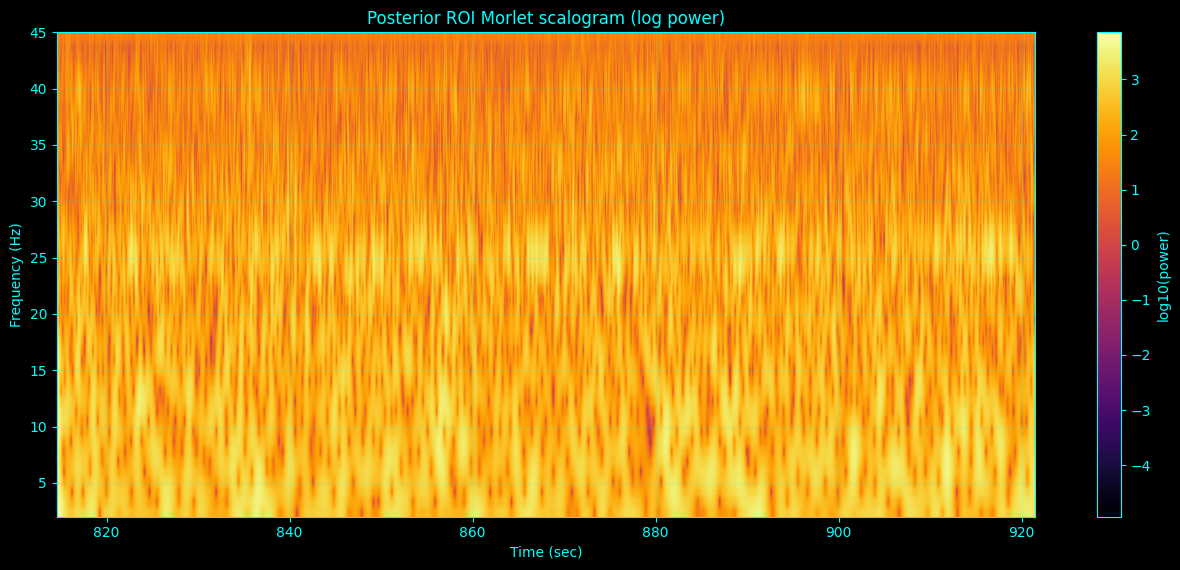

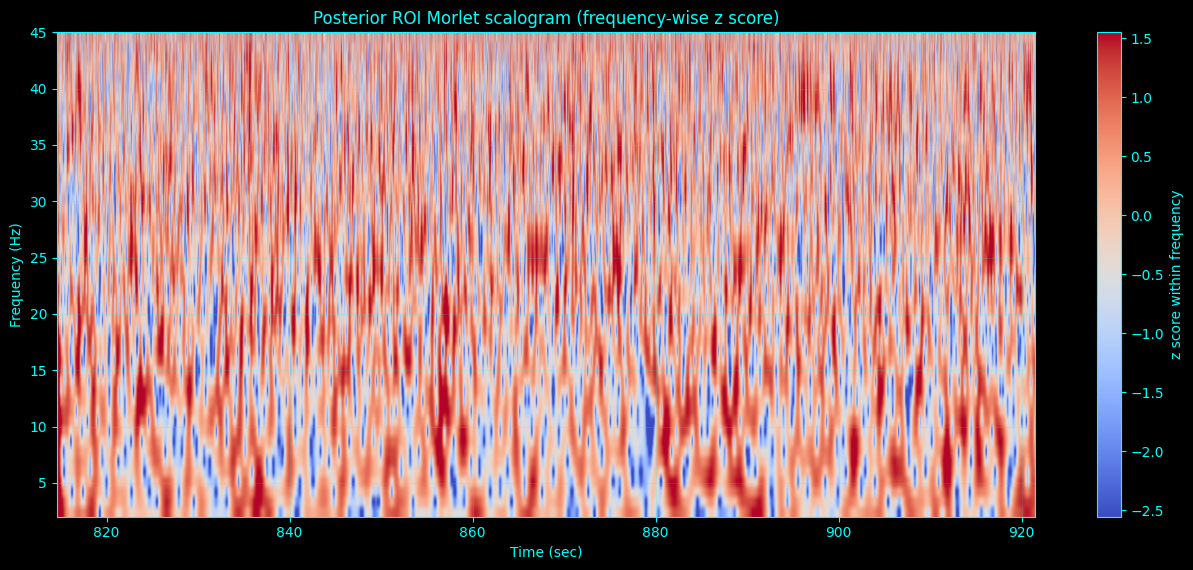

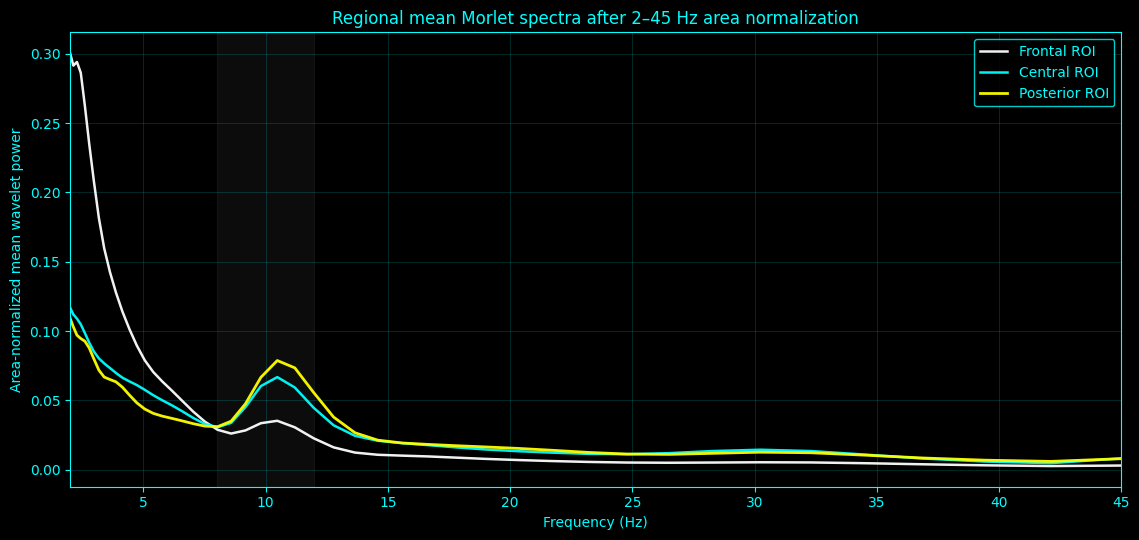

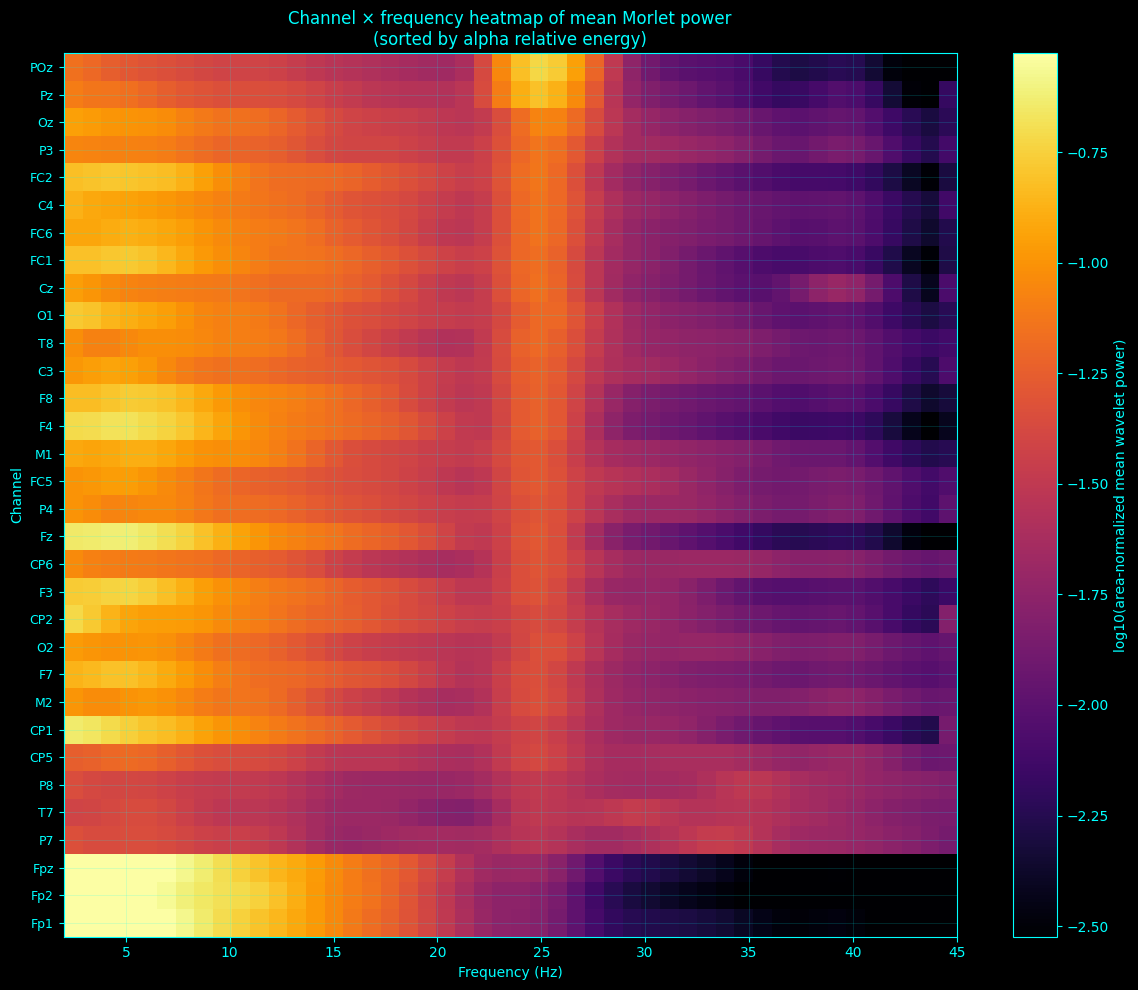

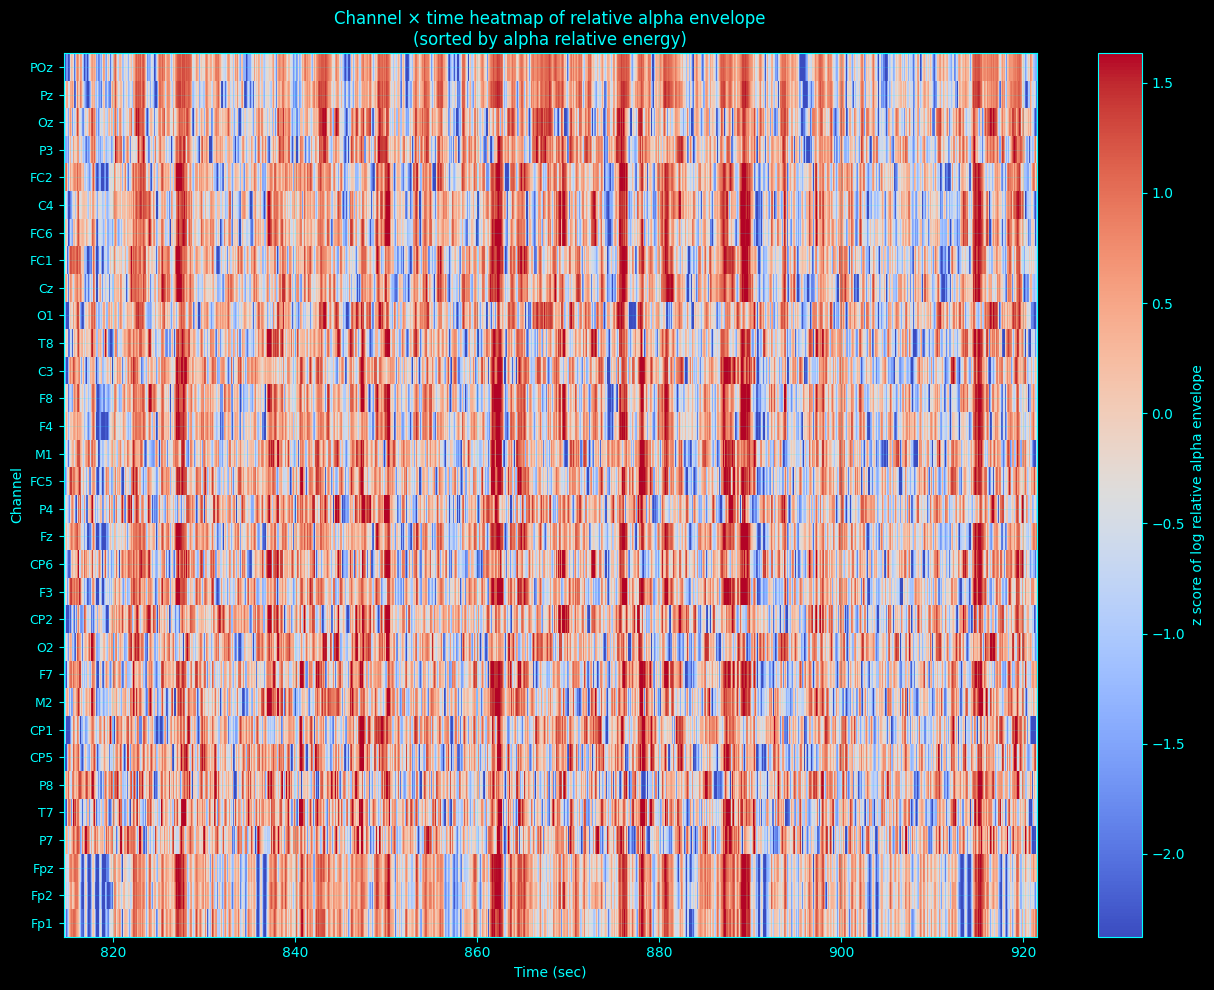

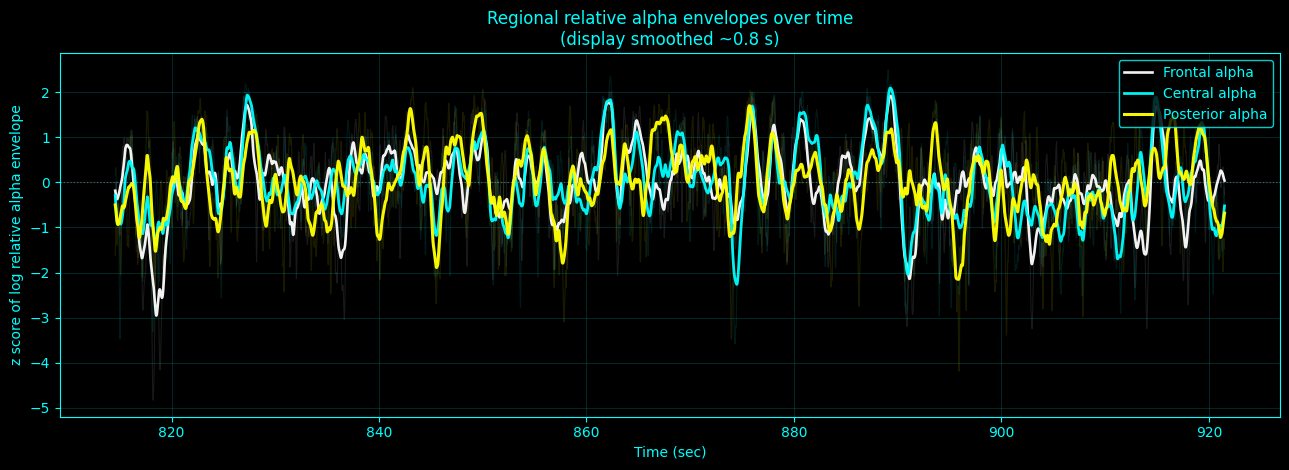

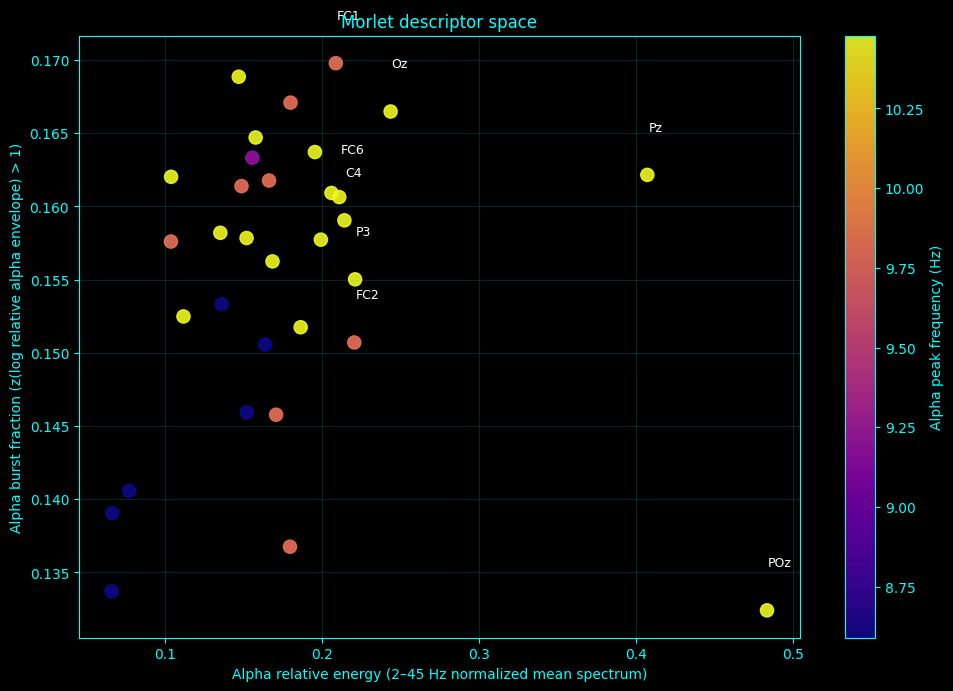


Saved NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_wavelet_cwt_scipy/exploratory_wavelet_cwt_scipy_outputs.npz
Saved summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_wavelet_cwt_scipy/wavelet_channel_summary_scipy.csv
Saved notes TXT: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_wavelet_cwt_scipy/exploratory_wavelet_notes_scipy.txt
Saved plots to: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_wavelet_cwt_scipy/plots
Done.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal

# -------------------------------------------------------
# NUMPY 1.x / 2.x COMPATIBILITY
# -------------------------------------------------------
if hasattr(np, "trapezoid"):
    integrate_trapezoid = np.trapezoid
else:
    integrate_trapezoid = np.trapz

# -------------------------------------------------------
# CONFIG — aligned to the upgraded scripts
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

out_dir = os.path.join(base_dir, "results", "exploratory_wavelet_cwt_scipy")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)

# Wavelet pass is for exploratory time-frequency structure, not stationary PSD scoring.
# We downsample ONLY for this pass because the question is sub-45 Hz structure.
wavelet_downsample_factor = 1
fs_wavelet = sampling_rate / wavelet_downsample_factor  # 1000 Hz

# Frequency design
fmin, fmax = 2.0, 45.0
n_wavelet_freqs = 48
target_freqs_hz = np.geomspace(fmin, fmax, n_wavelet_freqs)

# Morlet design
morlet_n_cycles = 7.0
morlet_support_sigma = 4.0  # wavelet support = +/- support_sigma * sigma_t

# Preprocessing
apply_common_average_reference = False
detrend_mode = "constant"
zscore_each_channel = False

# Descriptive bands
bands = {
    "delta": (2.0, 4.0),
    "theta": (4.0, 8.0),
    "alpha": (8.0, 12.0),
    "beta":  (13.0, 30.0),
    "low_gamma": (30.0, 45.0),
}
alpha_search_band = (7.0, 13.0)

# ROI definitions
roi_definitions = {
    "frontal":   ['Fp1', 'Fpz', 'Fp2', 'F3', 'Fz', 'F4'],
    "central":   ['C3', 'Cz', 'C4'],
    "posterior": ['P3', 'Pz', 'P4', 'O1', 'Oz', 'O2'],
}

eeg_channel_names = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

eps = 1e-12
ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
    "font.size": 10,
})

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    ax.grid(True, alpha=0.18, color=ACCENT, linewidth=0.6)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def ensure_time_channel_layout(x, n_channels_expected):
    x = np.asarray(x, dtype=float)
    if x.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {x.shape}")
    if x.shape[1] == n_channels_expected:
        return x
    if x.shape[0] == n_channels_expected:
        return x.T
    raise ValueError(f"Unexpected EEG shape {x.shape}; cannot identify channel axis.")

def maybe_common_average_reference(x, enabled=False):
    if not enabled:
        return x
    return x - np.mean(x, axis=1, keepdims=True)

def preprocess_channel(y, detrend_mode="constant", zscore=False):
    y = np.asarray(y, dtype=float)
    if detrend_mode is not None:
        y = signal.detrend(y, type=detrend_mode)
    if zscore:
        sd = np.std(y)
        y = (y - np.mean(y)) / (sd + eps)
    return y

def smooth_1d(x, win=9):
    x = np.asarray(x, dtype=float)
    if win <= 1 or len(x) < win:
        return x
    kernel = np.ones(win, dtype=float) / win
    return np.convolve(x, kernel, mode="same")

def smooth_time_series(x, win_samples=41):
    return smooth_1d(x, win=max(int(win_samples), 1))

def band_mask(freqs_hz, lo, hi):
    return (freqs_hz >= lo) & (freqs_hz <= hi)

def area_normalize_1d(freqs_hz, x, lo=2.0, hi=45.0):
    x = np.asarray(x, dtype=float)
    out = np.full_like(x, np.nan, dtype=float)
    mask = band_mask(freqs_hz, lo, hi) & np.isfinite(x) & (x >= 0)
    if np.sum(mask) < 2:
        return out
    area = integrate_trapezoid(x[mask], freqs_hz[mask])
    if not np.isfinite(area) or area <= 0:
        return out
    out[mask] = x[mask] / area
    return out

def integrate_band_1d(freqs_hz, x, band):
    lo, hi = band
    mask = band_mask(freqs_hz, lo, hi) & np.isfinite(x)
    if np.sum(mask) < 2:
        return np.nan
    return float(integrate_trapezoid(x[mask], freqs_hz[mask]))

def band_envelope(freqs_hz, power_matrix, band):
    lo, hi = band
    mask = band_mask(freqs_hz, lo, hi)
    if np.sum(mask) < 2:
        return np.full(power_matrix.shape[1], np.nan, dtype=float)
    return integrate_trapezoid(power_matrix[mask, :], freqs_hz[mask], axis=0)

def robust_peak_in_band(freqs_hz, spectrum_1d, band=(7.0, 13.0), smooth_win=7):
    mask = band_mask(freqs_hz, band[0], band[1]) & np.isfinite(spectrum_1d)
    if np.sum(mask) < 5:
        return np.nan, np.nan, np.nan, np.nan

    f = freqs_hz[mask]
    y = smooth_1d(spectrum_1d[mask], win=smooth_win)

    peaks, _ = signal.find_peaks(y)
    if len(peaks) == 0:
        return np.nan, np.nan, np.nan, np.nan

    prominences = signal.peak_prominences(y, peaks)[0]
    valid = (peaks > 0) & (peaks < len(y) - 1)
    if not np.any(valid):
        return np.nan, np.nan, np.nan, np.nan

    peaks = peaks[valid]
    prominences = prominences[valid]

    min_prominence = max(0.05 * np.nanmax(y), 1.5 * np.nanmedian(np.abs(np.diff(y))))
    strong = prominences >= min_prominence
    if not np.any(strong):
        return np.nan, np.nan, np.nan, np.nan

    peaks = peaks[strong]
    prominences = prominences[strong]
    winner = int(np.argmax(prominences))
    peak_idx = peaks[winner]

    peak_freq = float(f[peak_idx])
    peak_height = float(y[peak_idx])
    peak_prominence = float(prominences[winner])
    peak_contrast = float(peak_height / (np.nanmedian(y) + eps))
    return peak_freq, peak_height, peak_prominence, peak_contrast

def spectral_entropy(freqs_hz, spectrum_1d, lo=2.0, hi=45.0):
    mask = band_mask(freqs_hz, lo, hi) & np.isfinite(spectrum_1d)
    p = np.asarray(spectrum_1d[mask], dtype=float)
    p = np.maximum(p, 0.0)
    s = np.sum(p)
    if s <= 0:
        return np.nan
    p = p / s
    h = -np.sum(p * np.log(p + eps))
    hmax = np.log(len(p) + eps)
    return float(h / (hmax + eps))

def zscore_1d(x):
    x = np.asarray(x, dtype=float)
    mu = np.nanmean(x)
    sd = np.nanstd(x)
    return (x - mu) / (sd + eps)

def percentile_limits(x, lo=2, hi=98):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return None, None
    return float(np.percentile(x, lo)), float(np.percentile(x, hi))

def roi_signal(x, channel_names, roi_channels):
    idx = [channel_names.index(ch) for ch in roi_channels if ch in channel_names]
    if len(idx) == 0:
        raise ValueError(f"No ROI channels found for {roi_channels}")
    return np.mean(x[:, idx], axis=1)

def roi_average_spectrum(matrix, channel_names, roi_channels):
    idx = [channel_names.index(ch) for ch in roi_channels if ch in channel_names]
    if len(idx) == 0:
        return np.full(matrix.shape[0], np.nan)
    return np.nanmean(matrix[:, idx], axis=1)

def roi_average_envelope(matrix, channel_names, roi_channels):
    idx = [channel_names.index(ch) for ch in roi_channels if ch in channel_names]
    if len(idx) == 0:
        return np.full(matrix.shape[0], np.nan)
    return np.nanmean(matrix[:, idx], axis=1)

def morlet_wavelet(f_hz, fs, n_cycles=7.0, support_sigma=4.0):
    """
    Complex Morlet wavelet with unit energy normalization.
    """
    sigma_t = n_cycles / (2.0 * np.pi * f_hz)
    half_width_sec = support_sigma * sigma_t
    t = np.arange(-half_width_sec, half_width_sec + 1.0 / fs, 1.0 / fs)

    wavelet = np.exp(2j * np.pi * f_hz * t) * np.exp(-(t ** 2) / (2.0 * sigma_t ** 2))
    wavelet = wavelet / np.sqrt(np.sum(np.abs(wavelet) ** 2) + eps)
    return wavelet

def compute_morlet_cwt_power(y, fs, target_freqs_hz, n_cycles=7.0, support_sigma=4.0):
    """
    SciPy-only CWT-like implementation using FFT convolution with complex Morlet kernels.
    Returns:
        freqs_hz: shape (n_freqs,)
        power:    shape (n_freqs, n_times)
    """
    y = np.asarray(y, dtype=float)
    power_rows = []

    for f_hz in target_freqs_hz:
        w = morlet_wavelet(f_hz, fs, n_cycles=n_cycles, support_sigma=support_sigma)
        coeff = signal.fftconvolve(y, np.conjugate(w[::-1]), mode="same")
        power = np.abs(coeff) ** 2
        power_rows.append(power)

    power_matrix = np.vstack(power_rows)
    return np.asarray(target_freqs_hz, dtype=float), power_matrix

# -------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------
eeg_data = np.load(eeg_path, allow_pickle=True)
eeg_data = ensure_time_channel_layout(eeg_data, len(eeg_channel_names))

if end_index > eeg_data.shape[0]:
    raise ValueError(
        f"Requested end index {end_index} exceeds data length {eeg_data.shape[0]}. "
        "Check sampling rate or segment bounds."
    )

segment = eeg_data[start_index:end_index, :].copy()
segment = maybe_common_average_reference(segment, enabled=apply_common_average_reference)

# Downsample only for the wavelet pass
segment_ds = signal.resample_poly(segment, up=1, down=wavelet_downsample_factor, axis=0)
segment_ds = np.asarray(segment_ds, dtype=float)

time_ds_rel = np.arange(segment_ds.shape[0], dtype=float) / fs_wavelet
time_ds_abs = start_time + time_ds_rel

print(f"Loaded EEG data: {eeg_data.shape[0]} samples x {eeg_data.shape[1]} channels")
print(f"Segment of interest: {start_time:.3f} to {end_time:.3f} sec")
print(f"Original segment shape: {segment.shape}")
print(f"Downsampled wavelet segment shape: {segment_ds.shape}")
print(f"Wavelet comparison sampling rate: {fs_wavelet:.1f} Hz")

# -------------------------------------------------------
# ROI CWTs — true time-frequency views
# -------------------------------------------------------
posterior_signal = preprocess_channel(
    roi_signal(segment_ds, eeg_channel_names, roi_definitions["posterior"]),
    detrend_mode=detrend_mode,
    zscore=zscore_each_channel,
)
frontal_signal = preprocess_channel(
    roi_signal(segment_ds, eeg_channel_names, roi_definitions["frontal"]),
    detrend_mode=detrend_mode,
    zscore=zscore_each_channel,
)
central_signal = preprocess_channel(
    roi_signal(segment_ds, eeg_channel_names, roi_definitions["central"]),
    detrend_mode=detrend_mode,
    zscore=zscore_each_channel,
)

freqs_hz, posterior_power = compute_morlet_cwt_power(
    posterior_signal,
    fs_wavelet,
    target_freqs_hz,
    n_cycles=morlet_n_cycles,
    support_sigma=morlet_support_sigma,
)
_, frontal_power = compute_morlet_cwt_power(
    frontal_signal,
    fs_wavelet,
    target_freqs_hz,
    n_cycles=morlet_n_cycles,
    support_sigma=morlet_support_sigma,
)
_, central_power = compute_morlet_cwt_power(
    central_signal,
    fs_wavelet,
    target_freqs_hz,
    n_cycles=morlet_n_cycles,
    support_sigma=morlet_support_sigma,
)

posterior_log_power = np.log10(posterior_power + eps)
posterior_zfreq = (posterior_log_power - np.nanmean(posterior_log_power, axis=1, keepdims=True)) / (
    np.nanstd(posterior_log_power, axis=1, keepdims=True) + eps
)

# -------------------------------------------------------
# CHANNEL-WISE CWT SUMMARIES
# -------------------------------------------------------
n_freqs = len(freqs_hz)
n_times = len(time_ds_abs)
n_channels = len(eeg_channel_names)

mean_spectrum_matrix = np.full((n_freqs, n_channels), np.nan, dtype=float)
mean_spectrum_area_norm = np.full((n_freqs, n_channels), np.nan, dtype=float)

alpha_rel_env_matrix = np.full((n_times, n_channels), np.nan, dtype=float)
alpha_rel_env_z_matrix = np.full((n_times, n_channels), np.nan, dtype=float)

summary_rows = []

for ch_i, ch_name in enumerate(eeg_channel_names):
    y = preprocess_channel(
        segment_ds[:, ch_i],
        detrend_mode=detrend_mode,
        zscore=zscore_each_channel,
    )

    freqs_ch, power = compute_morlet_cwt_power(
        y,
        fs_wavelet,
        target_freqs_hz,
        n_cycles=morlet_n_cycles,
        support_sigma=morlet_support_sigma,
    )

    mean_spectrum = np.nanmean(power, axis=1)
    mean_spectrum_norm = area_normalize_1d(freqs_ch, mean_spectrum, lo=fmin, hi=fmax)

    total_env = band_envelope(freqs_ch, power, (fmin, fmax))
    alpha_env = band_envelope(freqs_ch, power, bands["alpha"])
    alpha_rel_env = alpha_env / (total_env + eps)
    alpha_rel_env_logz = zscore_1d(np.log10(alpha_rel_env + eps))

    alpha_peak_hz, alpha_peak_height, alpha_peak_prominence, alpha_peak_contrast = robust_peak_in_band(
        freqs_ch, mean_spectrum_norm, band=alpha_search_band, smooth_win=7
    )

    row = {
        "channel": ch_name,
        "alpha_peak_frequency_Hz": alpha_peak_hz,
        "alpha_peak_height_area_norm": alpha_peak_height,
        "alpha_peak_prominence": alpha_peak_prominence,
        "alpha_peak_contrast": alpha_peak_contrast,
        "spectral_entropy_2_45Hz": spectral_entropy(freqs_ch, mean_spectrum_norm, lo=fmin, hi=fmax),
        "alpha_relative_energy_2_45Hz": integrate_band_1d(freqs_ch, mean_spectrum_norm, bands["alpha"]),
        "theta_relative_energy_2_45Hz": integrate_band_1d(freqs_ch, mean_spectrum_norm, bands["theta"]),
        "beta_relative_energy_2_45Hz": integrate_band_1d(freqs_ch, mean_spectrum_norm, bands["beta"]),
        "low_gamma_relative_energy_2_45Hz": integrate_band_1d(freqs_ch, mean_spectrum_norm, bands["low_gamma"]),
        "alpha_rel_env_mean": float(np.nanmean(alpha_rel_env)),
        "alpha_rel_env_std": float(np.nanstd(alpha_rel_env)),
        "alpha_rel_env_cv": float(np.nanstd(alpha_rel_env) / (np.nanmean(alpha_rel_env) + eps)),
        "alpha_burst_fraction_z_gt_1": float(np.nanmean(alpha_rel_env_logz > 1.0)),
        "has_clear_alpha_peak": bool(np.isfinite(alpha_peak_hz)),
    }

    summary_rows.append(row)
    mean_spectrum_matrix[:, ch_i] = mean_spectrum
    mean_spectrum_area_norm[:, ch_i] = mean_spectrum_norm
    alpha_rel_env_matrix[:, ch_i] = alpha_rel_env
    alpha_rel_env_z_matrix[:, ch_i] = alpha_rel_env_logz

summary_df = pd.DataFrame(summary_rows)
for col in summary_df.columns:
    if col != "channel":
        summary_df[col] = pd.to_numeric(summary_df[col], errors="coerce")

# -------------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------------
npz_path = os.path.join(out_dir, "exploratory_wavelet_cwt_scipy_outputs.npz")
summary_csv_path = os.path.join(out_dir, "wavelet_channel_summary_scipy.csv")
notes_txt_path = os.path.join(out_dir, "exploratory_wavelet_notes_scipy.txt")

np.savez_compressed(
    npz_path,
    frequencies_hz=freqs_hz,
    time_sec_abs=time_ds_abs,
    time_sec_rel=time_ds_rel,
    mean_spectrum_matrix=mean_spectrum_matrix,
    mean_spectrum_area_norm_2_45Hz=mean_spectrum_area_norm,
    alpha_rel_env_matrix=alpha_rel_env_matrix,
    alpha_rel_env_z_matrix=alpha_rel_env_z_matrix,
    posterior_power=posterior_power,
    posterior_log_power=posterior_log_power,
    posterior_zfreq=posterior_zfreq,
    frontal_power=frontal_power,
    central_power=central_power,
    channel_names=np.array(eeg_channel_names, dtype=object),
    start_time=start_time,
    end_time=end_time,
    original_sampling_rate=sampling_rate,
    wavelet_sampling_rate=fs_wavelet,
    wavelet_downsample_factor=wavelet_downsample_factor,
    morlet_n_cycles=morlet_n_cycles,
    morlet_support_sigma=morlet_support_sigma,
)

summary_df.to_csv(summary_csv_path, index=False)

top_alpha = summary_df.sort_values("alpha_relative_energy_2_45Hz", ascending=False).head(8)
top_bursty = summary_df.sort_values("alpha_burst_fraction_z_gt_1", ascending=False).head(8)
no_peak = summary_df.loc[~summary_df["has_clear_alpha_peak"], "channel"].tolist()

with open(notes_txt_path, "w") as f:
    f.write("Exploratory wavelet CWT notes (SciPy-only Morlet version)\n")
    f.write("=========================================================\n\n")
    f.write("Intent:\n")
    f.write("This pass is for time-frequency exploration inside the selected segment, not for formal scoring,\n")
    f.write("not for publication claims, and not as a replacement for Welch-style stationary summaries.\n\n")
    f.write("What changed relative to the original block:\n")
    f.write("1. No PyWavelets dependency; this version uses FFT-convolved complex Morlet kernels.\n")
    f.write("2. Wavelet output is treated as a time-frequency exploratory view, not as stationary PSD truth.\n")
    f.write("3. Channel summaries are based on time-averaged wavelet power and time-varying relative alpha envelopes.\n")
    f.write("4. ROI scalograms are used to inspect nonstationarity; channel heatmaps summarize cross-channel structure.\n\n")
    f.write(f"Segment: [{start_time:.3f}, {end_time:.3f}] sec\n")
    f.write(f"Original fs: {sampling_rate} Hz\n")
    f.write(f"Wavelet fs: {fs_wavelet:.1f} Hz\n")
    f.write(f"Downsample factor for wavelet pass: {wavelet_downsample_factor}\n")
    f.write(f"Morlet n_cycles: {morlet_n_cycles}\n")
    f.write(f"Frequency range analyzed: [{fmin:.1f}, {fmax:.1f}] Hz\n")
    f.write(f"Number of wavelet frequencies: {n_wavelet_freqs}\n\n")

    f.write("Top alpha-relative-energy channels:\n")
    for _, row in top_alpha.iterrows():
        f.write(
            f"  {row['channel']}: "
            f"alpha_rel={row['alpha_relative_energy_2_45Hz']:.4f}, "
            f"alpha_peak={row['alpha_peak_frequency_Hz']}, "
            f"alpha_contrast={row['alpha_peak_contrast']:.3f}, "
            f"alpha_burst_fraction={row['alpha_burst_fraction_z_gt_1']:.3f}\n"
        )

    f.write("\nTop alpha-bursty channels:\n")
    for _, row in top_bursty.iterrows():
        f.write(
            f"  {row['channel']}: "
            f"burst_fraction={row['alpha_burst_fraction_z_gt_1']:.3f}, "
            f"alpha_rel={row['alpha_relative_energy_2_45Hz']:.4f}, "
            f"alpha_peak={row['alpha_peak_frequency_Hz']}\n"
        )

    f.write("\nChannels with no clear alpha peak in the time-averaged wavelet spectrum:\n")
    f.write("  " + (", ".join(no_peak) if len(no_peak) else "none") + "\n")

# -------------------------------------------------------
# PLOTS
# -------------------------------------------------------

# 1) Posterior ROI raw log-power scalogram
fig, ax = plt.subplots(figsize=(13, 5.8), facecolor=BG)
style_ax(ax)
mesh = ax.imshow(
    posterior_log_power,
    extent=[time_ds_abs[0], time_ds_abs[-1], freqs_hz[0], freqs_hz[-1]],
    aspect="auto",
    origin="lower",
    cmap="inferno",
)
ax.set_title("Posterior ROI Morlet scalogram (log power)")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("Frequency (Hz)")
ax.set_ylim(fmin, fmax)
cbar = plt.colorbar(mesh, ax=ax)
cbar.set_label("log10(power)", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "01_posterior_roi_scalogram_logpower.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 2) Posterior ROI frequency-wise z-scored scalogram
fig, ax = plt.subplots(figsize=(13, 5.8), facecolor=BG)
style_ax(ax)
vmin, vmax = percentile_limits(posterior_zfreq, lo=2, hi=98)
mesh = ax.imshow(
    posterior_zfreq,
    extent=[time_ds_abs[0], time_ds_abs[-1], freqs_hz[0], freqs_hz[-1]],
    aspect="auto",
    origin="lower",
    cmap="coolwarm",
    vmin=vmin,
    vmax=vmax,
)
ax.set_title("Posterior ROI Morlet scalogram (frequency-wise z score)")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("Frequency (Hz)")
ax.set_ylim(fmin, fmax)
cbar = plt.colorbar(mesh, ax=ax)
cbar.set_label("z score within frequency", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "02_posterior_roi_scalogram_zfreq.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 3) Regional mean wavelet spectra
frontal_spec = roi_average_spectrum(mean_spectrum_area_norm, eeg_channel_names, roi_definitions["frontal"])
central_spec = roi_average_spectrum(mean_spectrum_area_norm, eeg_channel_names, roi_definitions["central"])
posterior_spec = roi_average_spectrum(mean_spectrum_area_norm, eeg_channel_names, roi_definitions["posterior"])

fig, ax = plt.subplots(figsize=(11.5, 5.5), facecolor=BG)
style_ax(ax)
ax.plot(freqs_hz, frontal_spec, color="white", linewidth=1.8, alpha=0.95, label="Frontal ROI")
ax.plot(freqs_hz, central_spec, color=ACCENT, linewidth=1.8, alpha=0.95, label="Central ROI")
ax.plot(freqs_hz, posterior_spec, color="yellow", linewidth=2.0, alpha=0.95, label="Posterior ROI")
ax.axvspan(bands["alpha"][0], bands["alpha"][1], color="white", alpha=0.05)
ax.set_xlim(fmin, fmax)
ax.set_title("Regional mean Morlet spectra after 2–45 Hz area normalization")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Area-normalized mean wavelet power")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "03_regional_mean_wavelet_spectra.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 4) Channel x frequency heatmap of mean wavelet spectrum
sort_df = summary_df.sort_values(
    by=["alpha_relative_energy_2_45Hz", "alpha_peak_frequency_Hz"],
    ascending=[False, True],
    na_position="last",
).reset_index(drop=True)
sorted_channels = list(sort_df["channel"].values)
sorted_idx = [eeg_channel_names.index(ch) for ch in sorted_channels]

heat = np.log10(mean_spectrum_area_norm[:, sorted_idx].T + 1e-6)
vmin, vmax = percentile_limits(heat, lo=2, hi=99)

fig, ax = plt.subplots(figsize=(12, 10), facecolor=BG)
style_ax(ax)
im = ax.imshow(
    heat,
    aspect="auto",
    interpolation="nearest",
    cmap="inferno",
    vmin=vmin,
    vmax=vmax,
    extent=[freqs_hz[0], freqs_hz[-1], len(sorted_channels), 0],
)
ax.set_title("Channel × frequency heatmap of mean Morlet power\n(sorted by alpha relative energy)")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Channel")
ax.set_yticks(np.arange(len(sorted_channels)) + 0.5)
ax.set_yticklabels(sorted_channels, fontsize=9)
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("log10(area-normalized mean wavelet power)", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "04_channel_frequency_heatmap_wavelet.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 5) Channel x time heatmap of alpha relative-envelope z score
alpha_heat = alpha_rel_env_z_matrix[:, sorted_idx].T
vmin, vmax = percentile_limits(alpha_heat, lo=2, hi=98)

fig, ax = plt.subplots(figsize=(13, 10), facecolor=BG)
style_ax(ax)
im = ax.imshow(
    alpha_heat,
    aspect="auto",
    interpolation="nearest",
    cmap="coolwarm",
    vmin=vmin,
    vmax=vmax,
    extent=[time_ds_abs[0], time_ds_abs[-1], len(sorted_channels), 0],
)
ax.set_title("Channel × time heatmap of relative alpha envelope\n(sorted by alpha relative energy)")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("Channel")
ax.set_yticks(np.arange(len(sorted_channels)) + 0.5)
ax.set_yticklabels(sorted_channels, fontsize=9)
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("z score of log relative alpha envelope", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "05_channel_time_alpha_envelope_heatmap.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 6) Frontal vs central vs posterior alpha envelopes over time
#    same underlying metric, cleaner display smoothing

frontal_alpha_env = roi_average_envelope(alpha_rel_env_matrix, eeg_channel_names, roi_definitions["frontal"])
central_alpha_env = roi_average_envelope(alpha_rel_env_matrix, eeg_channel_names, roi_definitions["central"])
posterior_alpha_env = roi_average_envelope(alpha_rel_env_matrix, eeg_channel_names, roi_definitions["posterior"])

frontal_alpha_env_z = zscore_1d(np.log10(frontal_alpha_env + eps))
central_alpha_env_z = zscore_1d(np.log10(central_alpha_env + eps))
posterior_alpha_env_z = zscore_1d(np.log10(posterior_alpha_env + eps))

# More display-friendly smoothing than the original win_samples=41
# fs_wavelet = 200 Hz, so 0.8 s ~= 161 samples
display_smooth_sec = 0.8
display_win = max(5, int(round(display_smooth_sec * fs_wavelet)))
if display_win % 2 == 0:
    display_win += 1

frontal_alpha_env_z_s = smooth_time_series(frontal_alpha_env_z, win_samples=display_win)
central_alpha_env_z_s = smooth_time_series(central_alpha_env_z, win_samples=display_win)
posterior_alpha_env_z_s = smooth_time_series(posterior_alpha_env_z, win_samples=display_win)

fig, ax = plt.subplots(figsize=(13, 4.8), facecolor=BG)
style_ax(ax)

# faint raw traces for context
ax.plot(time_ds_abs, frontal_alpha_env_z, color="white", linewidth=0.8, alpha=0.10)
ax.plot(time_ds_abs, central_alpha_env_z, color=ACCENT, linewidth=0.8, alpha=0.10)
ax.plot(time_ds_abs, posterior_alpha_env_z, color="yellow", linewidth=0.9, alpha=0.10)

# smoothed display curves
ax.plot(
    time_ds_abs,
    frontal_alpha_env_z_s,
    color="white",
    linewidth=1.9,
    alpha=0.95,
    label="Frontal alpha"
)
ax.plot(
    time_ds_abs,
    central_alpha_env_z_s,
    color=ACCENT,
    linewidth=2.0,
    alpha=0.95,
    label="Central alpha"
)
ax.plot(
    time_ds_abs,
    posterior_alpha_env_z_s,
    color="yellow",
    linewidth=2.2,
    alpha=0.97,
    label="Posterior alpha"
)

ax.axhline(0.0, color="white", linestyle=":", linewidth=0.9, alpha=0.28)

ax.set_title(
    f"Regional relative alpha envelopes over time\n"
    f"(display smoothed ~{display_smooth_sec:.1f} s)"
)
ax.set_xlabel("Time (sec)")
ax.set_ylabel("z score of log relative alpha envelope")
ax.legend(loc="upper right")

plt.tight_layout()
plt.savefig(
    os.path.join(plots_dir, "06_regional_alpha_envelopes_over_time.png"),
    dpi=180,
    bbox_inches="tight"
)
plt.show()
plt.close()
# 7) Descriptor space: alpha energy vs alpha burstiness
fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
style_ax(ax)

scatter = ax.scatter(
    summary_df["alpha_relative_energy_2_45Hz"].values,
    summary_df["alpha_burst_fraction_z_gt_1"].values,
    c=summary_df["alpha_peak_frequency_Hz"].values,
    s=90,
    alpha=0.9,
    cmap="plasma",
)

annotate_df = summary_df.sort_values("alpha_relative_energy_2_45Hz", ascending=False).head(8)
for _, row in annotate_df.iterrows():
    ax.text(
        row["alpha_relative_energy_2_45Hz"] + 0.0007,
        row["alpha_burst_fraction_z_gt_1"] + 0.003,
        row["channel"],
        color="white",
        fontsize=9,
    )

ax.set_title("Morlet descriptor space")
ax.set_xlabel("Alpha relative energy (2–45 Hz normalized mean spectrum)")
ax.set_ylabel("Alpha burst fraction (z(log relative alpha envelope) > 1)")

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Alpha peak frequency (Hz)", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "07_wavelet_descriptor_space.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

print(f"\nSaved NPZ: {npz_path}")
print(f"Saved summary CSV: {summary_csv_path}")
print(f"Saved notes TXT: {notes_txt_path}")
print(f"Saved plots to: {plots_dir}")
print("Done.")

# Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) 

<div style="font-size: 13px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; flex-wrap: nowrap; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="flex: 1; margin-right: 10px;">
        <h2>Introduction</h2>
        <p>We present an advanced analytical framework for evaluating the AutoCorrelation Function (ACF) and Partial AutoCorrelation Function (PACF) in EEG data. These statistical measures reveal critical aspects about signal periodicity and are essential for various time-series analyses.</p>
        <h2>Objectives</h2>
        <ul>
            <li>Channel-wise EEG Data Extraction</li>
            <li>ACF and PACF Calculation</li>
            <li>Data Serialization</li>
        </ul>
        <h2>Mathematical Background</h2>
        <h3>AutoCorrelation Function (ACF)</h3>
        \[ \text{ACF}(\tau) = \frac{\sum_{t=1}^{T-\tau} (x_t - \bar{x})(x_{t+\tau} - \bar{x})}{\sum_{t=1}^T (x_t - \bar{x})^2} \]
        <p>Where \( \tau \) is the time lag, \( x_t \) is the data point at time \( t \), and \( \bar{x} \) is the mean of the dataset.</p>
        <h3>Partial AutoCorrelation Function (PACF)</h3>
        <p>It isolates the correlation between a variable and a lagged version of itself that is not explained by correlations at all lower-order lags. Mathematically, PACF can be derived from the autoregressive model of the data.</p>
    </div>
    <!-- Column 2 -->
    <div style="flex: 1; margin-left: 10px;">
        <h2>Computational Procedures</h2>
        <ul>
            <li>EEG data corresponding to each channel is isolated.</li>
            <li>ACF and PACF are calculated for up to 10 lags.</li>
        </ul>
        <h2>Data Storage</h2>
        <p>The calculated ACF and PACF values are stored in a dictionary, which is then serialized into a single NumPy file. This ensures efficient storage and easy access for future investigations.</p>
        <h2>Implications</h2>
        <p>Understanding ACF and PACF provides insights into the underlying periodic behaviors in EEG signals, which is crucial for detecting anomalies, understanding brain functions, and various other applications in neuroscience. These functions often serve as the stepping stone for more complex time-series analyses including ARIMA models.</p>
        <h2>Conclusion</h2>
        <p>This comprehensive framework paves the way for a robust time-series analysis of EEG data, offering a deeper understanding of neurophysiological phenomena.</p>
    </div>
</div>

Loaded EEG data: 4227788 samples x 32 channels
Segment of interest: 814.571 to 921.515 sec
Original segment shape: (106944, 32)
Downsampled autocorrelation segment shape: (26736, 32)
Autocorrelation comparison sampling rate: 250.0 Hz
Max lag: 400.0 ms (100 samples at 250.0 Hz)


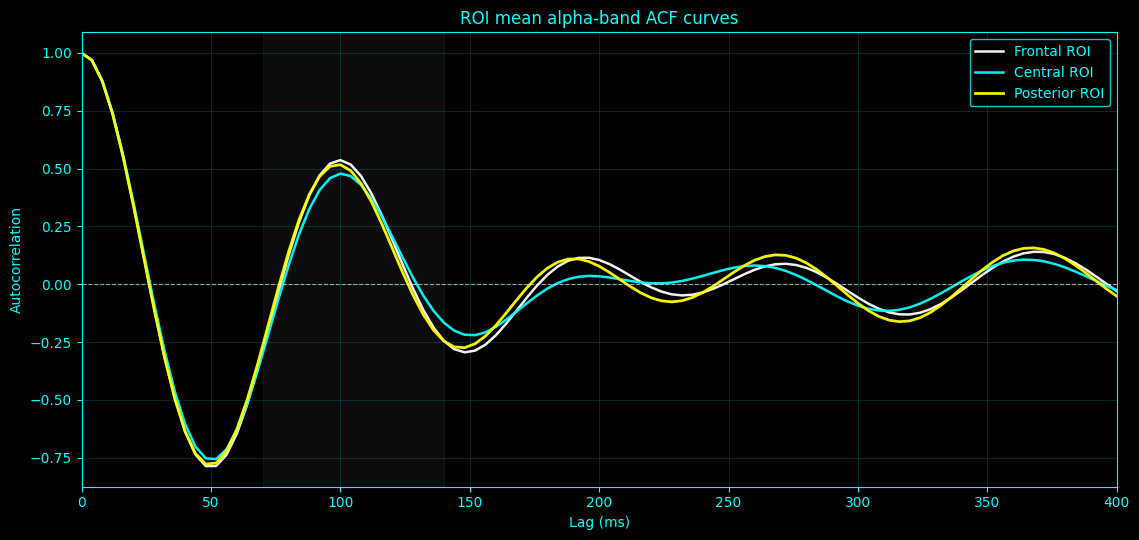

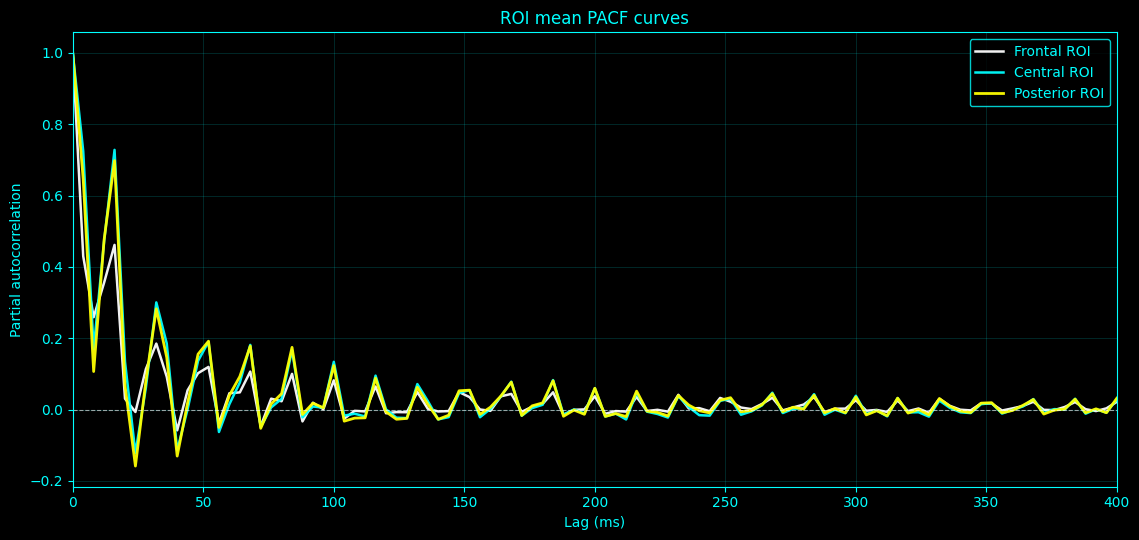

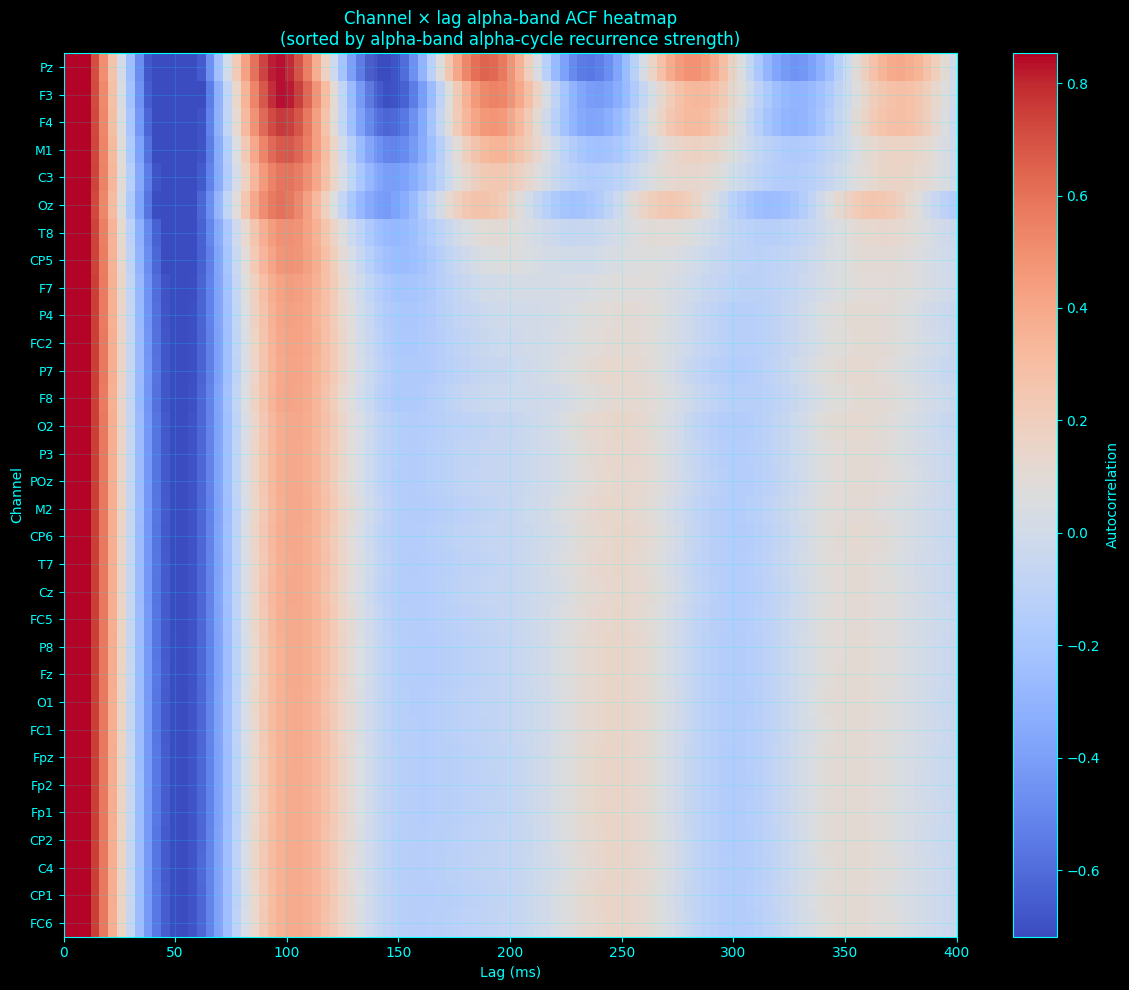

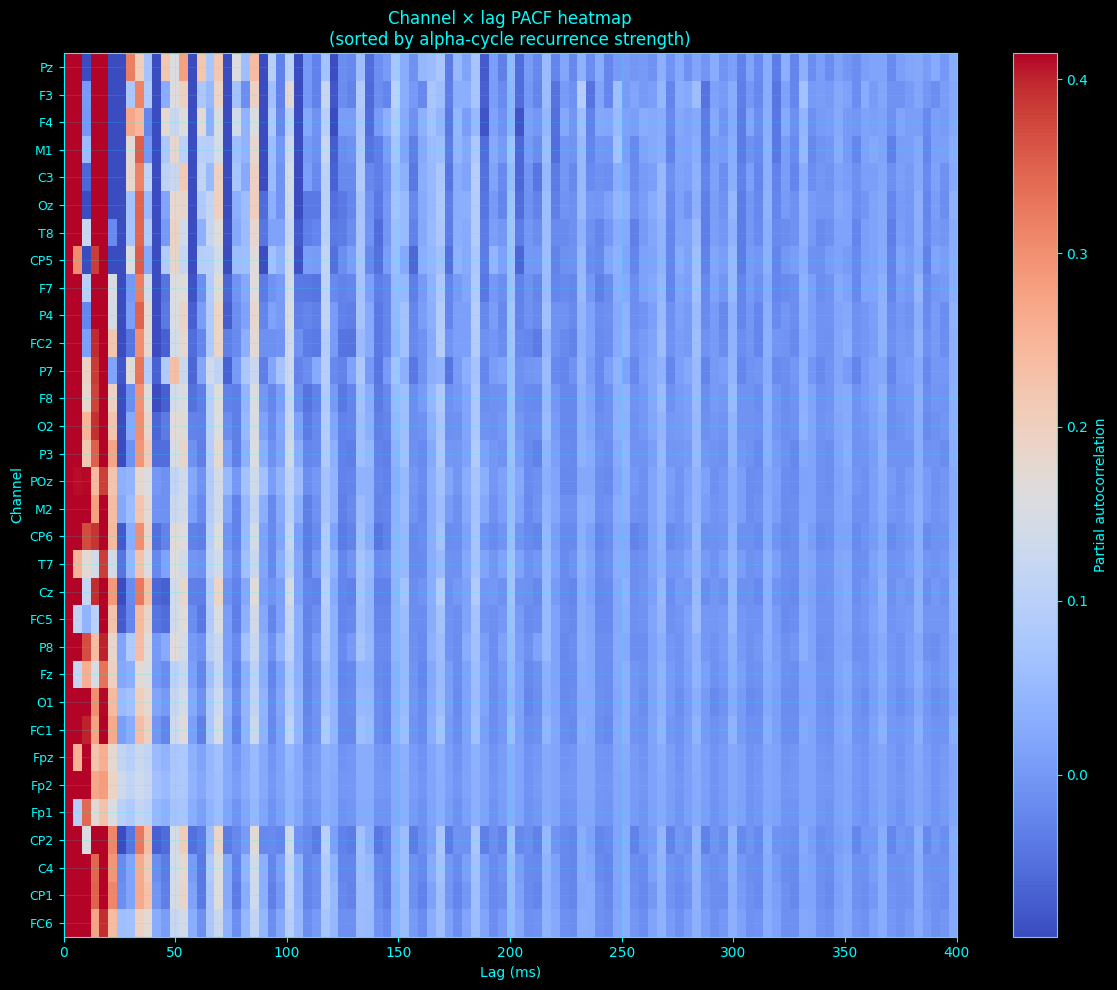

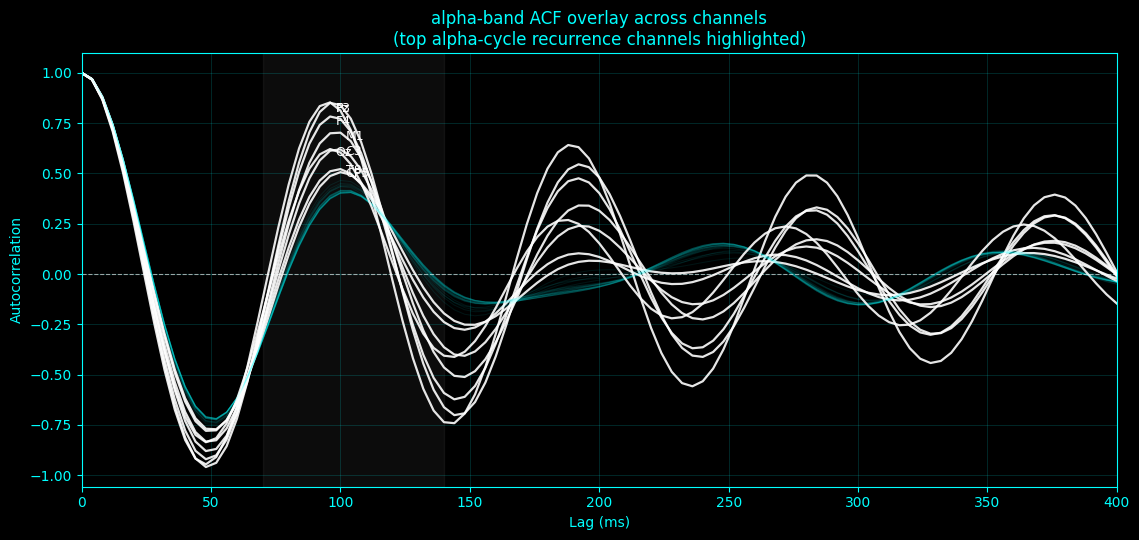

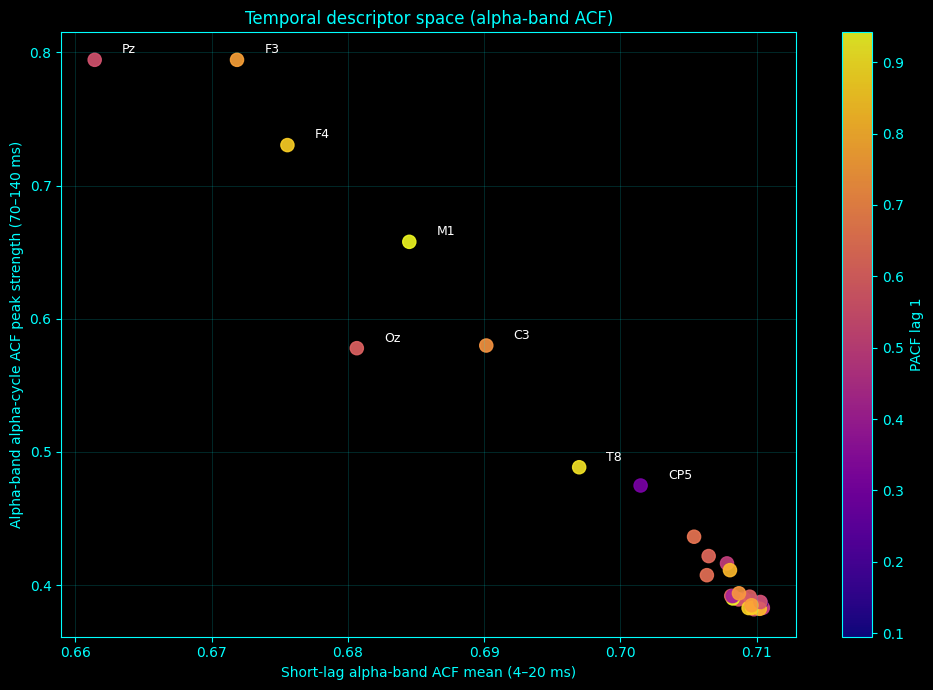

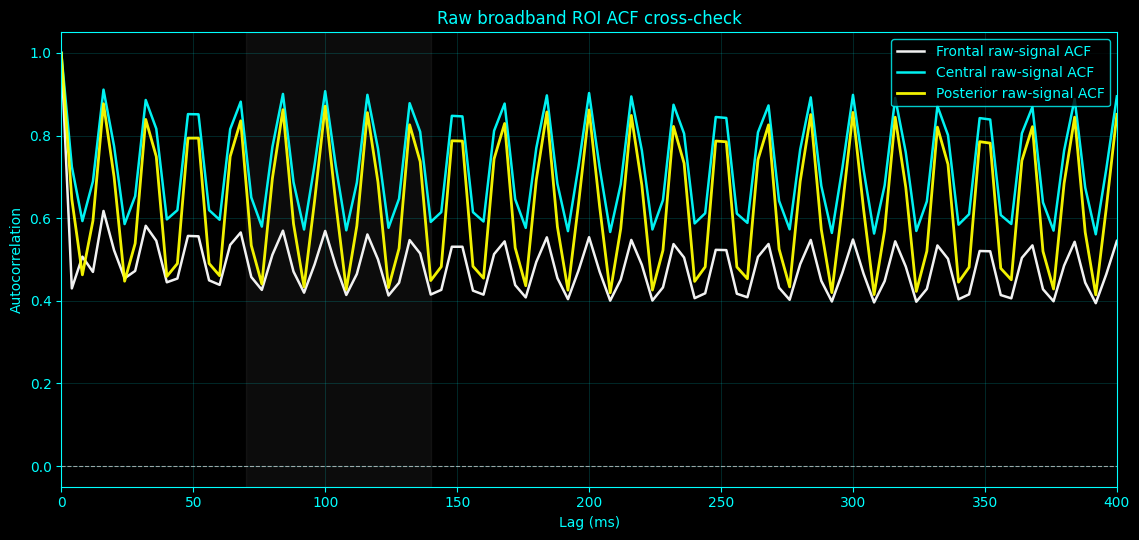


Saved NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_acf_pacf/exploratory_acf_pacf_outputs.npz
Saved summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_acf_pacf/acf_pacf_channel_summary.csv
Saved notes TXT: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_acf_pacf/exploratory_acf_pacf_notes.txt
Saved plots to: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_acf_pacf/plots
Done.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.linalg import toeplitz

# -------------------------------------------------------
# NUMPY 1.x / 2.x COMPATIBILITY
# -------------------------------------------------------
if hasattr(np, "trapezoid"):
    integrate_trapezoid = np.trapezoid
else:
    integrate_trapezoid = np.trapz

# -------------------------------------------------------
# CONFIG — aligned to the upgraded scripts
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

out_dir = os.path.join(base_dir, "results", "exploratory_acf_pacf")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)

# ACF/PACF is about temporal dependence structure, not publication-grade AR modeling.
# For exploratory work, downsample the segment so lag structure is interpretable and computation stays sane.
acf_downsample_factor = 4
fs_acf = sampling_rate / acf_downsample_factor  # 250 Hz

# Lag design
max_lag_ms = 400.0
max_lag_samples = int(round((max_lag_ms / 1000.0) * fs_acf))
lag_samples = np.arange(max_lag_samples + 1)
lag_ms = 1000.0 * lag_samples / fs_acf

# Exploratory windows
alpha_cycle_window_ms = (70.0, 140.0)   # ~7–14 Hz recurrence window
short_lag_window_ms = (4.0, 20.0)       # immediate persistence / smoothness window
pacf_window_ms = (0.0, 100.0)

# Preprocessing
apply_common_average_reference = False
detrend_mode = "constant"
zscore_each_channel = True

# Optional narrowband view for alpha-recurrence cross-check
compute_alpha_bandpass_acf = True
alpha_band = (8.0, 12.0)
alpha_band_order = 4

# Channel names
eeg_channel_names = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

roi_definitions = {
    "frontal":   ['Fp1', 'Fpz', 'Fp2', 'F3', 'Fz', 'F4'],
    "central":   ['C3', 'Cz', 'C4'],
    "posterior": ['P3', 'Pz', 'P4', 'O1', 'Oz', 'O2'],
}

eps = 1e-12
ridge = 1e-6
ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
    "font.size": 10,
})

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    ax.grid(True, alpha=0.18, color=ACCENT, linewidth=0.6)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def ensure_time_channel_layout(x, n_channels_expected):
    x = np.asarray(x, dtype=float)
    if x.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {x.shape}")
    if x.shape[1] == n_channels_expected:
        return x
    if x.shape[0] == n_channels_expected:
        return x.T
    raise ValueError(f"Unexpected EEG shape {x.shape}; cannot identify channel axis.")

def maybe_common_average_reference(x, enabled=False):
    if not enabled:
        return x
    return x - np.mean(x, axis=1, keepdims=True)

def preprocess_channel(y, detrend_mode="constant", zscore=True):
    y = np.asarray(y, dtype=float)
    if detrend_mode is not None:
        y = signal.detrend(y, type=detrend_mode)
    if zscore:
        sd = np.std(y)
        y = (y - np.mean(y)) / (sd + eps)
    return y

def bandpass_filter(y, fs, band=(8.0, 12.0), order=4):
    nyq = 0.5 * fs
    low = max(band[0] / nyq, 1e-6)
    high = min(band[1] / nyq, 0.999)
    if not (0 < low < high < 1):
        return np.full_like(y, np.nan, dtype=float)
    sos = signal.butter(order, [low, high], btype="bandpass", output="sos")
    return signal.sosfiltfilt(sos, y)

def percentile_limits(x, lo=2, hi=98):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return None, None
    return float(np.percentile(x, lo)), float(np.percentile(x, hi))

def lag_mask(lag_ms, lo, hi):
    return (lag_ms >= lo) & (lag_ms <= hi)

def acf_fft(y, nlags):
    """
    Exploratory normalized ACF.
    Biased normalization is used on purpose here because it is smoother
    and more stable at moderate lags for descriptive work.
    """
    y = np.asarray(y, dtype=float)
    y = y - np.mean(y)
    denom = np.dot(y, y)
    if not np.isfinite(denom) or denom <= 0:
        return np.full(nlags + 1, np.nan, dtype=float)

    corr = signal.correlate(y, y, mode="full", method="fft")
    mid = len(y) - 1
    acf_vals = corr[mid:mid + nlags + 1] / (denom + eps)
    return acf_vals

def pacf_from_acf(acf_vals, nlags, ridge=1e-6):
    """
    Compute PACF from the ACF sequence using Yule-Walker systems.
    """
    pacf_vals = np.full(nlags + 1, np.nan, dtype=float)
    pacf_vals[0] = 1.0

    for k in range(1, nlags + 1):
        r = acf_vals[:k]
        rhs = acf_vals[1:k + 1]
        if np.any(~np.isfinite(r)) or np.any(~np.isfinite(rhs)):
            continue

        R = toeplitz(r)
        R = R + ridge * np.eye(k)

        try:
            phi = np.linalg.solve(R, rhs)
            pacf_vals[k] = phi[-1]
        except np.linalg.LinAlgError:
            pacf_vals[k] = np.nan

    return pacf_vals

def first_zero_crossing_ms(acf_vals, lag_ms):
    if len(acf_vals) < 2:
        return np.nan
    idx = np.where(acf_vals[1:] <= 0)[0]
    if len(idx) == 0:
        return np.nan
    return float(lag_ms[idx[0] + 1])

def decorrelation_1_over_e_ms(acf_vals, lag_ms):
    thr = 1.0 / np.e
    idx = np.where(acf_vals[1:] <= thr)[0]
    if len(idx) == 0:
        return np.nan
    return float(lag_ms[idx[0] + 1])

def integral_timescale_ms(acf_vals, lag_ms):
    """
    Positive-lobe integral timescale in milliseconds.
    """
    zc = first_zero_crossing_ms(acf_vals, lag_ms)
    if np.isfinite(zc):
        mask = lag_ms <= zc
    else:
        mask = np.isfinite(acf_vals)
    if np.sum(mask) < 2:
        return np.nan
    positive_acf = np.maximum(acf_vals[mask], 0.0)
    return float(integrate_trapezoid(positive_acf, lag_ms[mask]))

def local_peak_strength(acf_vals, lag_ms, window_ms=(70.0, 140.0), smooth_win=5):
    mask = lag_mask(lag_ms, window_ms[0], window_ms[1]) & np.isfinite(acf_vals)
    if np.sum(mask) < 5:
        return np.nan, np.nan

    f = lag_ms[mask]
    y = np.asarray(acf_vals[mask], dtype=float)

    if smooth_win > 1 and len(y) >= smooth_win:
        kernel = np.ones(smooth_win, dtype=float) / smooth_win
        y = np.convolve(y, kernel, mode="same")

    peaks, _ = signal.find_peaks(y)
    if len(peaks) == 0:
        return np.nan, np.nan

    prominences = signal.peak_prominences(y, peaks)[0]
    valid = (peaks > 0) & (peaks < len(y) - 1)
    if not np.any(valid):
        return np.nan, np.nan

    peaks = peaks[valid]
    prominences = prominences[valid]
    peak_idx = peaks[int(np.argmax(prominences))]
    return float(f[peak_idx]), float(y[peak_idx])

def window_mean(x, lag_ms, window_ms):
    mask = lag_mask(lag_ms, window_ms[0], window_ms[1]) & np.isfinite(x)
    if np.sum(mask) == 0:
        return np.nan
    return float(np.nanmean(x[mask]))

def window_abs_sum(x, lag_ms, window_ms):
    mask = lag_mask(lag_ms, window_ms[0], window_ms[1]) & np.isfinite(x)
    if np.sum(mask) == 0:
        return np.nan
    return float(np.nansum(np.abs(x[mask])))

def roi_average_matrix(matrix, channel_names, roi_channels):
    idx = [channel_names.index(ch) for ch in roi_channels if ch in channel_names]
    if len(idx) == 0:
        return np.full(matrix.shape[0], np.nan, dtype=float)
    return np.nanmean(matrix[:, idx], axis=1)

# -------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------
eeg_data = np.load(eeg_path, allow_pickle=True)
eeg_data = ensure_time_channel_layout(eeg_data, len(eeg_channel_names))

if end_index > eeg_data.shape[0]:
    raise ValueError(
        f"Requested end index {end_index} exceeds data length {eeg_data.shape[0]}. "
        "Check sampling rate or segment bounds."
    )

segment = eeg_data[start_index:end_index, :].copy()
segment = maybe_common_average_reference(segment, enabled=apply_common_average_reference)

# Downsample only for the ACF/PACF exploratory pass
segment_ds = signal.resample_poly(segment, up=1, down=acf_downsample_factor, axis=0)
segment_ds = np.asarray(segment_ds, dtype=float)

print(f"Loaded EEG data: {eeg_data.shape[0]} samples x {eeg_data.shape[1]} channels")
print(f"Segment of interest: {start_time:.3f} to {end_time:.3f} sec")
print(f"Original segment shape: {segment.shape}")
print(f"Downsampled autocorrelation segment shape: {segment_ds.shape}")
print(f"Autocorrelation comparison sampling rate: {fs_acf:.1f} Hz")
print(f"Max lag: {max_lag_ms:.1f} ms ({max_lag_samples} samples at {fs_acf:.1f} Hz)")

# -------------------------------------------------------
# CORE ANALYSIS
# -------------------------------------------------------
n_channels = len(eeg_channel_names)

acf_matrix = np.full((len(lag_ms), n_channels), np.nan, dtype=float)
pacf_matrix = np.full((len(lag_ms), n_channels), np.nan, dtype=float)

if compute_alpha_bandpass_acf:
    alpha_acf_matrix = np.full((len(lag_ms), n_channels), np.nan, dtype=float)
else:
    alpha_acf_matrix = None

summary_rows = []

for ch_i, ch_name in enumerate(eeg_channel_names):
    y = preprocess_channel(
        segment_ds[:, ch_i],
        detrend_mode=detrend_mode,
        zscore=zscore_each_channel,
    )

    # Raw broadband temporal summaries
    acf_vals = acf_fft(y, max_lag_samples)
    pacf_vals = pacf_from_acf(acf_vals, max_lag_samples, ridge=ridge)

    acf_peak_lag_ms, acf_peak_strength = local_peak_strength(
        acf_vals, lag_ms, window_ms=alpha_cycle_window_ms, smooth_win=5
    )

    # Alpha-band ACF summaries for alpha-cycle recurrence views
    alpha_short_lag_mean = np.nan
    alpha_peak_lag_ms = np.nan
    alpha_peak_strength = np.nan

    if compute_alpha_bandpass_acf:
        try:
            y_alpha = bandpass_filter(y, fs_acf, band=alpha_band, order=alpha_band_order)
            y_alpha = preprocess_channel(y_alpha, detrend_mode=None, zscore=True)
            alpha_acf_vals = acf_fft(y_alpha, max_lag_samples)

            alpha_short_lag_mean = window_mean(alpha_acf_vals, lag_ms, short_lag_window_ms)
            alpha_peak_lag_ms, alpha_peak_strength = local_peak_strength(
                alpha_acf_vals, lag_ms, window_ms=alpha_cycle_window_ms, smooth_win=5
            )
        except Exception:
            alpha_acf_vals = np.full_like(acf_vals, np.nan)

        alpha_acf_matrix[:, ch_i] = alpha_acf_vals

    row = {
        "channel": ch_name,
        "acf_short_lag_mean_4_20ms": window_mean(acf_vals, lag_ms, short_lag_window_ms),
        "acf_alpha_cycle_peak_lag_ms": acf_peak_lag_ms,
        "acf_alpha_cycle_peak_strength": acf_peak_strength,
        "acf_first_zero_crossing_ms": first_zero_crossing_ms(acf_vals, lag_ms),
        "acf_decorrelation_1_over_e_ms": decorrelation_1_over_e_ms(acf_vals, lag_ms),
        "acf_integral_timescale_ms": integral_timescale_ms(acf_vals, lag_ms),
        "pacf_lag1": float(pacf_vals[1]) if len(pacf_vals) > 1 else np.nan,
        "pacf_abs_sum_0_100ms": window_abs_sum(pacf_vals, lag_ms, pacf_window_ms),
        "pacf_mean_4_20ms": window_mean(pacf_vals, lag_ms, short_lag_window_ms),

        # Alpha-band recurrence metrics used for the fixed plots
        "alpha_band_acf_short_lag_mean_4_20ms": alpha_short_lag_mean,
        "alpha_band_acf_peak_lag_ms": alpha_peak_lag_ms,
        "alpha_band_acf_peak_strength": alpha_peak_strength,
    }

    summary_rows.append(row)
    acf_matrix[:, ch_i] = acf_vals
    pacf_matrix[:, ch_i] = pacf_vals

summary_df = pd.DataFrame(summary_rows)
for col in summary_df.columns:
    if col != "channel":
        summary_df[col] = pd.to_numeric(summary_df[col], errors="coerce")

# -------------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------------
npz_path = os.path.join(out_dir, "exploratory_acf_pacf_outputs.npz")
summary_csv_path = os.path.join(out_dir, "acf_pacf_channel_summary.csv")
notes_txt_path = os.path.join(out_dir, "exploratory_acf_pacf_notes.txt")

save_dict = {
    "lag_ms": lag_ms,
    "lag_samples": lag_samples,
    "acf_matrix": acf_matrix,
    "pacf_matrix": pacf_matrix,
    "channel_names": np.array(eeg_channel_names, dtype=object),
    "start_time": start_time,
    "end_time": end_time,
    "original_sampling_rate": sampling_rate,
    "acf_sampling_rate": fs_acf,
    "acf_downsample_factor": acf_downsample_factor,
}
if alpha_acf_matrix is not None:
    save_dict["alpha_acf_matrix"] = alpha_acf_matrix

np.savez_compressed(npz_path, **save_dict)
summary_df.to_csv(summary_csv_path, index=False)

top_recurrent_raw = summary_df.sort_values(
    "acf_alpha_cycle_peak_strength", ascending=False, na_position="last"
).head(8)

top_recurrent_alpha = summary_df.sort_values(
    "alpha_band_acf_peak_strength", ascending=False, na_position="last"
).head(8)

top_persistent = summary_df.sort_values(
    "acf_short_lag_mean_4_20ms", ascending=False, na_position="last"
).head(8)

with open(notes_txt_path, "w") as f:
    f.write("Exploratory ACF/PACF notes\n")
    f.write("==========================\n\n")
    f.write("Intent:\n")
    f.write("This is a descriptive temporal-dependence summary of the selected EEG segment, not a publication-ready AR model,\n")
    f.write("not a benchmark, and not a scoring system.\n\n")
    f.write("Interpretation update:\n")
    f.write("Plots 1, 3, 5, and 6 now use alpha-bandpass ACF quantities as the primary recurrence view.\n")
    f.write("Plot 7 serves as the raw broadband ACF cross-check.\n\n")
    f.write(f"Segment: [{start_time:.3f}, {end_time:.3f}] sec\n")
    f.write(f"Original fs: {sampling_rate} Hz\n")
    f.write(f"ACF/PACF fs: {fs_acf:.1f} Hz\n")
    f.write(f"Downsample factor for this pass: {acf_downsample_factor}\n")
    f.write(f"Max lag: {max_lag_ms:.1f} ms\n")
    f.write(f"Alpha-cycle recurrence window: {alpha_cycle_window_ms[0]:.1f}–{alpha_cycle_window_ms[1]:.1f} ms\n")
    f.write(f"Short-lag window: {short_lag_window_ms[0]:.1f}–{short_lag_window_ms[1]:.1f} ms\n")
    f.write(f"Computed alpha-bandpass ACF: {compute_alpha_bandpass_acf}\n\n")

    f.write("Top channels by alpha-band recurrence strength:\n")
    for _, row in top_recurrent_alpha.iterrows():
        f.write(
            f"  {row['channel']}: "
            f"alpha_peak_lag={row['alpha_band_acf_peak_lag_ms']}, "
            f"alpha_peak_strength={row['alpha_band_acf_peak_strength']}, "
            f"alpha_short_lag_mean={row['alpha_band_acf_short_lag_mean_4_20ms']}\n"
        )

    f.write("\nTop channels by raw-signal alpha-cycle recurrence:\n")
    for _, row in top_recurrent_raw.iterrows():
        f.write(
            f"  {row['channel']}: "
            f"peak_lag={row['acf_alpha_cycle_peak_lag_ms']}, "
            f"peak_strength={row['acf_alpha_cycle_peak_strength']}, "
            f"short_lag_mean={row['acf_short_lag_mean_4_20ms']}, "
            f"integral_timescale_ms={row['acf_integral_timescale_ms']}\n"
        )

    f.write("\nTop channels by short-lag persistence:\n")
    for _, row in top_persistent.iterrows():
        f.write(
            f"  {row['channel']}: "
            f"short_lag_mean={row['acf_short_lag_mean_4_20ms']}, "
            f"pacf_lag1={row['pacf_lag1']}, "
            f"zero_crossing_ms={row['acf_first_zero_crossing_ms']}\n"
        )

# -------------------------------------------------------
# PLOT CONTROL VARIABLES
# FIXED: Plots 1, 3, 5, 6 now use alpha-band ACF quantities
# -------------------------------------------------------
if alpha_acf_matrix is not None:
    plot_acf_matrix = alpha_acf_matrix
    plot_strength_col = "alpha_band_acf_peak_strength"
    plot_lag_col = "alpha_band_acf_peak_lag_ms"
    plot_shortlag_col = "alpha_band_acf_short_lag_mean_4_20ms"
    plot_prefix = "alpha-band"
else:
    plot_acf_matrix = acf_matrix
    plot_strength_col = "acf_alpha_cycle_peak_strength"
    plot_lag_col = "acf_alpha_cycle_peak_lag_ms"
    plot_shortlag_col = "acf_short_lag_mean_4_20ms"
    plot_prefix = "raw-signal"

top_recurrent_plot = summary_df.sort_values(
    by=plot_strength_col,
    ascending=False,
    na_position="last",
).head(8)

sort_df = summary_df.sort_values(
    by=[plot_strength_col, plot_lag_col],
    ascending=[False, True],
    na_position="last",
).reset_index(drop=True)

sorted_channels = list(sort_df["channel"].values)
sorted_idx = [eeg_channel_names.index(ch) for ch in sorted_channels]

# ROI averages for fixed ACF plots
frontal_plot_acf = roi_average_matrix(plot_acf_matrix, eeg_channel_names, roi_definitions["frontal"])
central_plot_acf = roi_average_matrix(plot_acf_matrix, eeg_channel_names, roi_definitions["central"])
posterior_plot_acf = roi_average_matrix(plot_acf_matrix, eeg_channel_names, roi_definitions["posterior"])

# PACF remains the broadband PACF summary
frontal_pacf = roi_average_matrix(pacf_matrix, eeg_channel_names, roi_definitions["frontal"])
central_pacf = roi_average_matrix(pacf_matrix, eeg_channel_names, roi_definitions["central"])
posterior_pacf = roi_average_matrix(pacf_matrix, eeg_channel_names, roi_definitions["posterior"])

# -------------------------------------------------------
# 1) ROI mean ACF curves  (FIXED)
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(11.5, 5.5), facecolor=BG)
style_ax(ax)
ax.plot(lag_ms, frontal_plot_acf, color="white", linewidth=1.8, alpha=0.95, label="Frontal ROI")
ax.plot(lag_ms, central_plot_acf, color=ACCENT, linewidth=1.8, alpha=0.95, label="Central ROI")
ax.plot(lag_ms, posterior_plot_acf, color="yellow", linewidth=2.0, alpha=0.95, label="Posterior ROI")
ax.axvspan(alpha_cycle_window_ms[0], alpha_cycle_window_ms[1], color="white", alpha=0.05)
ax.axhline(0.0, color="white", linestyle="--", linewidth=0.8, alpha=0.6)
ax.set_xlim(0.0, max_lag_ms)
ax.set_title(f"ROI mean {plot_prefix} ACF curves")
ax.set_xlabel("Lag (ms)")
ax.set_ylabel("Autocorrelation")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "01_roi_mean_acf.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# 2) ROI mean PACF curves  (UNCHANGED)
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(11.5, 5.5), facecolor=BG)
style_ax(ax)
ax.plot(lag_ms, frontal_pacf, color="white", linewidth=1.8, alpha=0.95, label="Frontal ROI")
ax.plot(lag_ms, central_pacf, color=ACCENT, linewidth=1.8, alpha=0.95, label="Central ROI")
ax.plot(lag_ms, posterior_pacf, color="yellow", linewidth=2.0, alpha=0.95, label="Posterior ROI")
ax.axhline(0.0, color="white", linestyle="--", linewidth=0.8, alpha=0.6)
ax.set_xlim(0.0, max_lag_ms)
ax.set_title("ROI mean PACF curves")
ax.set_xlabel("Lag (ms)")
ax.set_ylabel("Partial autocorrelation")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "02_roi_mean_pacf.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# 3) Channel x lag heatmap for ACF  (FIXED)
# -------------------------------------------------------
acf_heat = plot_acf_matrix[:, sorted_idx].T
vmin, vmax = percentile_limits(acf_heat[:, 1:], lo=2, hi=98)

fig, ax = plt.subplots(figsize=(12, 10), facecolor=BG)
style_ax(ax)
im = ax.imshow(
    acf_heat,
    aspect="auto",
    interpolation="nearest",
    cmap="coolwarm",
    vmin=vmin,
    vmax=vmax,
    extent=[lag_ms[0], lag_ms[-1], len(sorted_channels), 0],
)
ax.axvspan(alpha_cycle_window_ms[0], alpha_cycle_window_ms[1], color="white", alpha=0.05)
ax.set_title(
    f"Channel × lag {plot_prefix} ACF heatmap\n"
    f"(sorted by {plot_prefix} alpha-cycle recurrence strength)"
)
ax.set_xlabel("Lag (ms)")
ax.set_ylabel("Channel")
ax.set_yticks(np.arange(len(sorted_channels)) + 0.5)
ax.set_yticklabels(sorted_channels, fontsize=9)
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Autocorrelation", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "03_channel_lag_acf_heatmap.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# 4) Channel x lag heatmap for PACF  (UNCHANGED)
# -------------------------------------------------------
pacf_heat = pacf_matrix[:, sorted_idx].T
vmin, vmax = percentile_limits(pacf_heat[:, 1:], lo=2, hi=98)

fig, ax = plt.subplots(figsize=(12, 10), facecolor=BG)
style_ax(ax)
im = ax.imshow(
    pacf_heat,
    aspect="auto",
    interpolation="nearest",
    cmap="coolwarm",
    vmin=vmin,
    vmax=vmax,
    extent=[lag_ms[0], lag_ms[-1], len(sorted_channels), 0],
)
ax.set_title("Channel × lag PACF heatmap\n(sorted by alpha-cycle recurrence strength)")
ax.set_xlabel("Lag (ms)")
ax.set_ylabel("Channel")
ax.set_yticks(np.arange(len(sorted_channels)) + 0.5)
ax.set_yticklabels(sorted_channels, fontsize=9)
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Partial autocorrelation", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "04_channel_lag_pacf_heatmap.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# 5) Overlay of top recurrent channels  (FIXED)
# -------------------------------------------------------
top_channels = list(top_recurrent_plot["channel"].values)

fig, ax = plt.subplots(figsize=(11.5, 5.5), facecolor=BG)
style_ax(ax)

for ch_name in eeg_channel_names:
    ch_idx = eeg_channel_names.index(ch_name)
    if ch_name in top_channels:
        ax.plot(lag_ms, plot_acf_matrix[:, ch_idx], color="white", linewidth=1.6, alpha=0.9)
    else:
        ax.plot(lag_ms, plot_acf_matrix[:, ch_idx], color=ACCENT, linewidth=0.8, alpha=0.08)

for _, row in top_recurrent_plot.iterrows():
    if np.isfinite(row[plot_lag_col]) and np.isfinite(row[plot_strength_col]):
        ax.text(
            row[plot_lag_col] + 2.0,
            row[plot_strength_col] + 0.01,
            row["channel"],
            color="white",
            fontsize=9,
        )

ax.axvspan(alpha_cycle_window_ms[0], alpha_cycle_window_ms[1], color="white", alpha=0.05)
ax.axhline(0.0, color="white", linestyle="--", linewidth=0.8, alpha=0.6)
ax.set_xlim(0.0, max_lag_ms)
ax.set_title(
    f"{plot_prefix} ACF overlay across channels\n"
    f"(top alpha-cycle recurrence channels highlighted)"
)
ax.set_xlabel("Lag (ms)")
ax.set_ylabel("Autocorrelation")
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "05_acf_overlay_top_recurrent_channels.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# 6) Descriptor space: oscillatory recurrence vs short-lag persistence  (FIXED)
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
style_ax(ax)

scatter = ax.scatter(
    summary_df[plot_shortlag_col].values,
    summary_df[plot_strength_col].values,
    c=summary_df["pacf_lag1"].values,
    s=90,
    alpha=0.9,
    cmap="plasma",
)

annotate_df = summary_df.sort_values(plot_strength_col, ascending=False, na_position="last").head(8)
for _, row in annotate_df.iterrows():
    if np.isfinite(row[plot_shortlag_col]) and np.isfinite(row[plot_strength_col]):
        ax.text(
            row[plot_shortlag_col] + 0.002,
            row[plot_strength_col] + 0.005,
            row["channel"],
            color="white",
            fontsize=9,
        )

ax.set_title(f"Temporal descriptor space ({plot_prefix} ACF)")
ax.set_xlabel(f"Short-lag {plot_prefix} ACF mean (4–20 ms)")
ax.set_ylabel(f"{plot_prefix.capitalize()} alpha-cycle ACF peak strength (70–140 ms)")

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("PACF lag 1", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "06_temporal_descriptor_space.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# 7) Raw broadband ROI ACF cross-check
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(11.5, 5.5), facecolor=BG)
style_ax(ax)

raw_frontal = roi_average_matrix(acf_matrix, eeg_channel_names, roi_definitions["frontal"])
raw_central = roi_average_matrix(acf_matrix, eeg_channel_names, roi_definitions["central"])
raw_posterior = roi_average_matrix(acf_matrix, eeg_channel_names, roi_definitions["posterior"])

ax.plot(lag_ms, raw_frontal, color="white", linewidth=1.8, alpha=0.95, label="Frontal raw-signal ACF")
ax.plot(lag_ms, raw_central, color=ACCENT, linewidth=1.8, alpha=0.95, label="Central raw-signal ACF")
ax.plot(lag_ms, raw_posterior, color="yellow", linewidth=2.0, alpha=0.95, label="Posterior raw-signal ACF")
ax.axvspan(alpha_cycle_window_ms[0], alpha_cycle_window_ms[1], color="white", alpha=0.05)
ax.axhline(0.0, color="white", linestyle="--", linewidth=0.8, alpha=0.6)
ax.set_xlim(0.0, max_lag_ms)
ax.set_title("Raw broadband ROI ACF cross-check")
ax.set_xlabel("Lag (ms)")
ax.set_ylabel("Autocorrelation")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "07_alpha_bandpass_roi_acf.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

print(f"\nSaved NPZ: {npz_path}")
print(f"Saved summary CSV: {summary_csv_path}")
print(f"Saved notes TXT: {notes_txt_path}")
print(f"Saved plots to: {plots_dir}")
print("Done.")

# Akaike Information Criterion (AIC) and Bayesian Information Criterion (BIC)

<div style="font-size: 13px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; flex-wrap: nowrap; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="flex: 1; margin-right: 10px;">
        <h2>Introduction</h2>
        <p>This analytical framework is designed to employ the AutoRegressive (AR) model for scrutinizing electroencephalogram (EEG) data. AR models are quintessential in capturing the inherent linearity in temporal data and offer both Akaike Information Criterion (AIC) and Bayesian Information Criterion (BIC) for model selection.</p>
        <h2>Objectives</h2>
        <ul>
            <li>Channel-wise extraction of EEG Data</li>
            <li>Modeling via AutoRegressive (AR) analysis</li>
            <li>Calculation of AIC and BIC for model optimization</li>
            <li>Serializing the derived metrics</li>
        </ul>
        <h2>Mathematical Premise</h2>
        <h3>AutoRegressive (AR) Model</h3>
        \[ X_t = c + \phi_1 X_{t-1} + \phi_2 X_{t-2} + \ldots + \phi_p X_{t-p} + \epsilon_t \]
        <p>Where \( X_t \) is the data at time \( t \), \( c \) is a constant, \( \phi \) are the model parameters, \( p \) is the lag order, and \( \epsilon_t \) is the error term.</p>
        <h3>Akaike Information Criterion (AIC)</h3>
        \[ \text{AIC} = 2k - 2\ln(\hat{L}) \]
        <p>Where \( k \) is the number of parameters and \( \hat{L} \) is the maximum value of the likelihood function for the estimated model.</p>
    </div>
    <!-- Column 2 -->
    <div style="flex: 1; margin-left: 10px;">
        <h2>Computation Details</h2>
        <ul>
            <li>EEG data for each channel is individually processed.</li>
            <li>For each channel, AR models for lag values ranging from 1 to 20 are fit.</li>
            <li>AIC and BIC are computed for each fitted model, aiding in optimal lag selection.</li>
        </ul>
        <h2>Data Serialization</h2>
        <p>The AIC and BIC values are preserved in a dictionary and serialized into a NumPy data file for efficient storage and straightforward future access.</p>
        <h2>Scientific Significance</h2>
        <p>Understanding the AIC and BIC values allows for the selection of an optimally parsimonious model, balancing both goodness-of-fit and complexity. These metrics are invaluable in neuroscience for anomaly detection, system identification, and even predicting future states of EEG signals.</p>
        <h2>Conclusion</h2>
        <p>The analysis framework not only aids in optimal model selection for EEG data but also offers robust performance metrics that can be critical for various neuroscience applications.</p>
    </div>
</div>

Running expert delay embedding 2D/3D reconstruction
FAST_OPTION: ultra
EEG path: /home/a/projects/Complete-Neural-Signal-Analysis/eeg_data_with_channels.npy
max_delay=16, subsample_factor=25, n_bins=32, binning=equal_width
run_fnn=False
Loaded EEG full shape: (4227788, 32)
Loaded EEG segment: (106944, 32)
Segment: [814.571, 921.515] sec
[01/32] Fp1 | tau= 3 | AMImin=0.22414 | 2D=(106941, 2) | 3D=(106938, 3) | 3D anis=15.5 | 0.30s
[02/32] Fpz | tau= 3 | AMImin=0.56221 | 2D=(106941, 2) | 3D=(106938, 3) | 3D anis=28.4 | 0.34s
[03/32] Fp2 | tau= 3 | AMImin=0.96423 | 2D=(106941, 2) | 3D=(106938, 3) | 3D anis=74.1 | 0.29s
[04/32]  F7 | tau= 3 | AMImin=0.11437 | 2D=(106941, 2) | 3D=(106938, 3) | 3D anis=4.73 | 0.67s
[05/32]  F3 | tau= 3 | AMImin=0.21524 | 2D=(106941, 2) | 3D=(106938, 3) | 3D anis=5.65 | 0.33s
[06/32]  Fz | tau= 3 | AMImin=0.2366 | 2D=(106941, 2) | 3D=(106938, 3) | 3D anis=4.55 | 0.33s
[07/32]  F4 | tau= 3 | AMImin=0.32927 | 2D=(106941, 2) | 3D=(106938, 3) | 3D anis=10.4 | 0.3

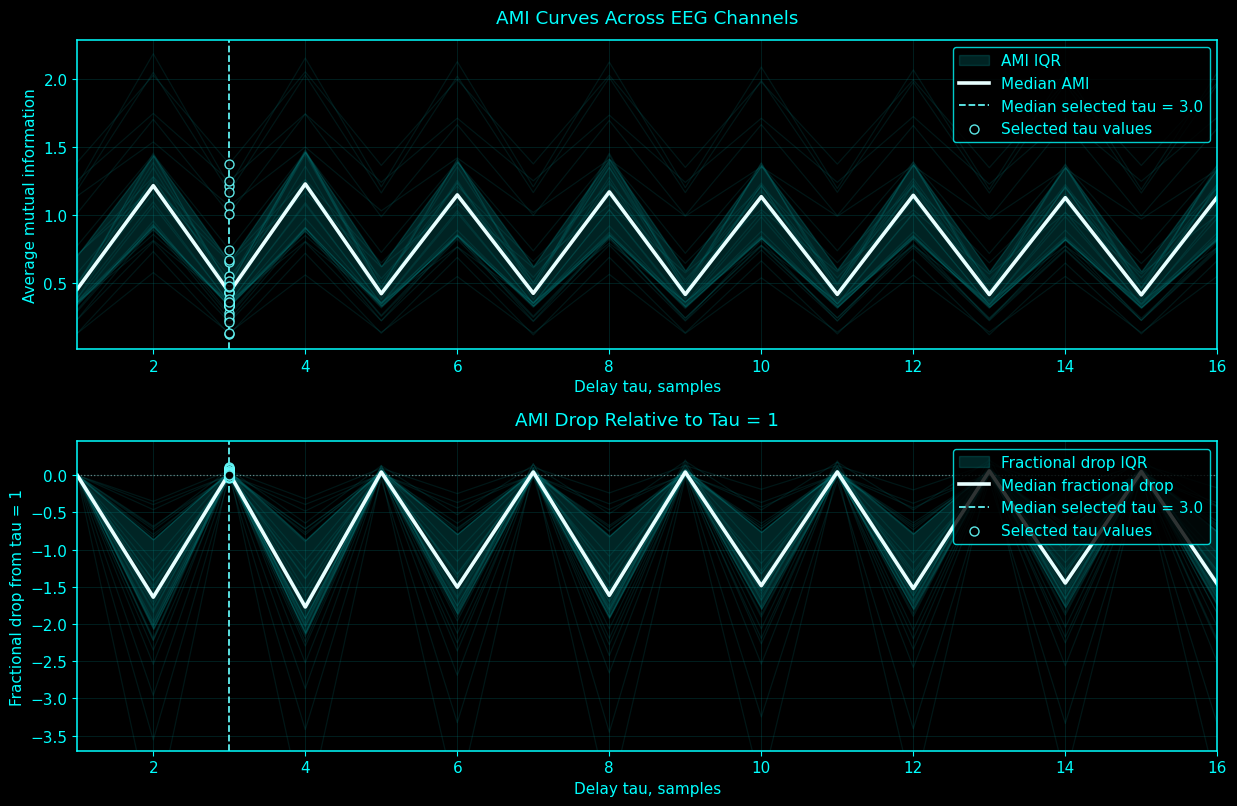

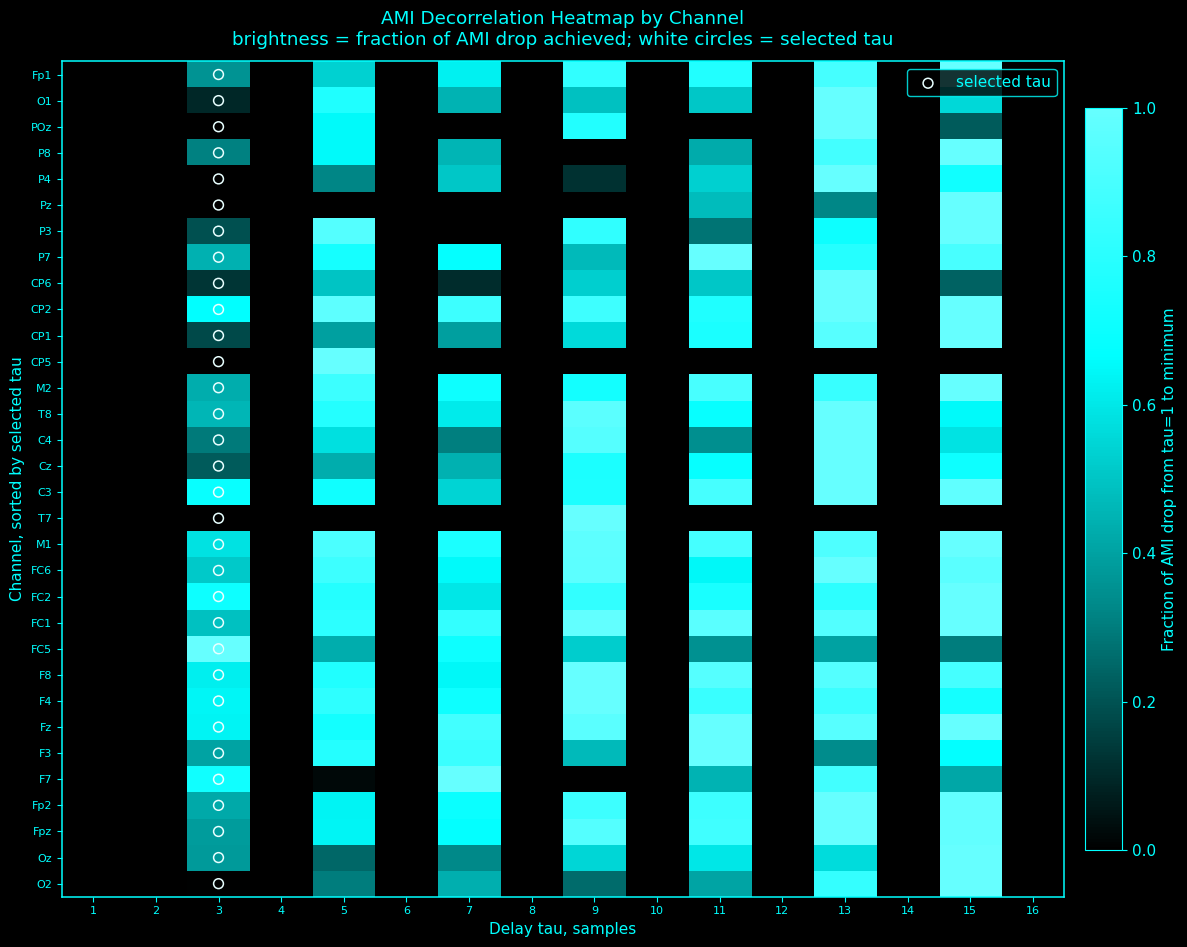

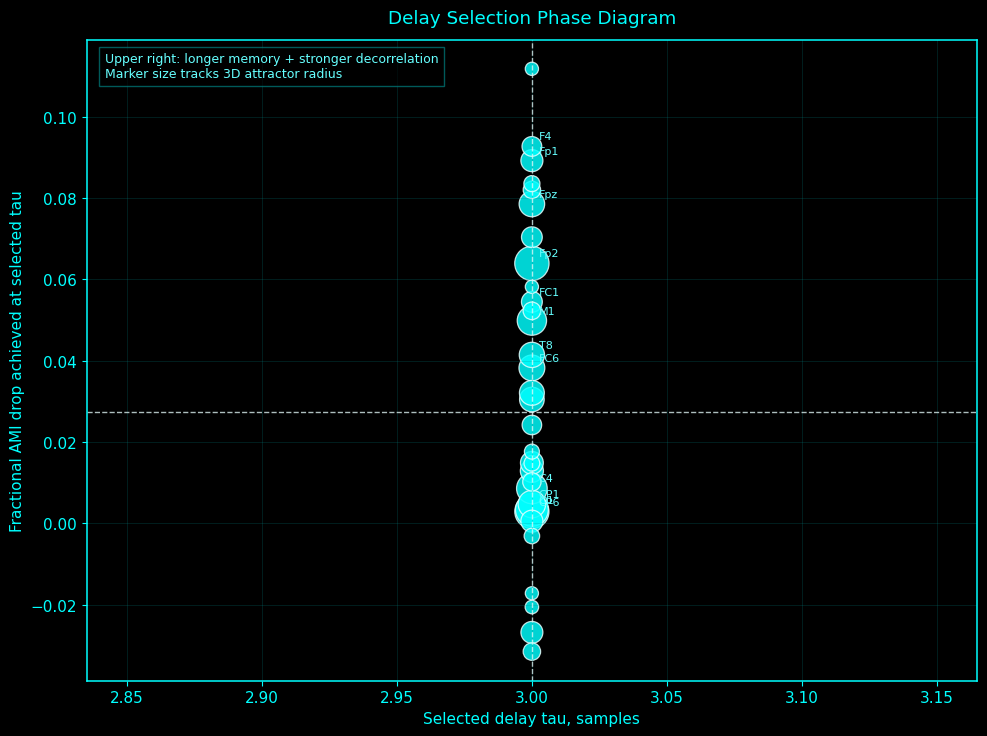

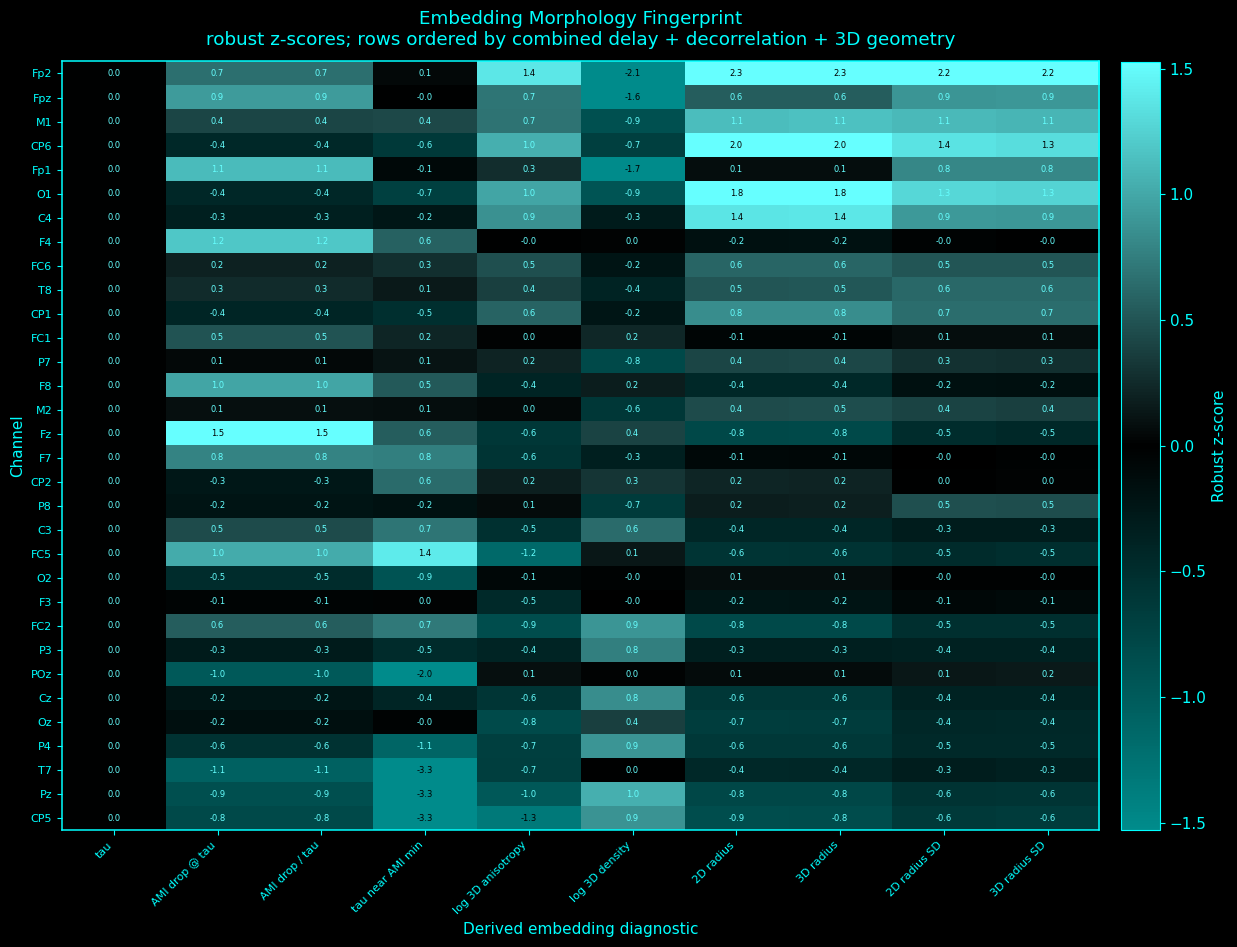

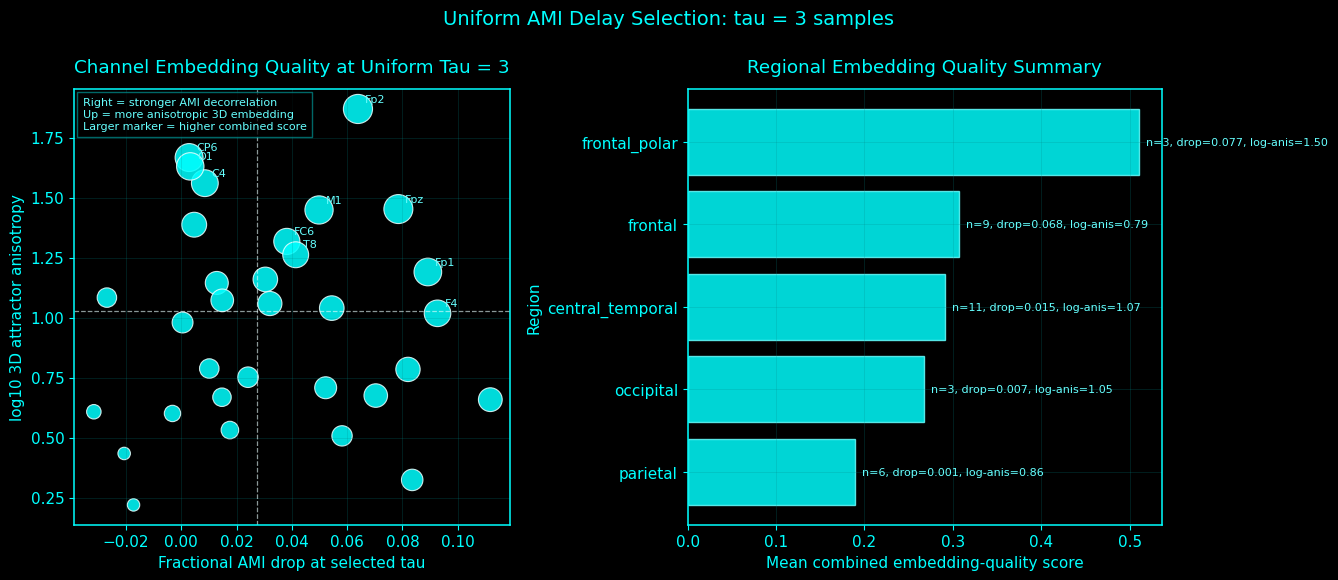

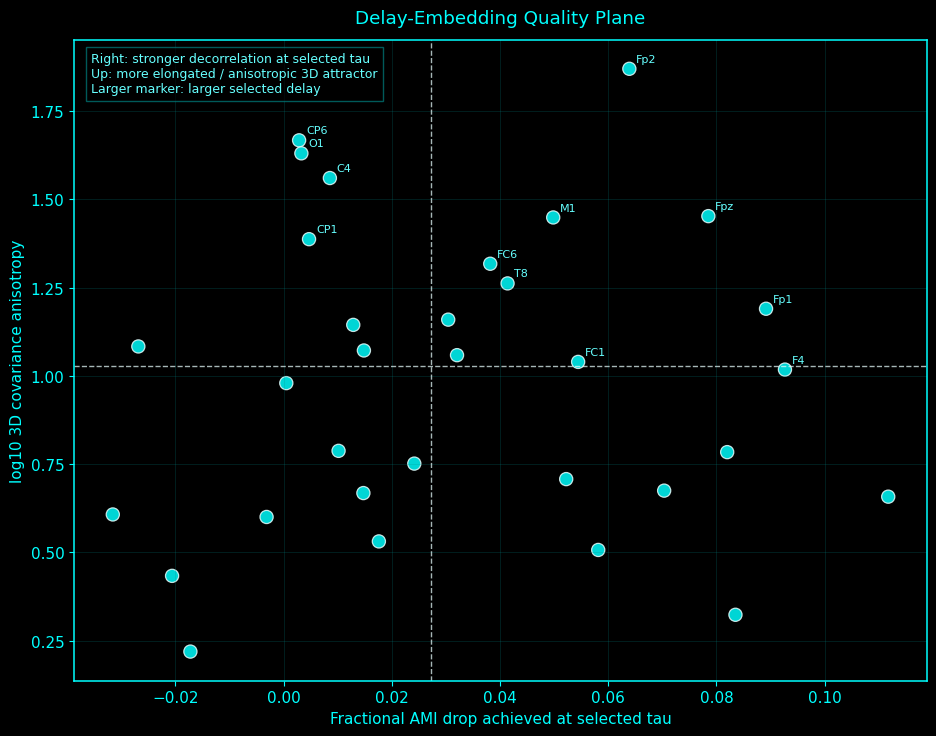

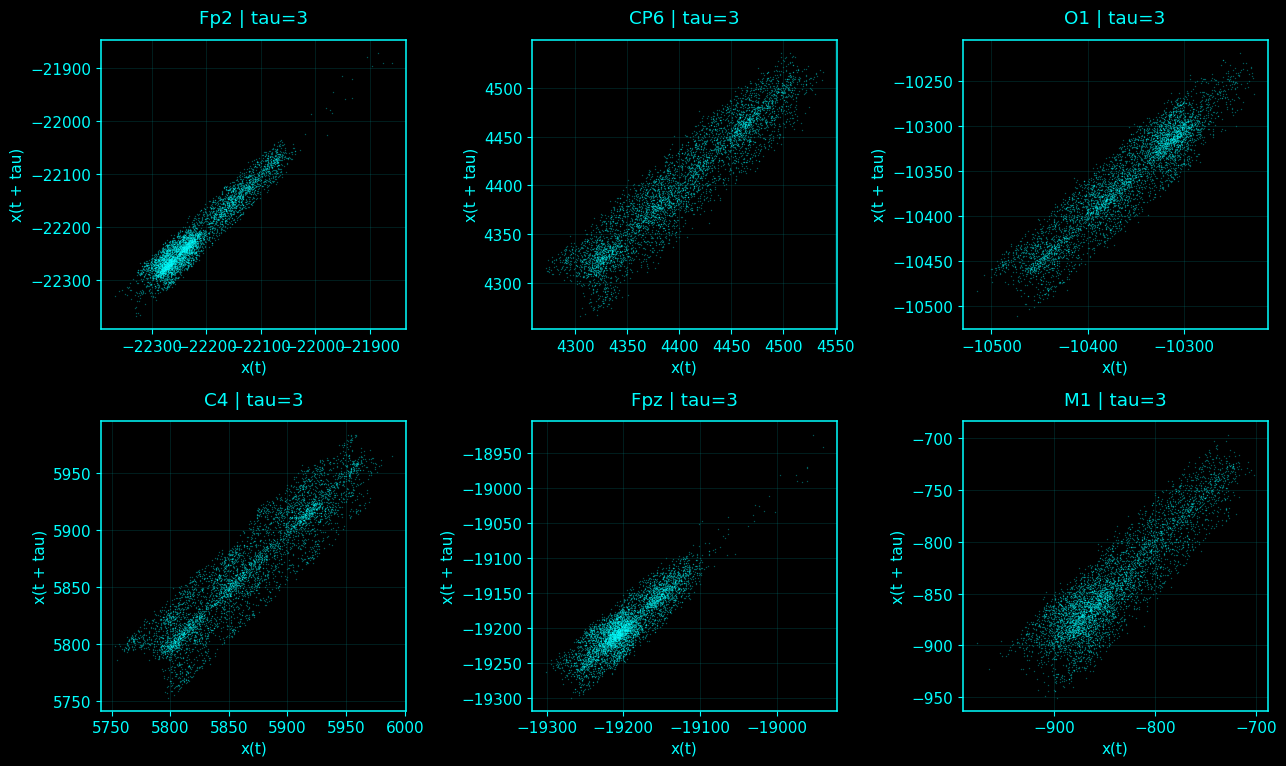

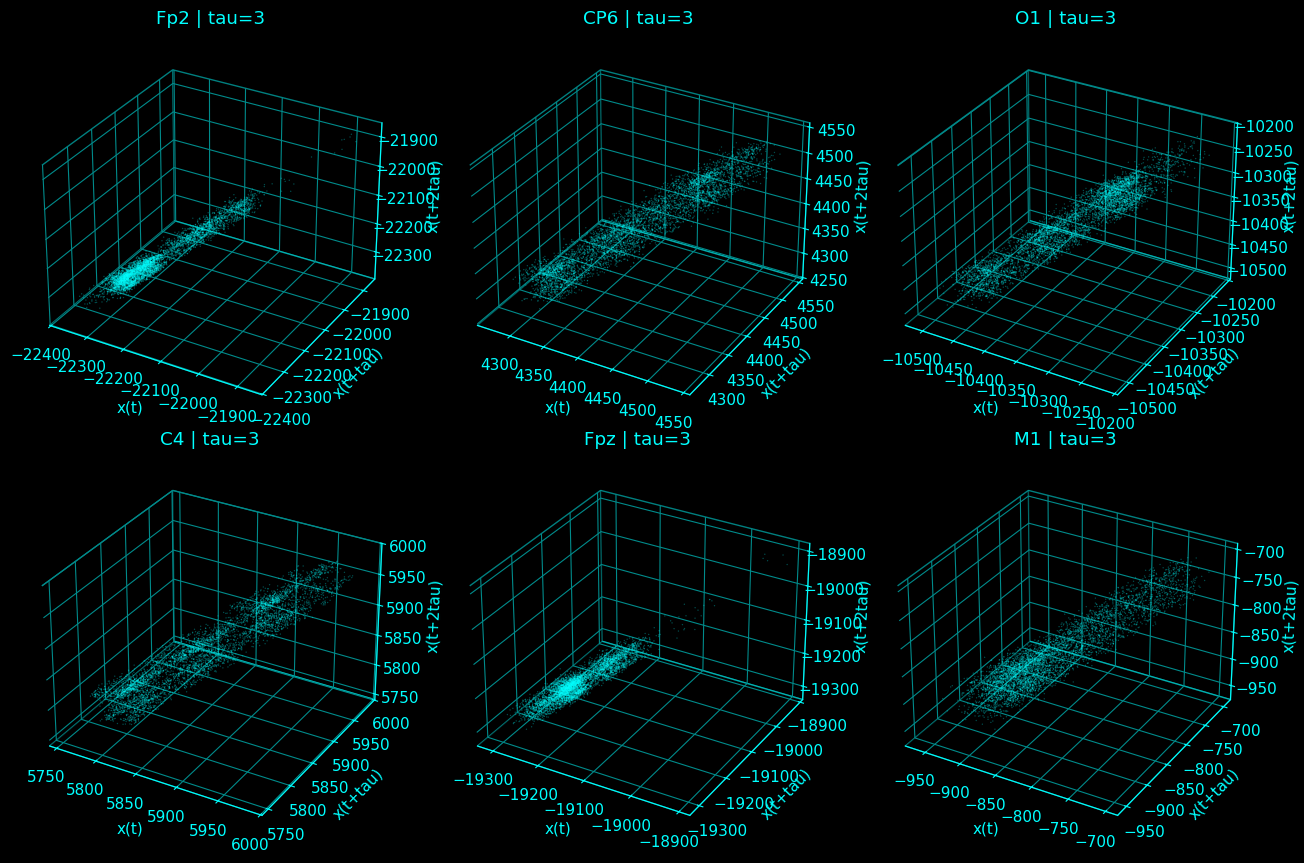

Zipped: /home/a/projects/Complete-Neural-Signal-Analysis/2d_embedded_data_ultra.zip
Zipped: /home/a/projects/Complete-Neural-Signal-Analysis/3d_embedded_data_ultra.zip

EXPERT DELAY EMBEDDING 2D/3D SUMMARY
FAST_OPTION: ultra
Channels embedded: 32
Mean tau: 3.000
Median tau: 3.000
Min tau: 3
Max tau: 3
Mean 3D anisotropy: 15.2429
Total elapsed: 0.34 min

Top 12 channels by delay-embedding interest score:
channel  tau  ami_fractional_drop_to_tau  ami_tau_closeness_to_min  3d_cov_anisotropy  3d_mean_radius  delay_embedding_interest_score hemisphere           region
    Fp2    3                    0.063900                  0.421078          74.101238       98.953204                        0.587910      right    frontal_polar
    Fpz    3                    0.078504                  0.386406          28.351587       59.290606                        0.497710    midline    frontal_polar
     M1    3                    0.049826                  0.582307          28.108022       72.873366      

In [2]:
import os
import glob
import time
import math
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from numpy.lib.stride_tricks import sliding_window_view

try:
    from IPython.display import display
    _HAVE_IPYTHON_DISPLAY = True
except Exception:
    display = None
    _HAVE_IPYTHON_DISPLAY = False


base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

embedding_root_dir = os.path.join(base_dir, "embedding_data")
embedding_2d_dir = os.path.join(embedding_root_dir, "2dembedding_data")
embedding_3d_dir = os.path.join(embedding_root_dir, "3dembedding_data")

results_dir = os.path.join(base_dir, "results", "delay_embedding_2d3d_expert_fast")
plots_directory = os.path.join(base_dir, "plots", "delay_embedding_2d3d_expert_fast")
per_channel_2d_dir = os.path.join(plots_directory, "per_channel_2d")
per_channel_3d_dir = os.path.join(plots_directory, "per_channel_3d")
gallery_dir = os.path.join(plots_directory, "galleries")
diagnostic_dir = os.path.join(plots_directory, "diagnostics")

for dir_path in [
    embedding_root_dir,
    embedding_2d_dir,
    embedding_3d_dir,
    results_dir,
    plots_directory,
    per_channel_2d_dir,
    per_channel_3d_dir,
    gallery_dir,
    diagnostic_dir,
]:
    os.makedirs(dir_path, exist_ok=True)


FAST_OPTION = "ultra"

if FAST_OPTION == "ultra":
    max_delay = 16
    subsample_factor = 25
    n_bins = 32
    delay_rule = "first_local_min"
    binning_mode = "equal_width"
    plot_max_points = 5000
    gallery_top_n = 6
    run_fnn = False
    max_dim = 8
    fnn_R = 10.0
    fnn_max_points = 600
    fnn_channel_top_n = 0
    save_individual_plots = True
    show_individual_plots = False
    show_summary_plots = True
    dpi_save = 170

elif FAST_OPTION == "fast":
    max_delay = 24
    subsample_factor = 12
    n_bins = 48
    delay_rule = "first_local_min"
    binning_mode = "equal_width"
    plot_max_points = 10000
    gallery_top_n = 9
    run_fnn = False
    max_dim = 10
    fnn_R = 10.0
    fnn_max_points = 900
    fnn_channel_top_n = 0
    save_individual_plots = True
    show_individual_plots = False
    show_summary_plots = True
    dpi_save = 190

elif FAST_OPTION == "balanced":
    max_delay = 40
    subsample_factor = 8
    n_bins = 64
    delay_rule = "first_local_min"
    binning_mode = "quantile"
    plot_max_points = 15000
    gallery_top_n = 12
    run_fnn = True
    max_dim = 14
    fnn_R = 10.0
    fnn_max_points = 1200
    fnn_channel_top_n = 12
    save_individual_plots = True
    show_individual_plots = False
    show_summary_plots = True
    dpi_save = 220

elif FAST_OPTION == "full":
    max_delay = 60
    subsample_factor = 5
    n_bins = 80
    delay_rule = "first_local_min"
    binning_mode = "quantile"
    plot_max_points = 25000
    gallery_top_n = 16
    run_fnn = True
    max_dim = 20
    fnn_R = 10.0
    fnn_max_points = 2000
    fnn_channel_top_n = None
    save_individual_plots = True
    show_individual_plots = False
    show_summary_plots = True
    dpi_save = 240

else:
    raise ValueError("FAST_OPTION must be one of: 'ultra', 'fast', 'balanced', 'full'.")


sampling_rate = 1000
start_time = 814.571
end_time = 921.515
start_index = int(start_time * sampling_rate)
end_index = int(end_time * sampling_rate)

emb_dim_2d = 2
emb_dim_3d = 3

SHOW_PLOTS_IN_NOTEBOOK = True
SAVE_PLOTS_TO_DISK = True
ZIP_EMBEDDINGS = True
SAVE_FULL_EMBEDDINGS = True
STANDARDIZE_BEFORE_EMBEDDING = False

RANDOM_SEED = 0
rng = np.random.default_rng(RANDOM_SEED)

eeg_channel_names = [
    "Fp1", "Fpz", "Fp2", "F7", "F3", "Fz", "F4", "F8", "FC5", "FC1", "FC2", "FC6",
    "M1", "T7", "C3", "Cz", "C4", "T8", "M2", "CP5", "CP1", "CP2", "CP6",
    "P7", "P3", "Pz", "P4", "P8", "POz", "O1", "Oz", "O2"
]

left_channels = ["Fp1", "F7", "F3", "FC5", "FC1", "M1", "T7", "C3", "CP5", "CP1", "P7", "P3", "O1"]
right_channels = ["Fp2", "F8", "F4", "FC2", "FC6", "M2", "T8", "C4", "CP2", "CP6", "P8", "P4", "O2"]
midline_channels = ["Fpz", "Fz", "Cz", "Pz", "POz", "Oz"]

electrode_xy = {
    "Fp1": (-0.45, 1.00), "Fpz": (0.00, 1.05), "Fp2": (0.45, 1.00),
    "F7": (-0.95, 0.55), "F3": (-0.45, 0.55), "Fz": (0.00, 0.60), "F4": (0.45, 0.55), "F8": (0.95, 0.55),
    "FC5": (-0.70, 0.25), "FC1": (-0.25, 0.25), "FC2": (0.25, 0.25), "FC6": (0.70, 0.25),
    "M1": (-1.10, 0.00), "T7": (-0.95, 0.00), "C3": (-0.45, 0.00), "Cz": (0.00, 0.00), "C4": (0.45, 0.00), "T8": (0.95, 0.00), "M2": (1.10, 0.00),
    "CP5": (-0.70, -0.25), "CP1": (-0.25, -0.25), "CP2": (0.25, -0.25), "CP6": (0.70, -0.25),
    "P7": (-0.95, -0.55), "P3": (-0.45, -0.55), "Pz": (0.00, -0.60), "P4": (0.45, -0.55), "P8": (0.95, -0.55),
    "POz": (0.00, -0.82), "O1": (-0.35, -1.00), "Oz": (0.00, -1.05), "O2": (0.35, -1.00),
}

ACCENT = "#00FFFF"
ACCENT_SOFT = "#66FFFF"
ACCENT_DIM = "#008B8B"
WHITE = "#E8FFFF"
BLACK = "#000000"

CYAN_SEQUENTIAL_CMAP = LinearSegmentedColormap.from_list(
    "cyan_sequential",
    [BLACK, ACCENT_DIM, ACCENT, ACCENT_SOFT],
    N=256,
)

CYAN_DIVERGING_CMAP = LinearSegmentedColormap.from_list(
    "cyan_diverging",
    [ACCENT_DIM, BLACK, ACCENT_SOFT],
    N=256,
)

plt.rcParams.update({
    "figure.facecolor": BLACK,
    "axes.facecolor": BLACK,
    "savefig.facecolor": BLACK,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT_DIM,
    "grid.alpha": 0.25,
    "legend.facecolor": BLACK,
    "legend.edgecolor": ACCENT,
    "legend.labelcolor": ACCENT,
    "font.size": 11,
})


def style_ax(ax, title=None, xlabel=None, ylabel=None, grid=True):
    ax.set_facecolor(BLACK)

    for spine in ax.spines.values():
        spine.set_color(ACCENT)
        spine.set_linewidth(1.1)

    ax.tick_params(axis="x", colors=ACCENT, labelcolor=ACCENT)
    ax.tick_params(axis="y", colors=ACCENT, labelcolor=ACCENT)

    if title is not None:
        ax.set_title(title, color=ACCENT, pad=12)

    if xlabel is not None:
        ax.set_xlabel(xlabel, color=ACCENT)

    if ylabel is not None:
        ax.set_ylabel(ylabel, color=ACCENT)

    if grid:
        ax.grid(True, alpha=0.22, color=ACCENT_DIM, linewidth=0.7)
    else:
        ax.grid(False)


def style_3d_ax(ax, title=None, xlabel=None, ylabel=None, zlabel=None):
    ax.set_facecolor(BLACK)
    ax.xaxis.pane.set_facecolor(BLACK)
    ax.yaxis.pane.set_facecolor(BLACK)
    ax.zaxis.pane.set_facecolor(BLACK)
    ax.xaxis.pane.set_edgecolor(ACCENT)
    ax.yaxis.pane.set_edgecolor(ACCENT)
    ax.zaxis.pane.set_edgecolor(ACCENT)
    ax.tick_params(colors=ACCENT)
    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    ax.zaxis.label.set_color(ACCENT)

    if title is not None:
        ax.set_title(title, color=ACCENT, pad=12)

    if xlabel is not None:
        ax.set_xlabel(xlabel, color=ACCENT)

    if ylabel is not None:
        ax.set_ylabel(ylabel, color=ACCENT)

    if zlabel is not None:
        ax.set_zlabel(zlabel, color=ACCENT)


def save_fig(fig, path, show=True):
    fig.tight_layout()

    if SAVE_PLOTS_TO_DISK and path is not None:
        fig.savefig(path, dpi=dpi_save, bbox_inches="tight", facecolor=BLACK)

    if SHOW_PLOTS_IN_NOTEBOOK and show and _HAVE_IPYTHON_DISPLAY:
        display(fig)
    elif SHOW_PLOTS_IN_NOTEBOOK and show:
        plt.show()

    plt.close(fig)


def short_label(x, max_len=24):
    x = str(x)
    return x if len(x) <= max_len else x[:max_len - 1] + "…"


def ensure_time_channel_layout(EEG_data, channel_names):
    X = np.asarray(EEG_data, dtype=float)

    if X.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {X.shape}")

    n_expected = len(channel_names)

    if X.shape[1] == n_expected:
        return X, channel_names

    if X.shape[0] == n_expected:
        return X.T, channel_names

    if X.shape[1] > n_expected:
        return X[:, :n_expected], channel_names

    if X.shape[0] > n_expected:
        return X.T[:, :n_expected], channel_names

    if X.shape[1] < n_expected:
        return X, channel_names[:X.shape[1]]

    if X.shape[0] < n_expected:
        return X.T, channel_names[:X.shape[0]]

    raise ValueError(f"Unexpected EEG shape: {X.shape}")


def safe_nan_to_num_1d(x):
    x = np.asarray(x, dtype=float).reshape(-1)
    x = np.where(np.isfinite(x), x, np.nan)

    if np.any(~np.isfinite(x)):
        med = np.nanmedian(x)

        if not np.isfinite(med):
            med = 0.0

        x = np.nan_to_num(x, nan=med, posinf=med, neginf=med)

    return x


def standardize_1d(x):
    x = safe_nan_to_num_1d(x)
    return (x - np.mean(x)) / (np.std(x) + 1e-12)


def digitize_equal_width(x, n_bins=64):
    x = standardize_1d(x)
    xmin, xmax = np.min(x), np.max(x)

    if not np.isfinite(xmin) or not np.isfinite(xmax) or xmax <= xmin:
        return np.zeros_like(x, dtype=np.int32)

    edges = np.linspace(xmin, xmax, n_bins + 1)
    xb = np.digitize(x, edges[1:-1], right=False).astype(np.int32)
    xb = np.clip(xb, 0, n_bins - 1)

    return xb


def digitize_quantile(x, n_bins=64):
    x = standardize_1d(x)

    if np.std(x) < 1e-12:
        return np.zeros_like(x, dtype=np.int32)

    edges = np.quantile(x, np.linspace(0, 1, n_bins + 1))
    edges = np.unique(edges)

    if len(edges) <= 2:
        return digitize_equal_width(x, n_bins=n_bins)

    xb = np.digitize(x, edges[1:-1], right=False).astype(np.int32)
    xb = np.clip(xb, 0, n_bins - 1)

    return xb


def bin_signal(x, n_bins=64, mode="equal_width"):
    if mode == "equal_width":
        return digitize_equal_width(x, n_bins=n_bins)

    if mode == "quantile":
        return digitize_quantile(x, n_bins=n_bins)

    raise ValueError("binning_mode must be 'equal_width' or 'quantile'.")


def average_mutual_information_from_binned(xb, max_delay=20, n_bins=64):
    xb = np.asarray(xb, dtype=np.int32)
    N = len(xb)
    ami = np.full(max_delay, np.nan, dtype=float)

    for tau in range(1, max_delay + 1):
        if tau >= N:
            continue

        x1 = xb[:-tau]
        x2 = xb[tau:]

        joint_idx = x1 * n_bins + x2
        joint = np.bincount(
            joint_idx,
            minlength=n_bins * n_bins
        ).reshape(n_bins, n_bins).astype(float)

        total = joint.sum()

        if total <= 0:
            continue

        pxy = joint / total
        px = pxy.sum(axis=1, keepdims=True)
        py = pxy.sum(axis=0, keepdims=True)
        denom = px @ py

        mask = (pxy > 0) & (denom > 0)

        ami[tau - 1] = float(np.sum(pxy[mask] * np.log(pxy[mask] / denom[mask])))

    return ami


def first_local_minimum(y):
    y = np.asarray(y, dtype=float)
    finite = np.isfinite(y)

    if not np.any(finite):
        return 0

    for i in range(1, len(y) - 1):
        if np.isfinite(y[i - 1]) and np.isfinite(y[i]) and np.isfinite(y[i + 1]):
            if y[i] < y[i - 1] and y[i] <= y[i + 1]:
                return int(i)

    return int(np.nanargmin(y))


def determine_delay(data, max_delay=20, subsample_factor=10, n_bins=64, rule="first_local_min", binning_mode="equal_width"):
    xs = np.asarray(data, dtype=float)[::subsample_factor]
    xb = bin_signal(xs, n_bins=n_bins, mode=binning_mode)
    ami = average_mutual_information_from_binned(xb, max_delay=max_delay, n_bins=n_bins)

    if rule == "first_local_min":
        idx = first_local_minimum(ami)
    elif rule == "global_min":
        idx = int(np.nanargmin(ami))
    else:
        raise ValueError(f"Unknown delay_rule: {rule}")

    tau = idx + 1

    return tau, ami


def delay_embedding(data, emb_dim, delay):
    x = np.asarray(data, dtype=float).reshape(-1)

    if STANDARDIZE_BEFORE_EMBEDDING:
        x = standardize_1d(x)
    else:
        x = safe_nan_to_num_1d(x)

    span = (emb_dim - 1) * delay + 1
    M = len(x) - span + 1

    if M <= 0:
        return None

    win = sliding_window_view(x, span)
    emb = win[:, ::delay]

    if emb.shape[1] != emb_dim:
        emb = emb[:, :emb_dim]

    return np.asarray(emb, dtype=float)


def subsample_rows(X, max_points=15000, rng=None):
    X = np.asarray(X)

    if rng is None:
        rng = np.random.default_rng()

    n = len(X)

    if max_points is None or n <= max_points:
        return X, np.arange(n)

    idx = np.sort(rng.choice(n, size=max_points, replace=False))
    return X[idx], idx


def embedding_geometry_metrics(X2, X3):
    X2 = np.asarray(X2, dtype=float)
    X3 = np.asarray(X3, dtype=float)

    out = {}

    for name, X in [("2d", X2), ("3d", X3)]:
        if X is None or len(X) < 3:
            out[f"{name}_x_range"] = np.nan
            out[f"{name}_y_range"] = np.nan
            out[f"{name}_z_range"] = np.nan
            out[f"{name}_bbox_volume"] = np.nan
            out[f"{name}_density_bbox"] = np.nan
            out[f"{name}_cov_anisotropy"] = np.nan
            out[f"{name}_mean_radius"] = np.nan
            out[f"{name}_std_radius"] = np.nan
            continue

        Xc = X - np.mean(X, axis=0, keepdims=True)
        ranges = np.max(X, axis=0) - np.min(X, axis=0)

        bbox = float(np.prod(np.maximum(ranges, 1e-12)))
        density = float(len(X) / bbox)

        cov = np.cov(Xc.T)
        eig = np.linalg.eigvalsh(cov)
        eig = np.sort(np.maximum(eig, 1e-12))
        anis = float(eig[-1] / eig[0])

        radius = np.sqrt(np.sum(Xc ** 2, axis=1))

        out[f"{name}_x_range"] = float(ranges[0]) if len(ranges) > 0 else np.nan
        out[f"{name}_y_range"] = float(ranges[1]) if len(ranges) > 1 else np.nan
        out[f"{name}_z_range"] = float(ranges[2]) if len(ranges) > 2 else np.nan
        out[f"{name}_bbox_volume"] = bbox
        out[f"{name}_density_bbox"] = density
        out[f"{name}_cov_anisotropy"] = anis
        out[f"{name}_mean_radius"] = float(np.mean(radius))
        out[f"{name}_std_radius"] = float(np.std(radius))

    return out


def nearest_neighbor_indices_bruteforce(X, chunk_size=256):
    X = np.asarray(X, dtype=float)
    n = len(X)

    nn_idx = np.full(n, -1, dtype=int)
    nn_dist = np.full(n, np.nan, dtype=float)

    for start in range(0, n, chunk_size):
        end = min(n, start + chunk_size)
        chunk = X[start:end]

        d2 = np.sum((chunk[:, None, :] - X[None, :, :]) ** 2, axis=2)

        for local_i, global_i in enumerate(range(start, end)):
            d2[local_i, global_i] = np.inf

        idx = np.argmin(d2, axis=1)
        dist = np.sqrt(d2[np.arange(end - start), idx])

        nn_idx[start:end] = idx
        nn_dist[start:end] = dist

    return nn_idx, nn_dist


def false_nearest_neighbors_manual(data, max_dim, delay, R=10.0, max_points=1200, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    x = safe_nan_to_num_1d(data)
    fnn = np.full(max_dim, np.nan, dtype=float)
    sample_counts = np.zeros(max_dim, dtype=int)

    for d in range(1, max_dim):
        Xd = delay_embedding(x, d, delay)
        Xd1 = delay_embedding(x, d + 1, delay)

        if Xd is None or Xd1 is None:
            continue

        M = min(len(Xd), len(Xd1))
        Xd = Xd[:M]
        Xd1 = Xd1[:M]

        if M < 10:
            continue

        if max_points is not None and M > max_points:
            idx = np.sort(rng.choice(M, size=max_points, replace=False))
            Xs = Xd[idx]
            Xs1 = Xd1[idx]
        else:
            Xs = Xd
            Xs1 = Xd1

        nn_idx, dist_d = nearest_neighbor_indices_bruteforce(Xs)
        valid = (nn_idx >= 0) & np.isfinite(dist_d)

        if np.sum(valid) < 5:
            continue

        extra_coord_diff = np.abs(Xs1[:, -1] - Xs1[nn_idx, -1])
        ratio = extra_coord_diff / (dist_d + 1e-12)

        fnn[d - 1] = float(np.mean(ratio[valid] > R))
        sample_counts[d - 1] = int(np.sum(valid))

    return fnn, sample_counts


def add_channel_metadata(df):
    df = df.copy()
    hemispheres = []
    regions = []

    for ch in df["channel"]:
        if ch in left_channels:
            hemispheres.append("left")
        elif ch in right_channels:
            hemispheres.append("right")
        elif ch in midline_channels:
            hemispheres.append("midline")
        else:
            hemispheres.append("unknown")

        if ch.startswith("Fp"):
            regions.append("frontal_polar")
        elif ch.startswith("F") or ch.startswith("FC"):
            regions.append("frontal")
        elif ch.startswith("C") or ch.startswith("T") or ch.startswith("M"):
            regions.append("central_temporal")
        elif ch.startswith("CP") or ch.startswith("P"):
            regions.append("parietal")
        elif ch.startswith("PO") or ch.startswith("O"):
            regions.append("occipital")
        else:
            regions.append("unknown")

    df["hemisphere"] = hemispheres
    df["region"] = regions

    return df


def _safe_numeric_array(x):
    x = np.asarray(x, dtype=float)
    x = np.where(np.isfinite(x), x, np.nan)
    return x


def _robust_minmax(x, lo=3, hi=97):
    x = _safe_numeric_array(x)
    finite = x[np.isfinite(x)]

    if finite.size == 0:
        return np.zeros_like(x, dtype=float)

    a = np.nanpercentile(finite, lo)
    b = np.nanpercentile(finite, hi)

    if not np.isfinite(a) or not np.isfinite(b) or b <= a:
        return np.zeros_like(x, dtype=float)

    return np.clip((x - a) / (b - a + 1e-12), 0, 1)


def _robust_z(x):
    x = _safe_numeric_array(x)
    finite = x[np.isfinite(x)]

    if finite.size == 0:
        return np.zeros_like(x, dtype=float)

    med = np.nanmedian(finite)
    q25 = np.nanpercentile(finite, 25)
    q75 = np.nanpercentile(finite, 75)
    iqr = q75 - q25

    if not np.isfinite(iqr) or iqr <= 1e-12:
        sd = np.nanstd(finite) + 1e-12
        return (x - med) / sd

    return (x - med) / (iqr + 1e-12)


def _ami_matrix_from_store(ami_store):
    channels = list(ami_store.keys())

    if len(channels) == 0:
        return channels, np.empty((0, 0), dtype=float)

    max_len = max(len(np.asarray(v).reshape(-1)) for v in ami_store.values())
    M = np.full((len(channels), max_len), np.nan, dtype=float)

    for i, ch in enumerate(channels):
        vals = np.asarray(ami_store[ch], dtype=float).reshape(-1)
        M[i, :len(vals)] = vals

    return channels, M


def _add_delay_quality_columns(df):
    df = df.copy()

    for c in ["ami_first", "ami_at_tau", "ami_min", "ami_last"]:
        if c not in df.columns:
            df[c] = np.nan

    df["ami_fractional_drop_to_tau"] = (
        (df["ami_first"] - df["ami_at_tau"])
        / (np.abs(df["ami_first"]) + 1e-12)
    )

    df["ami_fractional_drop_to_min"] = (
        (df["ami_first"] - df["ami_min"])
        / (np.abs(df["ami_first"]) + 1e-12)
    )

    df["tau_selection_efficiency"] = (
        df["ami_fractional_drop_to_tau"]
        / (df["tau"].astype(float) + 1e-12)
    )

    df["ami_tau_closeness_to_min"] = 1.0 - (
        np.abs(df["ami_at_tau"] - df["ami_min"])
        / (np.abs(df["ami_first"] - df["ami_min"]) + 1e-12)
    )

    df["ami_tau_closeness_to_min"] = df["ami_tau_closeness_to_min"].clip(-1, 1)

    if "3d_cov_anisotropy" in df.columns:
        df["log10_3d_anisotropy"] = np.log10(np.maximum(df["3d_cov_anisotropy"].astype(float), 1e-12))
    else:
        df["log10_3d_anisotropy"] = np.nan

    if "3d_density_bbox" in df.columns:
        df["log10_3d_density"] = np.log10(np.maximum(df["3d_density_bbox"].astype(float), 1e-12))
    else:
        df["log10_3d_density"] = np.nan

    df["delay_embedding_interest_score"] = (
        0.35 * _robust_minmax(df["tau"].to_numpy(dtype=float))
        + 0.25 * _robust_minmax(df["ami_fractional_drop_to_tau"].to_numpy(dtype=float))
        + 0.25 * _robust_minmax(df["log10_3d_anisotropy"].to_numpy(dtype=float))
        + 0.15 * _robust_minmax(df.get("3d_mean_radius", pd.Series(np.nan, index=df.index)).to_numpy(dtype=float))
    )

    return df


def plot_2d_embedding(X2, channel_name, tau, path, show=False):
    X2_plot, _ = subsample_rows(X2, max_points=plot_max_points, rng=rng)

    fig, ax = plt.subplots(figsize=(8, 6), facecolor=BLACK)

    ax.scatter(
        X2_plot[:, 0],
        X2_plot[:, 1],
        s=1.0,
        color=ACCENT,
        alpha=0.38,
        linewidths=0,
    )

    style_ax(
        ax,
        title=f"2D Phase Space Reconstruction | {channel_name} | tau={tau}",
        xlabel="x(t)",
        ylabel=f"x(t + {tau})",
        grid=True,
    )

    save_fig(fig, path, show=show)

    return path


def plot_3d_embedding(X3, channel_name, tau, path, show=False):
    X3_plot, _ = subsample_rows(X3, max_points=plot_max_points, rng=rng)

    fig = plt.figure(figsize=(8, 6), facecolor=BLACK)
    ax = fig.add_subplot(111, projection="3d")

    ax.scatter(
        X3_plot[:, 0],
        X3_plot[:, 1],
        X3_plot[:, 2],
        s=1.0,
        color=ACCENT,
        alpha=0.32,
        linewidths=0,
    )

    style_3d_ax(
        ax,
        title=f"3D Phase Space Reconstruction | {channel_name} | tau={tau}",
        xlabel="x(t)",
        ylabel=f"x(t + {tau})",
        zlabel=f"x(t + {2 * tau})",
    )

    save_fig(fig, path, show=show)

    return path


def plot_ami_curves_all(ami_store, tau_df):
    if len(ami_store) == 0:
        return None

    channels, M = _ami_matrix_from_store(ami_store)

    if M.size == 0:
        return None

    delays = np.arange(1, M.shape[1] + 1)

    tau_map = {}
    if not tau_df.empty and "channel" in tau_df.columns and "tau" in tau_df.columns:
        tau_map = dict(zip(tau_df["channel"], tau_df["tau"]))

    M_clean = np.asarray(M, dtype=float).copy()

    for i in range(M_clean.shape[0]):
        row = M_clean[i]
        if np.any(~np.isfinite(row)):
            med = np.nanmedian(row)
            if not np.isfinite(med):
                med = 0.0
            row[~np.isfinite(row)] = med
            M_clean[i] = row

    raw_median = np.nanmedian(M_clean, axis=0)
    raw_q25 = np.nanpercentile(M_clean, 25, axis=0)
    raw_q75 = np.nanpercentile(M_clean, 75, axis=0)

    drop_from_tau1 = np.full_like(M_clean, np.nan, dtype=float)

    for i in range(M_clean.shape[0]):
        row = M_clean[i].copy()
        base = row[0]

        if not np.isfinite(base) or abs(base) < 1e-12:
            continue

        drop_from_tau1[i] = (base - row) / (abs(base) + 1e-12)

    drop_median = np.nanmedian(drop_from_tau1, axis=0)
    drop_q25 = np.nanpercentile(drop_from_tau1, 25, axis=0)
    drop_q75 = np.nanpercentile(drop_from_tau1, 75, axis=0)

    tau_vals = []
    tau_y_raw = []
    tau_y_drop = []

    for ch_i, ch in enumerate(channels):
        tau = tau_map.get(ch, np.nan)

        if not np.isfinite(tau):
            continue

        tau_i = int(tau) - 1

        if tau_i < 0 or tau_i >= M_clean.shape[1]:
            continue

        tau_vals.append(float(tau))
        tau_y_raw.append(float(M_clean[ch_i, tau_i]))
        tau_y_drop.append(float(drop_from_tau1[ch_i, tau_i]))

    tau_vals = np.asarray(tau_vals, dtype=float)
    tau_y_raw = np.asarray(tau_y_raw, dtype=float)
    tau_y_drop = np.asarray(tau_y_drop, dtype=float)

    fig, axes = plt.subplots(
        2,
        1,
        figsize=(12.5, 8.2),
        facecolor=BLACK,
        gridspec_kw={"height_ratios": [1.0, 1.0]},
    )

    ax = axes[0]

    for i in range(M_clean.shape[0]):
        ax.plot(
            delays,
            M_clean[i],
            color=ACCENT_DIM,
            alpha=0.16,
            linewidth=0.9,
        )

    ax.fill_between(
        delays,
        raw_q25,
        raw_q75,
        color=ACCENT,
        alpha=0.14,
        label="AMI IQR",
    )

    ax.plot(
        delays,
        raw_median,
        color=WHITE,
        linewidth=2.6,
        label="Median AMI",
    )

    if tau_vals.size:
        med_tau = float(np.nanmedian(tau_vals))

        ax.axvline(
            med_tau,
            color=ACCENT_SOFT,
            linestyle="--",
            linewidth=1.3,
            alpha=0.95,
            label=f"Median selected tau = {med_tau:.1f}",
        )

        ax.scatter(
            tau_vals,
            tau_y_raw,
            s=42,
            facecolors=BLACK,
            edgecolors=ACCENT_SOFT,
            linewidths=1.0,
            alpha=0.90,
            label="Selected tau values",
            zorder=5,
        )

    style_ax(
        ax,
        title="AMI Curves Across EEG Channels",
        xlabel="Delay tau, samples",
        ylabel="Average mutual information",
    )

    ax.set_xlim(delays[0], delays[-1])

    leg = ax.legend(loc="upper right", frameon=True)
    for text in leg.get_texts():
        text.set_color(ACCENT)

    ax = axes[1]

    for i in range(drop_from_tau1.shape[0]):
        ax.plot(
            delays,
            drop_from_tau1[i],
            color=ACCENT_DIM,
            alpha=0.16,
            linewidth=0.9,
        )

    ax.fill_between(
        delays,
        drop_q25,
        drop_q75,
        color=ACCENT,
        alpha=0.15,
        label="Fractional drop IQR",
    )

    ax.plot(
        delays,
        drop_median,
        color=WHITE,
        linewidth=2.6,
        label="Median fractional drop",
    )

    if tau_vals.size:
        med_tau = float(np.nanmedian(tau_vals))

        ax.axvline(
            med_tau,
            color=ACCENT_SOFT,
            linestyle="--",
            linewidth=1.3,
            alpha=0.95,
            label=f"Median selected tau = {med_tau:.1f}",
        )

        ax.scatter(
            tau_vals,
            tau_y_drop,
            s=42,
            facecolors=BLACK,
            edgecolors=ACCENT_SOFT,
            linewidths=1.0,
            alpha=0.90,
            label="Selected tau values",
            zorder=5,
        )

    ax.axhline(0.0, color=WHITE, linestyle=":", linewidth=0.9, alpha=0.45)

    style_ax(
        ax,
        title="AMI Drop Relative to Tau = 1",
        xlabel="Delay tau, samples",
        ylabel="Fractional drop from tau = 1",
    )

    ax.set_xlim(delays[0], delays[-1])

    finite_drop = drop_from_tau1[np.isfinite(drop_from_tau1)]
    if finite_drop.size:
        ymin = np.nanpercentile(finite_drop, 2)
        ymax = np.nanpercentile(finite_drop, 98)
        pad = 0.08 * max(ymax - ymin, 1e-6)
        ax.set_ylim(ymin - pad, ymax + pad)

    leg = ax.legend(loc="upper right", frameon=True)
    for text in leg.get_texts():
        text.set_color(ACCENT)

    path = os.path.join(diagnostic_dir, f"01_ami_decay_diagnostic_envelope_{FAST_OPTION}.png")
    save_fig(fig, path, show=show_summary_plots)

    return path

def plot_ami_heatmap(ami_store, tau_df):
    if len(ami_store) == 0:
        return None

    channels, M = _ami_matrix_from_store(ami_store)

    if M.size == 0:
        return None

    tau_map = {}

    if not tau_df.empty and "channel" in tau_df.columns and "tau" in tau_df.columns:
        tau_map = dict(zip(tau_df["channel"], tau_df["tau"]))

    M_drop = np.full_like(M, np.nan, dtype=float)

    for i in range(M.shape[0]):
        row = M[i].copy()
        finite = row[np.isfinite(row)]

        if finite.size < 3:
            continue

        first_val = row[0]
        min_val = np.nanmin(row)
        denom = first_val - min_val

        if not np.isfinite(denom) or abs(denom) < 1e-12:
            continue

        M_drop[i] = 1.0 - ((row - min_val) / (denom + 1e-12))

    order = np.arange(len(channels))

    if len(tau_map):
        order = np.argsort([tau_map.get(ch, np.inf) for ch in channels])

    channels_ord = [channels[i] for i in order]
    M_ord = M_drop[order]

    fig_height = min(10.5, max(7.0, 0.30 * len(channels_ord)))
    fig, ax = plt.subplots(figsize=(12, fig_height))

    im = ax.imshow(
        M_ord,
        aspect="auto",
        interpolation="nearest",
        cmap=CYAN_SEQUENTIAL_CMAP,
        vmin=0,
        vmax=1,
    )

    ax.set_xticks(np.arange(M_ord.shape[1]))
    ax.set_xticklabels(np.arange(1, M_ord.shape[1] + 1), color=ACCENT, fontsize=8)

    ax.set_yticks(np.arange(len(channels_ord)))
    ax.set_yticklabels(channels_ord, color=ACCENT, fontsize=8)

    selected_tau_x = []
    selected_tau_y = []

    for yi, ch in enumerate(channels_ord):
        tau = tau_map.get(ch, None)

        if tau is not None and np.isfinite(tau):
            selected_tau_x.append(float(tau) - 1.0)
            selected_tau_y.append(float(yi))

    if len(selected_tau_x):
        ax.scatter(
            selected_tau_x,
            selected_tau_y,
            s=50,
            facecolors="none",
            edgecolors=WHITE,
            linewidths=1.1,
            label="selected tau",
        )

    for yi in range(M_ord.shape[0]):
        row = M_ord[yi]

        if np.any(np.isfinite(row)):
            best_x = int(np.nanargmax(row))
            ax.scatter(
                best_x,
                yi,
                s=16,
                color=ACCENT_SOFT,
                alpha=0.80,
            )

    style_ax(
        ax,
        title=(
            "AMI Decorrelation Heatmap by Channel\n"
            "brightness = fraction of AMI drop achieved; white circles = selected tau"
        ),
        xlabel="Delay tau, samples",
        ylabel="Channel, sorted by selected tau",
        grid=False,
    )

    if len(selected_tau_x):
        leg = ax.legend(loc="upper right", frameon=True)
        for text in leg.get_texts():
            text.set_color(ACCENT)

    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.set_label("Fraction of AMI drop from tau=1 to minimum", color=ACCENT)

    path = os.path.join(diagnostic_dir, f"02_ami_decorrelation_landscape_{FAST_OPTION}.png")
    save_fig(fig, path, show=show_summary_plots)

    return path


def plot_tau_ranking(tau_df):
    if tau_df.empty:
        return None

    df = _add_delay_quality_columns(tau_df)

    df = df[
        np.isfinite(df["tau"])
        & np.isfinite(df["ami_fractional_drop_to_tau"])
    ].copy()

    if df.empty:
        return None

    df = df.sort_values("delay_embedding_interest_score", ascending=False)

    fig, ax = plt.subplots(figsize=(10, 7.5))

    size_metric = df.get("3d_mean_radius", pd.Series(1.0, index=df.index)).to_numpy(dtype=float)
    size_metric = _robust_minmax(size_metric)
    sizes = 90 + 520 * size_metric

    x = df["tau"].to_numpy(dtype=float)
    y = df["ami_fractional_drop_to_tau"].to_numpy(dtype=float)

    ax.scatter(
        x,
        y,
        s=sizes,
        c=ACCENT,
        edgecolors=WHITE,
        linewidths=0.9,
        alpha=0.83,
    )

    med_tau = np.nanmedian(x)
    med_drop = np.nanmedian(y)

    ax.axvline(med_tau, color=WHITE, linestyle="--", linewidth=1.0, alpha=0.75)
    ax.axhline(med_drop, color=WHITE, linestyle="--", linewidth=1.0, alpha=0.75)

    top = df.head(12)

    for _, row in top.iterrows():
        ax.annotate(
            row["channel"],
            (row["tau"], row["ami_fractional_drop_to_tau"]),
            xytext=(5, 5),
            textcoords="offset points",
            color=ACCENT_SOFT,
            fontsize=8,
        )

    ax.text(
        0.02,
        0.98,
        "Upper right: longer memory + stronger decorrelation\nMarker size tracks 3D attractor radius",
        transform=ax.transAxes,
        ha="left",
        va="top",
        color=ACCENT_SOFT,
        fontsize=9,
        bbox=dict(facecolor=BLACK, edgecolor=ACCENT_DIM, alpha=0.65),
    )

    style_ax(
        ax,
        title="Delay Selection Phase Diagram",
        xlabel="Selected delay tau, samples",
        ylabel="Fractional AMI drop achieved at selected tau",
    )

    path = os.path.join(diagnostic_dir, f"03_delay_selection_phase_diagram_{FAST_OPTION}.png")
    save_fig(fig, path, show=show_summary_plots)

    return path


def plot_embedding_geometry_heatmap(summary_df):
    if summary_df.empty:
        return None

    df = _add_delay_quality_columns(summary_df)

    candidate_metrics = [
        ("tau", "tau"),
        ("ami_fractional_drop_to_tau", "AMI drop @ tau"),
        ("tau_selection_efficiency", "AMI drop / tau"),
        ("ami_tau_closeness_to_min", "tau near AMI min"),
        ("log10_3d_anisotropy", "log 3D anisotropy"),
        ("log10_3d_density", "log 3D density"),
        ("2d_mean_radius", "2D radius"),
        ("3d_mean_radius", "3D radius"),
        ("2d_std_radius", "2D radius SD"),
        ("3d_std_radius", "3D radius SD"),
    ]

    metric_cols = [c for c, _ in candidate_metrics if c in df.columns]
    labels = [lab for c, lab in candidate_metrics if c in df.columns]

    if len(metric_cols) == 0:
        return None

    M = df[metric_cols].to_numpy(dtype=float)
    Z = np.zeros_like(M, dtype=float)

    for j in range(M.shape[1]):
        Z[:, j] = _robust_z(M[:, j])

    df["_ordering_score"] = (
        0.35 * _robust_minmax(df["tau"].to_numpy(dtype=float))
        + 0.25 * _robust_minmax(df["ami_fractional_drop_to_tau"].to_numpy(dtype=float))
        + 0.25 * _robust_minmax(df["log10_3d_anisotropy"].to_numpy(dtype=float))
        + 0.15 * _robust_minmax(df.get("3d_mean_radius", pd.Series(np.nan, index=df.index)).to_numpy(dtype=float))
    )

    order = np.argsort(df["_ordering_score"].to_numpy(dtype=float))[::-1]
    df_ord = df.iloc[order].copy()
    Z_ord = Z[order]

    if np.any(np.isfinite(Z_ord)):
        vmax = np.nanpercentile(np.abs(Z_ord[np.isfinite(Z_ord)]), 95)
    else:
        vmax = 1.0

    vmax = max(vmax, 1e-6)

    fig_height = min(10.5, max(7.0, 0.30 * len(df_ord)))
    fig, ax = plt.subplots(figsize=(12.5, fig_height))

    im = ax.imshow(
        Z_ord,
        aspect="auto",
        interpolation="nearest",
        cmap=CYAN_DIVERGING_CMAP,
        vmin=-vmax,
        vmax=vmax,
    )

    ax.set_xticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right", color=ACCENT, fontsize=8)

    ax.set_yticks(np.arange(len(df_ord)))
    ax.set_yticklabels(df_ord["channel"], color=ACCENT, fontsize=8)

    for i in range(Z_ord.shape[0]):
        for j in range(Z_ord.shape[1]):
            val = Z_ord[i, j]

            if np.isfinite(val):
                ax.text(
                    j,
                    i,
                    f"{val:.1f}",
                    ha="center",
                    va="center",
                    fontsize=6,
                    color=BLACK if abs(val) > 0.85 * vmax else ACCENT_SOFT,
                )

    style_ax(
        ax,
        title=(
            "Embedding Morphology Fingerprint\n"
            "robust z-scores; rows ordered by combined delay + decorrelation + 3D geometry"
        ),
        xlabel="Derived embedding diagnostic",
        ylabel="Channel",
        grid=False,
    )

    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.set_label("Robust z-score", color=ACCENT)

    path = os.path.join(diagnostic_dir, f"04_embedding_morphology_fingerprint_{FAST_OPTION}.png")
    save_fig(fig, path, show=show_summary_plots)

    return path


def plot_tau_topography(tau_df):
    if tau_df.empty:
        return None

    df = tau_df.copy()
    df = df[np.isfinite(df["tau"])]

    if df.empty:
        return None

    df = _add_delay_quality_columns(df)

    tau_vals = df["tau"].to_numpy(dtype=float)
    tau_unique = np.unique(tau_vals[np.isfinite(tau_vals)])

    if tau_unique.size <= 1 or np.nanmax(tau_vals) - np.nanmin(tau_vals) < 1e-9:
        tau_value = int(round(float(tau_unique[0]))) if tau_unique.size else np.nan

        if "log10_3d_anisotropy" not in df.columns:
            df["log10_3d_anisotropy"] = np.log10(np.maximum(df["3d_cov_anisotropy"].to_numpy(dtype=float), 1e-12))

        if "delay_embedding_interest_score" not in df.columns:
            df["delay_embedding_interest_score"] = (
                0.50 * _robust_minmax(df["ami_fractional_drop_to_tau"].to_numpy(dtype=float))
                + 0.50 * _robust_minmax(df["log10_3d_anisotropy"].to_numpy(dtype=float))
            )

        region_summary = (
            df.groupby("region")
            .agg(
                n=("channel", "count"),
                mean_tau=("tau", "mean"),
                mean_ami_drop=("ami_fractional_drop_to_tau", "mean"),
                mean_log_anisotropy=("log10_3d_anisotropy", "mean"),
                mean_interest_score=("delay_embedding_interest_score", "mean"),
            )
            .reset_index()
            .sort_values("mean_interest_score", ascending=True)
        )

        fig, axes = plt.subplots(
            1,
            2,
            figsize=(13.5, 5.8),
            facecolor=BLACK,
            gridspec_kw={"width_ratios": [1.15, 1.25]},
        )

        ax = axes[0]

        x = df["ami_fractional_drop_to_tau"].to_numpy(dtype=float)
        y = df["log10_3d_anisotropy"].to_numpy(dtype=float)
        score = df["delay_embedding_interest_score"].to_numpy(dtype=float)

        score_norm = _robust_minmax(score)
        sizes = 80 + 360 * score_norm

        ax.scatter(
            x,
            y,
            s=sizes,
            color=ACCENT,
            edgecolors=WHITE,
            linewidths=0.8,
            alpha=0.86,
        )

        if np.any(np.isfinite(x)):
            ax.axvline(np.nanmedian(x), color=WHITE, linestyle="--", linewidth=0.9, alpha=0.60)

        if np.any(np.isfinite(y)):
            ax.axhline(np.nanmedian(y), color=WHITE, linestyle="--", linewidth=0.9, alpha=0.60)

        top_labels = df.sort_values("delay_embedding_interest_score", ascending=False).head(10)

        for _, row in top_labels.iterrows():
            if np.isfinite(row["ami_fractional_drop_to_tau"]) and np.isfinite(row["log10_3d_anisotropy"]):
                ax.annotate(
                    row["channel"],
                    (row["ami_fractional_drop_to_tau"], row["log10_3d_anisotropy"]),
                    xytext=(5, 5),
                    textcoords="offset points",
                    color=ACCENT_SOFT,
                    fontsize=8,
                )

        style_ax(
            ax,
            title=f"Channel Embedding Quality at Uniform Tau = {tau_value}",
            xlabel="Fractional AMI drop at selected tau",
            ylabel="log10 3D attractor anisotropy",
        )

        ax.text(
            0.02,
            0.98,
            "Right = stronger AMI decorrelation\nUp = more anisotropic 3D embedding\nLarger marker = higher combined score",
            transform=ax.transAxes,
            ha="left",
            va="top",
            color=ACCENT_SOFT,
            fontsize=8,
            bbox=dict(facecolor=BLACK, edgecolor=ACCENT_DIM, alpha=0.75),
        )

        ax = axes[1]

        y_pos = np.arange(len(region_summary))

        ax.barh(
            y_pos,
            region_summary["mean_interest_score"],
            color=ACCENT,
            edgecolor=ACCENT_SOFT,
            alpha=0.84,
        )

        ax.set_yticks(y_pos)
        ax.set_yticklabels(region_summary["region"], color=ACCENT)

        for yi, (_, row) in zip(y_pos, region_summary.iterrows()):
            ax.text(
                row["mean_interest_score"],
                yi,
                f"  n={int(row['n'])}, drop={row['mean_ami_drop']:.3f}, log-anis={row['mean_log_anisotropy']:.2f}",
                va="center",
                ha="left",
                color=ACCENT_SOFT,
                fontsize=8,
            )

        style_ax(
            ax,
            title="Regional Embedding Quality Summary",
            xlabel="Mean combined embedding-quality score",
            ylabel="Region",
        )

        fig.suptitle(
            f"Uniform AMI Delay Selection: tau = {tau_value} samples",
            color=ACCENT,
            fontsize=14,
            y=0.995,
        )

        path = os.path.join(diagnostic_dir, f"05_interpolated_tau_topographic_map_{FAST_OPTION}.png")
        save_fig(fig, path, show=show_summary_plots)

        return path

    xs = []
    ys = []
    vals = []
    labels = []

    for _, row in df.iterrows():
        ch = row["channel"]

        if ch in electrode_xy:
            x, y = electrode_xy[ch]
            xs.append(x)
            ys.append(y)
            vals.append(float(row["tau"]))
            labels.append(ch)

    if len(vals) == 0:
        return None

    xs = np.asarray(xs, dtype=float)
    ys = np.asarray(ys, dtype=float)
    vals = np.asarray(vals, dtype=float)

    grid_n = 220
    gx = np.linspace(-1.18, 1.18, grid_n)
    gy = np.linspace(-1.18, 1.18, grid_n)
    GX, GY = np.meshgrid(gx, gy)

    mask = GX ** 2 + GY ** 2 <= 1.15 ** 2

    Z_num = np.zeros_like(GX, dtype=float)
    Z_den = np.zeros_like(GX, dtype=float)

    for x, y, v in zip(xs, ys, vals):
        d2 = (GX - x) ** 2 + (GY - y) ** 2
        w = 1.0 / (d2 + 0.035 ** 2)
        Z_num += w * v
        Z_den += w

    Z = Z_num / (Z_den + 1e-12)
    Z[~mask] = np.nan

    finite = vals[np.isfinite(vals)]
    vmin = np.nanmin(finite)
    vmax = np.nanmax(finite)

    fig, ax = plt.subplots(figsize=(8.2, 8.2), facecolor=BLACK)

    im = ax.imshow(
        Z,
        extent=[gx.min(), gx.max(), gy.min(), gy.max()],
        origin="lower",
        cmap=CYAN_SEQUENTIAL_CMAP,
        vmin=vmin,
        vmax=vmax,
        interpolation="bilinear",
    )

    head = plt.Circle((0, 0), 1.15, color=ACCENT_DIM, fill=False, linewidth=1.4, alpha=0.95)
    ax.add_patch(head)

    ax.plot(
        [0.0, -0.09, 0.09, 0.0],
        [1.15, 1.28, 1.28, 1.15],
        color=ACCENT_DIM,
        linewidth=1.0,
    )

    ax.scatter(
        xs,
        ys,
        c=vals,
        s=470,
        cmap=CYAN_SEQUENTIAL_CMAP,
        vmin=vmin,
        vmax=vmax,
        edgecolors=WHITE,
        linewidths=1.0,
        alpha=0.96,
        zorder=4,
    )

    for x, y, ch, v in zip(xs, ys, labels, vals):
        ax.text(
            x,
            y,
            f"{ch}\n{int(v)}",
            ha="center",
            va="center",
            color=BLACK,
            fontsize=7,
            fontweight="bold",
            zorder=5,
        )

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(-1.34, 1.34)
    ax.set_ylim(-1.34, 1.34)
    ax.set_xticks([])
    ax.set_yticks([])

    style_ax(
        ax,
        title="Scalp Distribution of AMI-Selected Delay Tau",
        xlabel="",
        ylabel="",
        grid=False,
    )

    cbar = fig.colorbar(im, ax=ax, fraction=0.040, pad=0.02)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.set_label("Selected tau, samples", color=ACCENT)

    path = os.path.join(diagnostic_dir, f"05_interpolated_tau_topographic_map_{FAST_OPTION}.png")
    save_fig(fig, path, show=show_summary_plots)

    return path

def plot_delay_vs_geometry(summary_df):
    if summary_df.empty:
        return None

    df = _add_delay_quality_columns(summary_df)

    required = ["ami_fractional_drop_to_tau", "log10_3d_anisotropy", "tau"]

    if any(c not in df.columns for c in required):
        return None

    df = df[
        np.isfinite(df["ami_fractional_drop_to_tau"])
        & np.isfinite(df["log10_3d_anisotropy"])
        & np.isfinite(df["tau"])
    ].copy()

    if df.empty:
        return None

    x = df["ami_fractional_drop_to_tau"].to_numpy(dtype=float)
    y = df["log10_3d_anisotropy"].to_numpy(dtype=float)
    tau = df["tau"].to_numpy(dtype=float)

    size_metric = _robust_minmax(tau)
    sizes = 90 + 560 * size_metric

    fig, ax = plt.subplots(figsize=(9.5, 7.5))

    ax.scatter(
        x,
        y,
        s=sizes,
        c=ACCENT,
        edgecolors=WHITE,
        linewidths=0.9,
        alpha=0.84,
    )

    x_med = np.nanmedian(x)
    y_med = np.nanmedian(y)

    ax.axvline(x_med, color=WHITE, linestyle="--", linewidth=1.0, alpha=0.72)
    ax.axhline(y_med, color=WHITE, linestyle="--", linewidth=1.0, alpha=0.72)

    top = df.sort_values("delay_embedding_interest_score", ascending=False).head(12)

    for _, row in top.iterrows():
        ax.annotate(
            row["channel"],
            (row["ami_fractional_drop_to_tau"], row["log10_3d_anisotropy"]),
            xytext=(5, 5),
            textcoords="offset points",
            color=ACCENT_SOFT,
            fontsize=8,
        )

    ax.text(
        0.02,
        0.98,
        "Right: stronger decorrelation at selected tau\nUp: more elongated / anisotropic 3D attractor\nLarger marker: larger selected delay",
        transform=ax.transAxes,
        ha="left",
        va="top",
        color=ACCENT_SOFT,
        fontsize=9,
        bbox=dict(facecolor=BLACK, edgecolor=ACCENT_DIM, alpha=0.65),
    )

    style_ax(
        ax,
        title="Delay-Embedding Quality Plane",
        xlabel="Fractional AMI drop achieved at selected tau",
        ylabel="log10 3D covariance anisotropy",
    )

    path = os.path.join(diagnostic_dir, f"06_delay_embedding_quality_plane_{FAST_OPTION}.png")
    save_fig(fig, path, show=show_summary_plots)

    return path


def plot_2d_embedding_gallery(summary_df):
    if summary_df.empty:
        return None

    df = summary_df.copy()

    if "3d_cov_anisotropy" in df.columns:
        df = df.sort_values("3d_cov_anisotropy", ascending=False)
    else:
        df = df.sort_values("tau", ascending=False)

    df = df.head(gallery_top_n)

    if df.empty:
        return None

    n = len(df)
    ncols_gallery = 3
    nrows = int(math.ceil(n / ncols_gallery))

    fig, axes = plt.subplots(nrows, ncols_gallery, figsize=(13, 3.9 * nrows), squeeze=False)
    fig.patch.set_facecolor(BLACK)

    for ax in axes.ravel():
        ax.set_facecolor(BLACK)
        ax.axis("off")

    for ax, (_, row) in zip(axes.ravel(), df.iterrows()):
        ax.axis("on")

        path = row.get("embedding_2d_path", "")

        if not isinstance(path, str) or not os.path.exists(path):
            ax.text(
                0.5,
                0.5,
                "Missing 2D embedding",
                transform=ax.transAxes,
                ha="center",
                va="center",
                color=ACCENT,
            )
            style_ax(ax, title=str(row["channel"]))
            continue

        X2 = np.load(path)
        X2p, _ = subsample_rows(X2, max_points=plot_max_points, rng=rng)

        ax.scatter(
            X2p[:, 0],
            X2p[:, 1],
            s=1.0,
            color=ACCENT,
            alpha=0.35,
            linewidths=0,
        )

        style_ax(
            ax,
            title=f"{row['channel']} | tau={int(row['tau'])}",
            xlabel="x(t)",
            ylabel=f"x(t + tau)",
            grid=True,
        )

    path = os.path.join(gallery_dir, f"07_2d_embedding_gallery_top_channels_{FAST_OPTION}.png")
    save_fig(fig, path, show=show_summary_plots)

    return path


def plot_3d_embedding_gallery(summary_df):
    if summary_df.empty:
        return None

    df = summary_df.copy()

    if "3d_cov_anisotropy" in df.columns:
        df = df.sort_values("3d_cov_anisotropy", ascending=False)
    else:
        df = df.sort_values("tau", ascending=False)

    df = df.head(gallery_top_n)

    if df.empty:
        return None

    n = len(df)
    ncols_gallery = 3
    nrows = int(math.ceil(n / ncols_gallery))

    fig = plt.figure(figsize=(13, 4.3 * nrows), facecolor=BLACK)

    for i, (_, row) in enumerate(df.iterrows(), start=1):
        ax = fig.add_subplot(nrows, ncols_gallery, i, projection="3d")

        path = row.get("embedding_3d_path", "")

        if not isinstance(path, str) or not os.path.exists(path):
            ax.text2D(
                0.5,
                0.5,
                "Missing 3D embedding",
                transform=ax.transAxes,
                ha="center",
                va="center",
                color=ACCENT,
            )
            style_3d_ax(ax, title=str(row["channel"]))
            continue

        X3 = np.load(path)
        X3p, _ = subsample_rows(X3, max_points=plot_max_points, rng=rng)

        ax.scatter(
            X3p[:, 0],
            X3p[:, 1],
            X3p[:, 2],
            s=1.0,
            color=ACCENT,
            alpha=0.30,
            linewidths=0,
        )

        style_3d_ax(
            ax,
            title=f"{row['channel']} | tau={int(row['tau'])}",
            xlabel="x(t)",
            ylabel="x(t+tau)",
            zlabel="x(t+2tau)",
        )

    path = os.path.join(gallery_dir, f"08_3d_embedding_gallery_top_channels_{FAST_OPTION}.png")
    save_fig(fig, path, show=show_summary_plots)

    return path


def plot_fnn_curves(fnn_df):
    if fnn_df.empty:
        return None

    fig, ax = plt.subplots(figsize=(10, 7))

    for ch, sub in fnn_df.groupby("channel"):
        sub = sub.sort_values("dimension")
        ax.plot(
            sub["dimension"],
            sub["fnn_fraction"],
            color=ACCENT,
            alpha=0.28,
            linewidth=1.0,
        )

    grouped = fnn_df.groupby("dimension")["fnn_fraction"].agg(["mean", "median", "std"]).reset_index()

    ax.plot(
        grouped["dimension"],
        grouped["mean"],
        color=WHITE,
        linewidth=2.4,
        marker="o",
        label="Mean FNN",
    )

    ax.plot(
        grouped["dimension"],
        grouped["median"],
        color=ACCENT_SOFT,
        linewidth=1.8,
        marker="s",
        linestyle="--",
        label="Median FNN",
    )

    ax.fill_between(
        grouped["dimension"],
        grouped["mean"] - grouped["std"],
        grouped["mean"] + grouped["std"],
        color=ACCENT,
        alpha=0.10,
        label="±1 SD",
    )

    style_ax(
        ax,
        title=f"False Nearest Neighbors Diagnostic | {FAST_OPTION}",
        xlabel="Embedding dimension",
        ylabel="FNN fraction",
    )

    ax.set_ylim(-0.03, 1.03)

    leg = ax.legend(loc="best", frameon=True)
    for text in leg.get_texts():
        text.set_color(ACCENT)

    path = os.path.join(diagnostic_dir, f"09_fnn_curves_{FAST_OPTION}.png")
    save_fig(fig, path, show=show_summary_plots)

    return path


def zip_embeddings(dir_path, zip_name):
    zip_path = os.path.join(base_dir, zip_name)

    with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zipf:
        for file in sorted(os.listdir(dir_path)):
            full = os.path.join(dir_path, file)

            if os.path.isfile(full) and file.endswith(".npy"):
                zipf.write(full, arcname=file)

    return zip_path


def save_summary_text(summary_df, fnn_df, txt_path):
    with open(txt_path, "w") as f:
        f.write("Expert Delay Embedding 2D/3D Reconstruction Summary\n")
        f.write("===================================================\n\n")
        f.write(f"base_dir: {base_dir}\n")
        f.write(f"eeg_path: {eeg_path}\n")
        f.write(f"FAST_OPTION: {FAST_OPTION}\n")
        f.write(f"sampling_rate: {sampling_rate}\n")
        f.write(f"segment_sec: [{start_time}, {end_time}]\n")
        f.write(f"max_delay: {max_delay}\n")
        f.write(f"subsample_factor: {subsample_factor}\n")
        f.write(f"n_bins: {n_bins}\n")
        f.write(f"binning_mode: {binning_mode}\n")
        f.write(f"delay_rule: {delay_rule}\n")
        f.write(f"run_fnn: {run_fnn}\n")
        f.write(f"max_dim: {max_dim}\n")
        f.write(f"fnn_R: {fnn_R}\n")
        f.write(f"fnn_max_points: {fnn_max_points}\n\n")

        if not summary_df.empty:
            f.write("Per-channel delay and embedding summary:\n")

            for _, row in summary_df.iterrows():
                f.write(
                    f"{row['channel']}: "
                    f"tau={row['tau']}, "
                    f"AMI_min={row['ami_min']:.6g}, "
                    f"2D_shape={row['embedding_2d_shape']}, "
                    f"3D_shape={row['embedding_3d_shape']}, "
                    f"3D_anisotropy={row['3d_cov_anisotropy']:.6g}, "
                    f"region={row.get('region', 'NA')}, "
                    f"hemisphere={row.get('hemisphere', 'NA')}\n"
                )

        if not fnn_df.empty:
            f.write("\nFNN summary by dimension:\n")
            grouped = fnn_df.groupby("dimension")["fnn_fraction"].agg(["mean", "median", "std", "count"]).reset_index()

            for _, row in grouped.iterrows():
                f.write(
                    f"d={int(row['dimension'])}: "
                    f"mean={row['mean']:.6g}, "
                    f"median={row['median']:.6g}, "
                    f"std={row['std']:.6g}, "
                    f"n={int(row['count'])}\n"
                )


start_all = time.perf_counter()

print("Running expert delay embedding 2D/3D reconstruction", flush=True)
print(f"FAST_OPTION: {FAST_OPTION}", flush=True)
print(f"EEG path: {eeg_path}", flush=True)
print(f"max_delay={max_delay}, subsample_factor={subsample_factor}, n_bins={n_bins}, binning={binning_mode}", flush=True)
print(f"run_fnn={run_fnn}", flush=True)

EEG_data = np.load(eeg_path, allow_pickle=True)
EEG_data, channel_names = ensure_time_channel_layout(EEG_data, eeg_channel_names)

start_index = max(0, start_index)
end_index = min(EEG_data.shape[0], end_index)

if end_index <= start_index:
    raise ValueError(f"Invalid segment indices: start={start_index}, end={end_index}, data length={EEG_data.shape[0]}")

filtered_EEG_data = EEG_data[start_index:end_index, :len(channel_names)]

print(f"Loaded EEG full shape: {EEG_data.shape}", flush=True)
print(f"Loaded EEG segment: {filtered_EEG_data.shape}", flush=True)
print(f"Segment: [{start_time}, {end_time}] sec", flush=True)

tau_rows = []
ami_store = {}
fnn_rows = []
plot_paths = []

for ch_idx, channel_name in enumerate(channel_names, start=1):
    t0 = time.perf_counter()

    try:
        channel_data = filtered_EEG_data[:, ch_idx - 1].astype(float)

        optimal_delay, ami_values = determine_delay(
            channel_data,
            max_delay=max_delay,
            subsample_factor=subsample_factor,
            n_bins=n_bins,
            rule=delay_rule,
            binning_mode=binning_mode,
        )

        embedded_data_2d = delay_embedding(channel_data, emb_dim_2d, optimal_delay)
        embedded_data_3d = delay_embedding(channel_data, emb_dim_3d, optimal_delay)

        if embedded_data_2d is None or embedded_data_3d is None:
            print(f"Skipping {channel_name}: embedding failed for tau={optimal_delay}", flush=True)
            continue

        emb2_path = os.path.join(embedding_2d_dir, f"2dembedded_{channel_name}.npy")
        emb3_path = os.path.join(embedding_3d_dir, f"3dembedded_{channel_name}.npy")

        if SAVE_FULL_EMBEDDINGS:
            np.save(emb2_path, embedded_data_2d)
            np.save(emb3_path, embedded_data_3d)

        geom = embedding_geometry_metrics(embedded_data_2d, embedded_data_3d)

        ami_finite = ami_values[np.isfinite(ami_values)]
        ami_min = float(np.nanmin(ami_values)) if ami_finite.size else np.nan
        ami_at_tau = float(ami_values[optimal_delay - 1]) if 0 <= optimal_delay - 1 < len(ami_values) else np.nan

        row = {
            "channel": channel_name,
            "tau": int(optimal_delay),
            "ami_min": ami_min,
            "ami_at_tau": ami_at_tau,
            "ami_first": float(ami_values[0]) if len(ami_values) else np.nan,
            "ami_last": float(ami_values[-1]) if len(ami_values) else np.nan,
            "ami_drop_first_to_tau": float(ami_values[0] - ami_at_tau) if len(ami_values) and np.isfinite(ami_at_tau) else np.nan,
            "n_samples_segment": int(len(channel_data)),
            "embedding_2d_n_points": int(len(embedded_data_2d)),
            "embedding_3d_n_points": int(len(embedded_data_3d)),
            "embedding_2d_shape": str(tuple(embedded_data_2d.shape)),
            "embedding_3d_shape": str(tuple(embedded_data_3d.shape)),
            "embedding_2d_path": emb2_path,
            "embedding_3d_path": emb3_path,
        }

        row.update(geom)

        tau_rows.append(row)
        ami_store[channel_name] = ami_values

        if save_individual_plots:
            p2 = os.path.join(per_channel_2d_dir, f"2D_{channel_name}_{FAST_OPTION}.png")
            p3 = os.path.join(per_channel_3d_dir, f"3D_{channel_name}_{FAST_OPTION}.png")

            plot_paths.append(plot_2d_embedding(
                embedded_data_2d,
                channel_name,
                optimal_delay,
                p2,
                show=show_individual_plots,
            ))

            plot_paths.append(plot_3d_embedding(
                embedded_data_3d,
                channel_name,
                optimal_delay,
                p3,
                show=show_individual_plots,
            ))

        if run_fnn:
            run_this_fnn = True

            if fnn_channel_top_n is not None and len(fnn_rows) > 0:
                channels_with_fnn = len(set(r["channel"] for r in fnn_rows))
                run_this_fnn = channels_with_fnn < fnn_channel_top_n

            if run_this_fnn:
                fnn_vals, fnn_counts = false_nearest_neighbors_manual(
                    channel_data,
                    max_dim=max_dim,
                    delay=optimal_delay,
                    R=fnn_R,
                    max_points=fnn_max_points,
                    rng=rng,
                )

                for d_idx, val in enumerate(fnn_vals, start=1):
                    fnn_rows.append({
                        "channel": channel_name,
                        "dimension": d_idx,
                        "fnn_fraction": float(val) if np.isfinite(val) else np.nan,
                        "sample_count": int(fnn_counts[d_idx - 1]) if d_idx - 1 < len(fnn_counts) else 0,
                        "tau": int(optimal_delay),
                    })

        elapsed = time.perf_counter() - t0

        print(
            f"[{ch_idx:02d}/{len(channel_names)}] {channel_name:>3s} | "
            f"tau={optimal_delay:2d} | AMImin={ami_min:.5g} | "
            f"2D={embedded_data_2d.shape} | 3D={embedded_data_3d.shape} | "
            f"3D anis={geom['3d_cov_anisotropy']:.3g} | {elapsed:.2f}s",
            flush=True,
        )

    except Exception as e:
        elapsed = time.perf_counter() - t0
        print(f"[{ch_idx:02d}/{len(channel_names)}] ERROR {channel_name}: {type(e).__name__}: {e} | {elapsed:.2f}s", flush=True)


tau_df = pd.DataFrame(tau_rows)

if tau_df.empty:
    raise RuntimeError("No delay embeddings were computed. Check EEG path, data shape, and segment indices.")

tau_df = add_channel_metadata(tau_df)
tau_df = _add_delay_quality_columns(tau_df)

fnn_df = pd.DataFrame(fnn_rows)

tau_csv_path = os.path.join(embedding_root_dir, f"taus_2d3d_summary_{FAST_OPTION}.csv")
tau_npy_path = os.path.join(embedding_root_dir, f"taus_2d3d_summary_{FAST_OPTION}.npy")
ami_npz_path = os.path.join(embedding_root_dir, f"ami_curves_2d3d_{FAST_OPTION}.npz")
fnn_csv_path = os.path.join(results_dir, f"false_nearest_neighbors_{FAST_OPTION}.csv")
summary_txt_path = os.path.join(results_dir, f"delay_embedding_2d3d_summary_{FAST_OPTION}.txt")

tau_df.to_csv(tau_csv_path, index=False)
np.save(tau_npy_path, {r["channel"]: int(r["tau"]) for r in tau_rows}, allow_pickle=True)

np.savez_compressed(
    ami_npz_path,
    **{f"{ch}_ami": vals for ch, vals in ami_store.items()}
)

if not fnn_df.empty:
    fnn_df.to_csv(fnn_csv_path, index=False)

save_summary_text(tau_df, fnn_df, summary_txt_path)

print("\nSaved tau CSV:", tau_csv_path, flush=True)
print("Saved tau NPY:", tau_npy_path, flush=True)
print("Saved AMI curves:", ami_npz_path, flush=True)

if not fnn_df.empty:
    print("Saved FNN CSV:", fnn_csv_path, flush=True)

print("Saved summary TXT:", summary_txt_path, flush=True)

print("\nGenerating expert summary plots...", flush=True)

plot_paths.append(plot_ami_curves_all(ami_store, tau_df))
plot_paths.append(plot_ami_heatmap(ami_store, tau_df))
plot_paths.append(plot_tau_ranking(tau_df))
plot_paths.append(plot_embedding_geometry_heatmap(tau_df))
plot_paths.append(plot_tau_topography(tau_df))
plot_paths.append(plot_delay_vs_geometry(tau_df))
plot_paths.append(plot_2d_embedding_gallery(tau_df))
plot_paths.append(plot_3d_embedding_gallery(tau_df))

if not fnn_df.empty:
    plot_paths.append(plot_fnn_curves(fnn_df))

plot_paths = [p for p in plot_paths if p is not None]

zip_paths = []

if ZIP_EMBEDDINGS:
    zip_paths.append(zip_embeddings(embedding_2d_dir, f"2d_embedded_data_{FAST_OPTION}.zip"))
    zip_paths.append(zip_embeddings(embedding_3d_dir, f"3d_embedded_data_{FAST_OPTION}.zip"))

    for zp in zip_paths:
        print(f"Zipped: {zp}", flush=True)

elapsed_all = time.perf_counter() - start_all

print("\n" + "=" * 92)
print("EXPERT DELAY EMBEDDING 2D/3D SUMMARY")
print("=" * 92)
print(f"FAST_OPTION: {FAST_OPTION}")
print(f"Channels embedded: {len(tau_df)}")
print(f"Mean tau: {tau_df['tau'].mean():.3f}")
print(f"Median tau: {tau_df['tau'].median():.3f}")
print(f"Min tau: {tau_df['tau'].min()}")
print(f"Max tau: {tau_df['tau'].max()}")
print(f"Mean 3D anisotropy: {tau_df['3d_cov_anisotropy'].mean():.6g}")
print(f"Total elapsed: {elapsed_all / 60:.2f} min")

print("\nTop 12 channels by delay-embedding interest score:")
cols = [
    "channel",
    "tau",
    "ami_fractional_drop_to_tau",
    "ami_tau_closeness_to_min",
    "3d_cov_anisotropy",
    "3d_mean_radius",
    "delay_embedding_interest_score",
    "hemisphere",
    "region",
]
cols = [c for c in cols if c in tau_df.columns]
print(tau_df.sort_values("delay_embedding_interest_score", ascending=False)[cols].head(12).to_string(index=False))

print("\nTop 12 channels by selected tau:")
cols_tau = [
    "channel",
    "tau",
    "ami_min",
    "ami_drop_first_to_tau",
    "ami_fractional_drop_to_tau",
    "3d_cov_anisotropy",
    "3d_mean_radius",
    "hemisphere",
    "region",
]
cols_tau = [c for c in cols_tau if c in tau_df.columns]
print(tau_df.sort_values("tau", ascending=False)[cols_tau].head(12).to_string(index=False))

print("\nTop 12 channels by 3D embedding anisotropy:")
print(tau_df.sort_values("3d_cov_anisotropy", ascending=False)[cols_tau].head(12).to_string(index=False))

print("\nRegional delay summary:")
regional_summary = (
    tau_df.groupby("region")
    .agg(
        mean_tau=("tau", "mean"),
        std_tau=("tau", "std"),
        mean_ami_min=("ami_min", "mean"),
        mean_ami_drop_fraction=("ami_fractional_drop_to_tau", "mean"),
        mean_3d_anisotropy=("3d_cov_anisotropy", "mean"),
        mean_interest_score=("delay_embedding_interest_score", "mean"),
        n=("channel", "count"),
    )
    .reset_index()
)
print(regional_summary.to_string(index=False))

print("\nSaved outputs:")
print(f"Tau CSV: {tau_csv_path}")
print(f"Tau NPY: {tau_npy_path}")
print(f"AMI NPZ: {ami_npz_path}")

if not fnn_df.empty:
    print(f"FNN CSV: {fnn_csv_path}")

print(f"Summary TXT: {summary_txt_path}")

for zp in zip_paths:
    print(f"ZIP: {zp}")

print("\nSaved plots:")
for p in plot_paths:
    print(p)

print("\nAll processes completed successfully.")

Running expert exploratory AR train/test order scan
FAST_OPTION: ultra
HAVE_SCIPY: True
EEG path: /home/a/projects/Complete-Neural-Signal-Analysis/eeg_data_with_channels.npy
Loaded EEG data: 4227788 samples x 32 channels
Segment of interest: 814.571 to 921.515 sec
Original segment shape: (106944, 32)
Downsampled AR segment shape: (10695, 32)
AR comparison sampling rate: 100.0 Hz
Train samples: 8556, Test samples: 2139
Candidate lag orders: 1–60 (10.0–600.0 ms)
Shared training hold_back: 60
[01/32] Fp1 | BIC p=25 (250 ms) | TEST p=2 | R²=-0.486 | 0.53s
[02/32] Fpz | BIC p=25 (250 ms) | TEST p=1 | R²=-0.770 | 0.43s
[03/32] Fp2 | BIC p=25 (250 ms) | TEST p=1 | R²=-0.621 | 0.51s
[04/32]  F7 | BIC p=29 (290 ms) | TEST p=39 | R²=0.104 | 0.45s
[05/32]  F3 | BIC p=28 (280 ms) | TEST p=59 | R²=0.880 | 0.52s
[06/32]  Fz | BIC p=28 (280 ms) | TEST p=1 | R²=-0.692 | 0.44s
[07/32]  F4 | BIC p=27 (270 ms) | TEST p=60 | R²=0.922 | 0.46s
[08/32]  F8 | BIC p=18 (180 ms) | TEST p=2 | R²=0.142 | 0.43s
[0

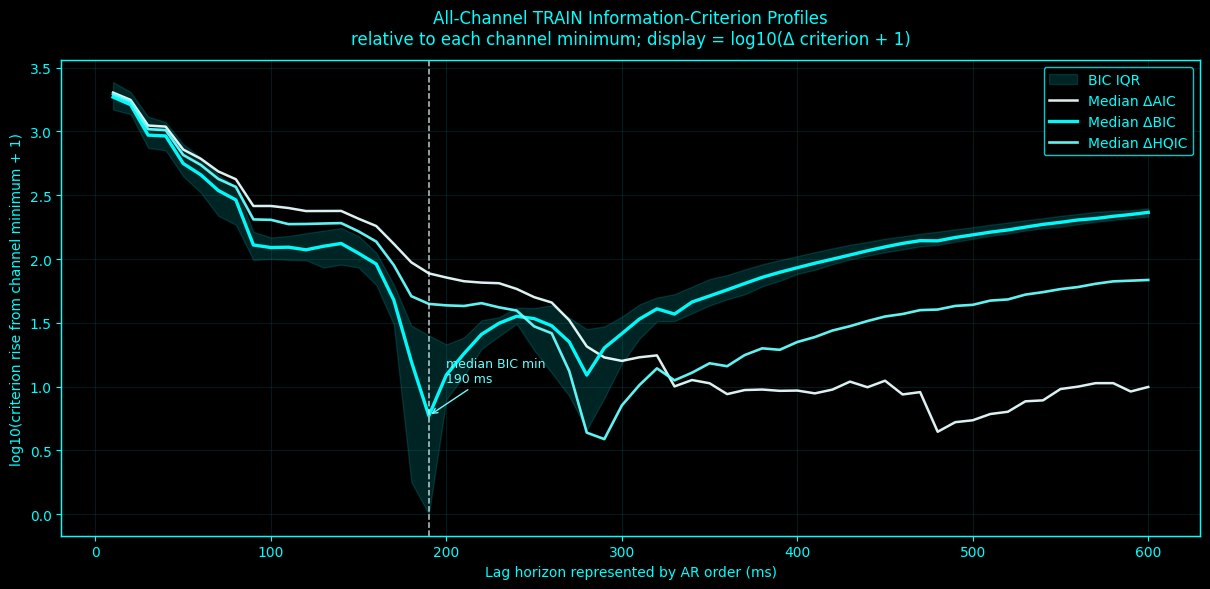

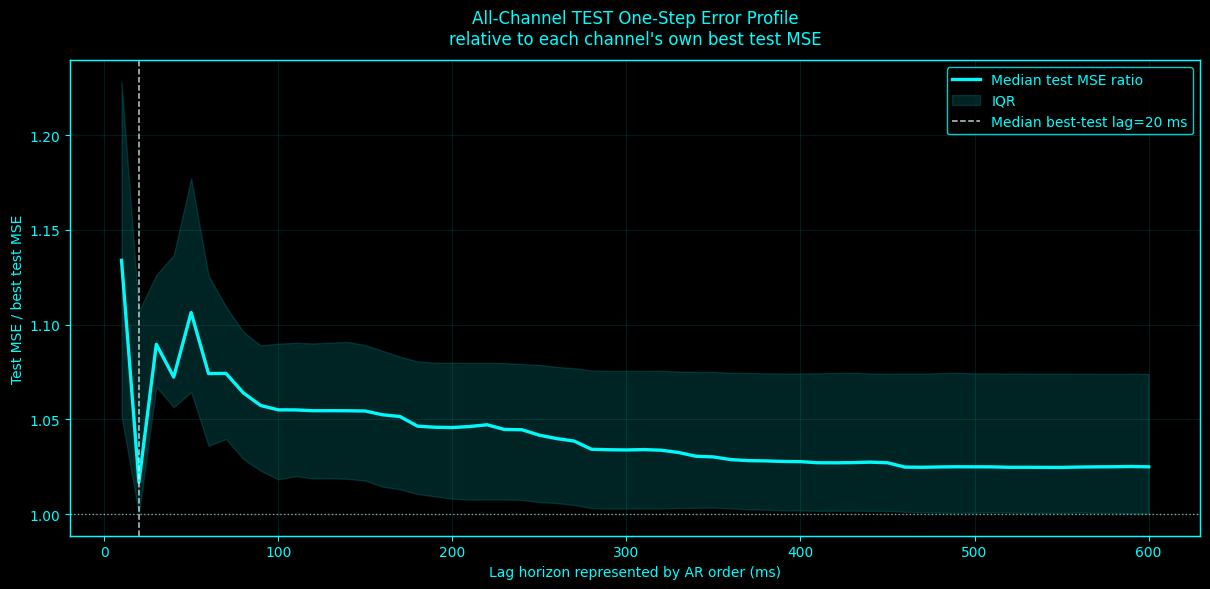

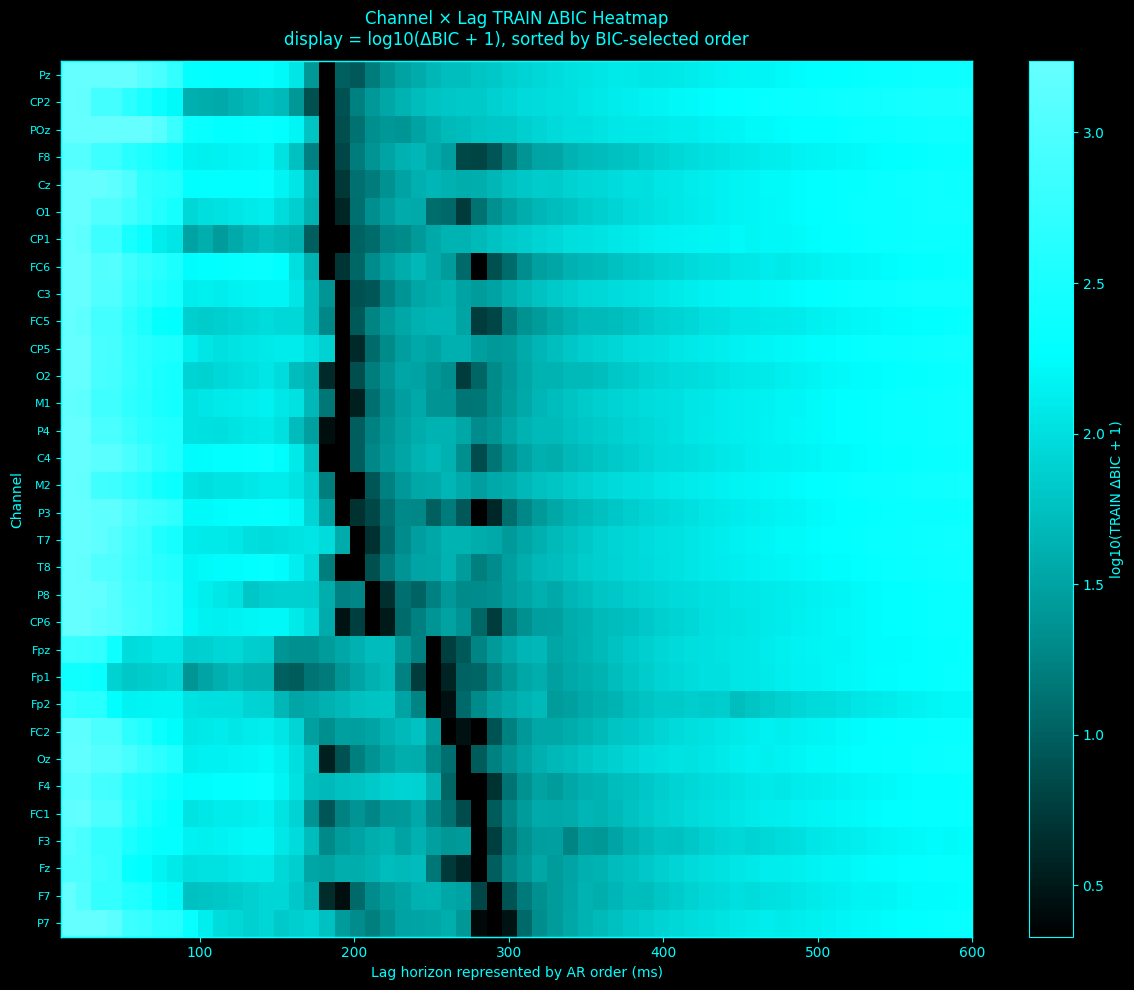

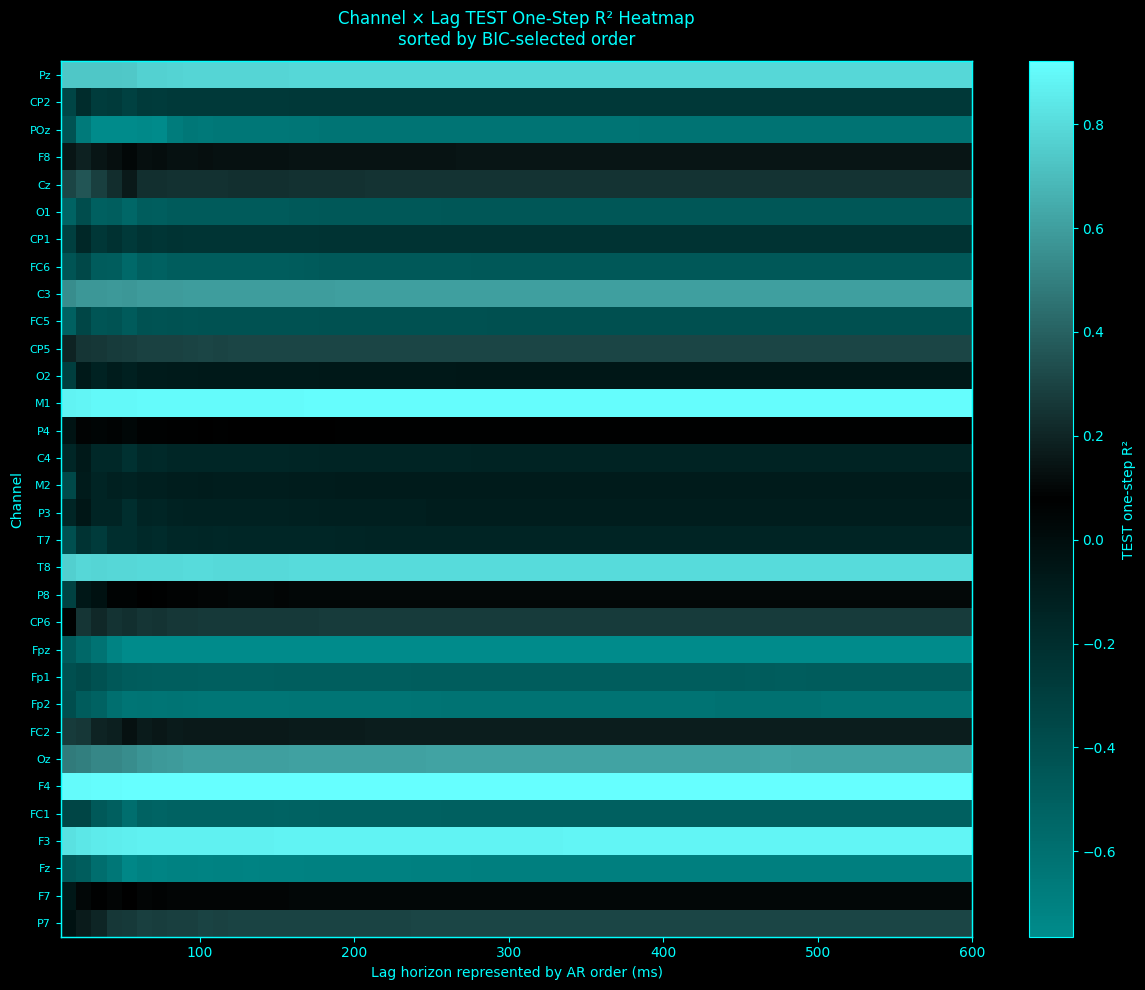

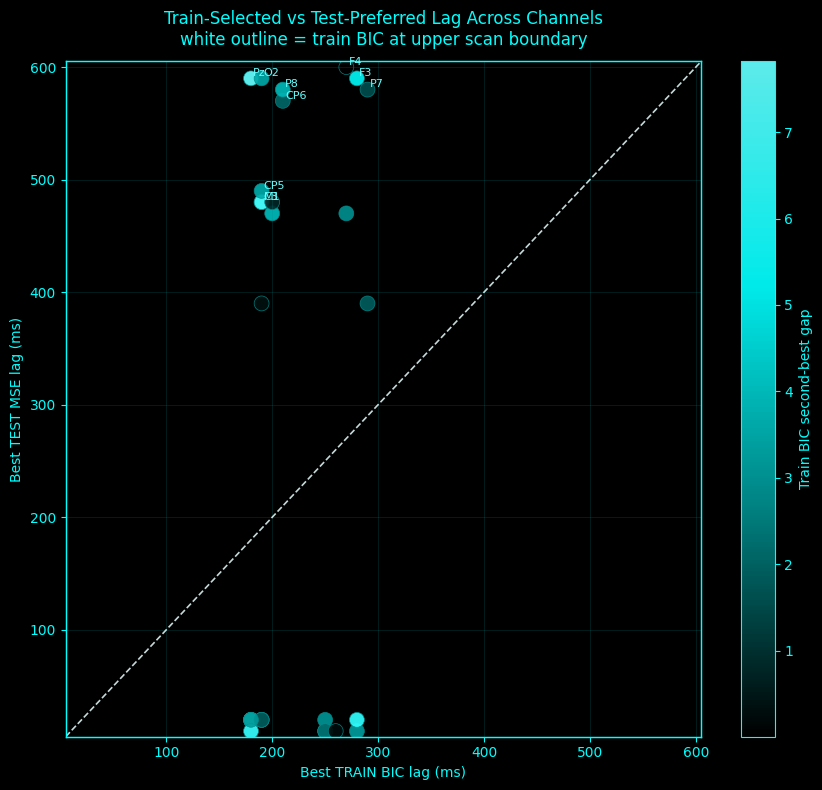

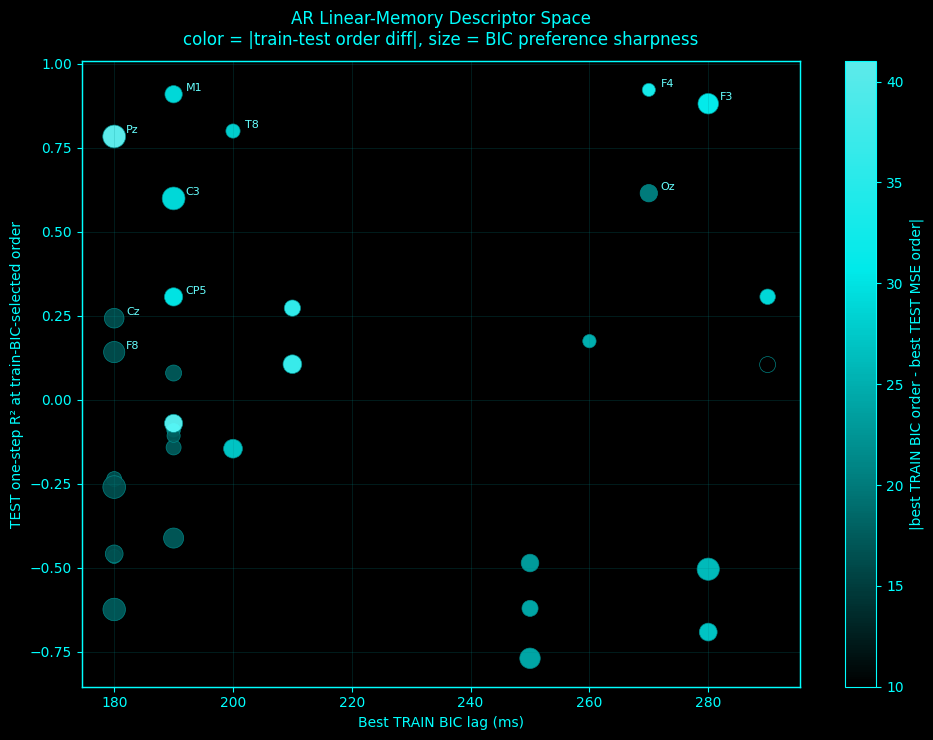

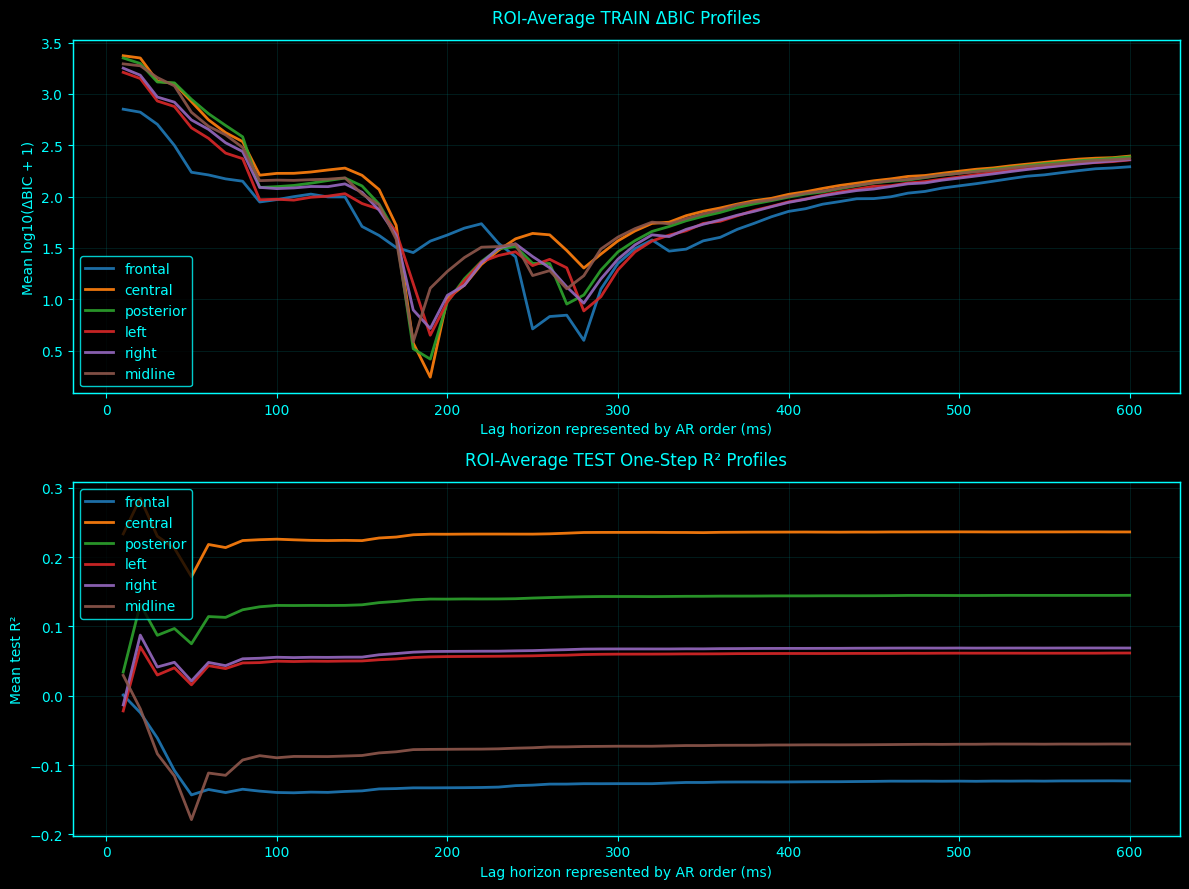

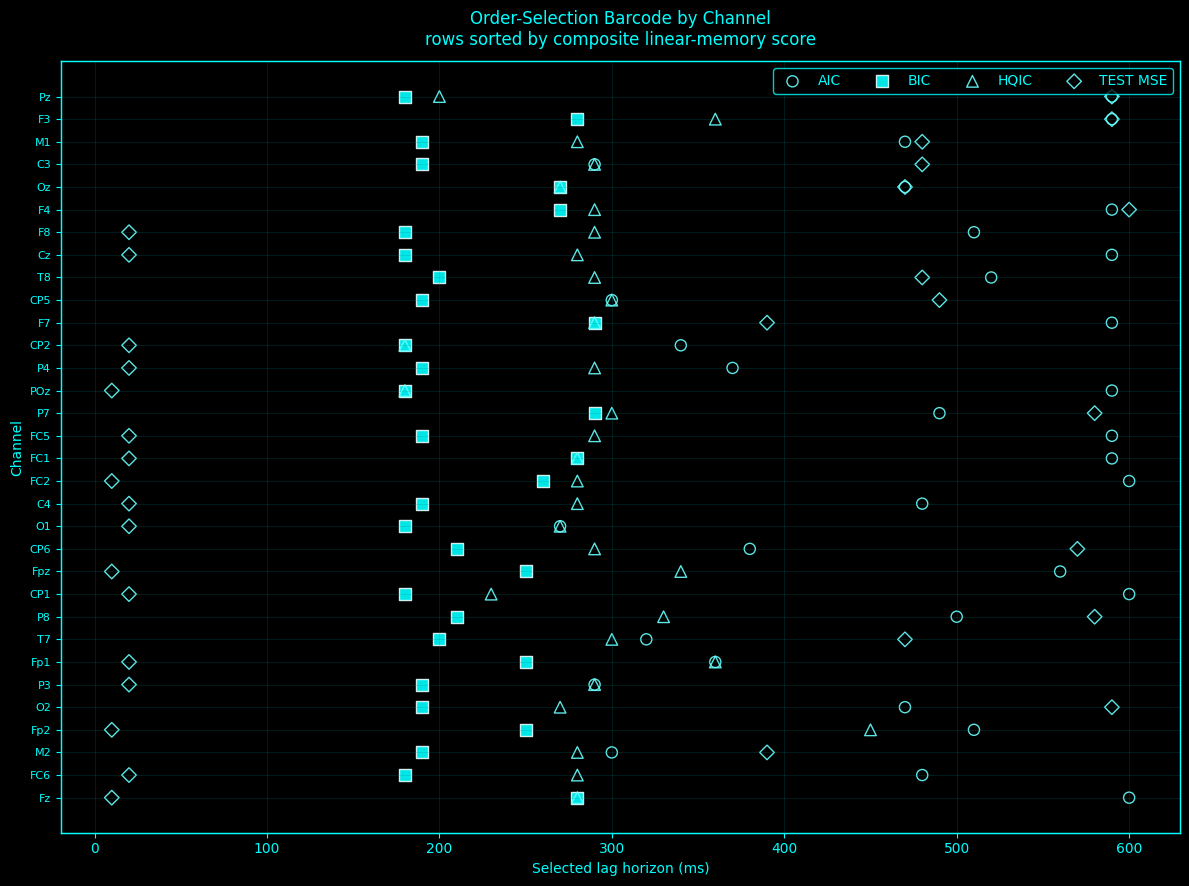

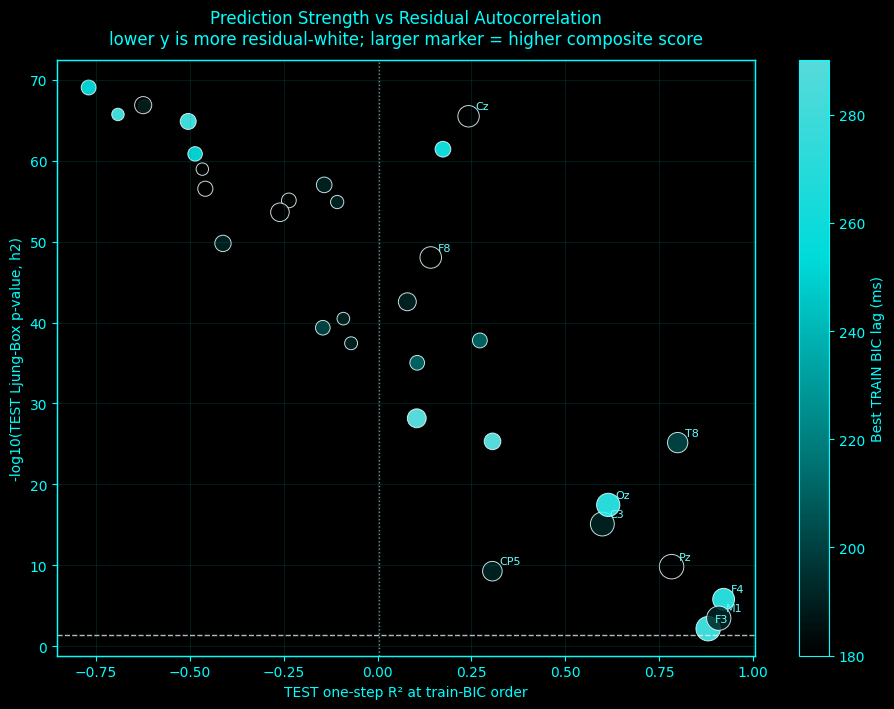

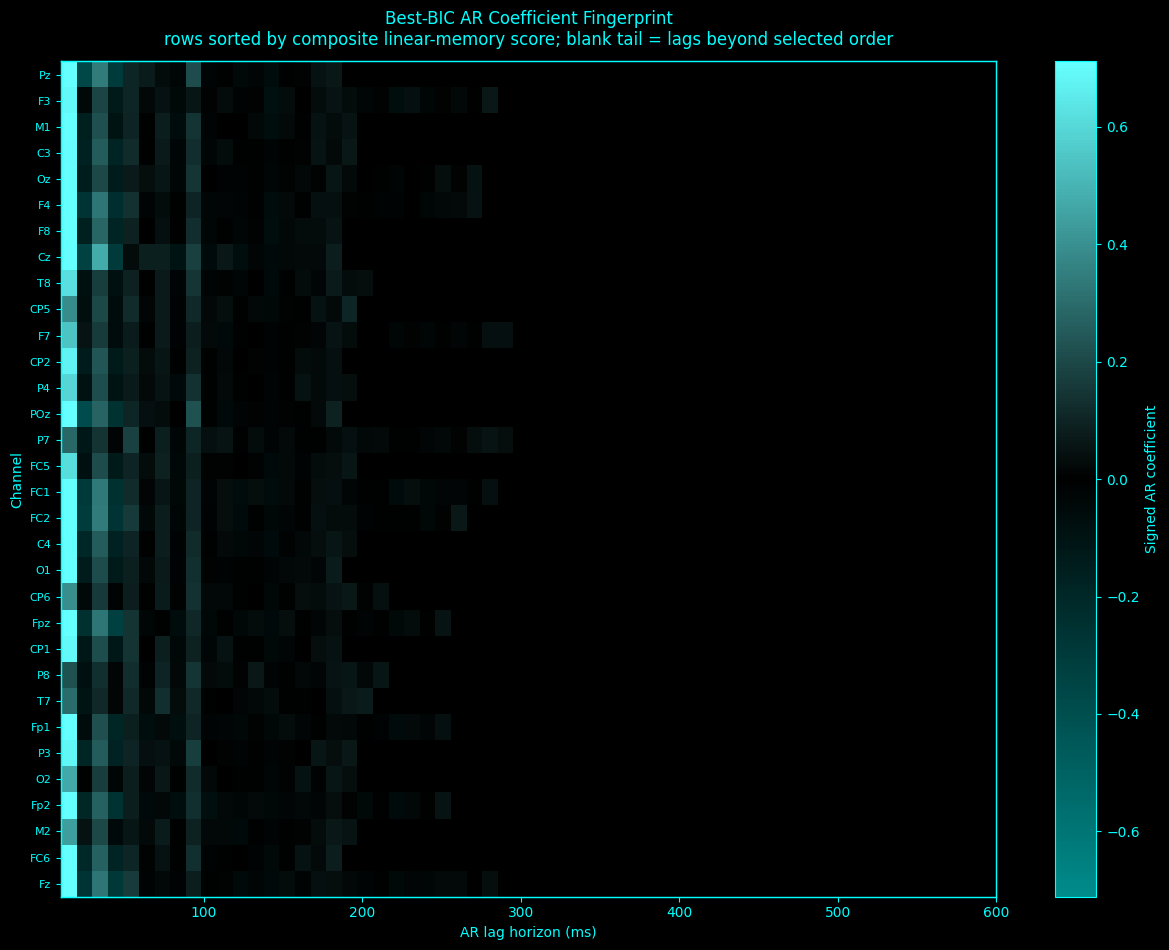

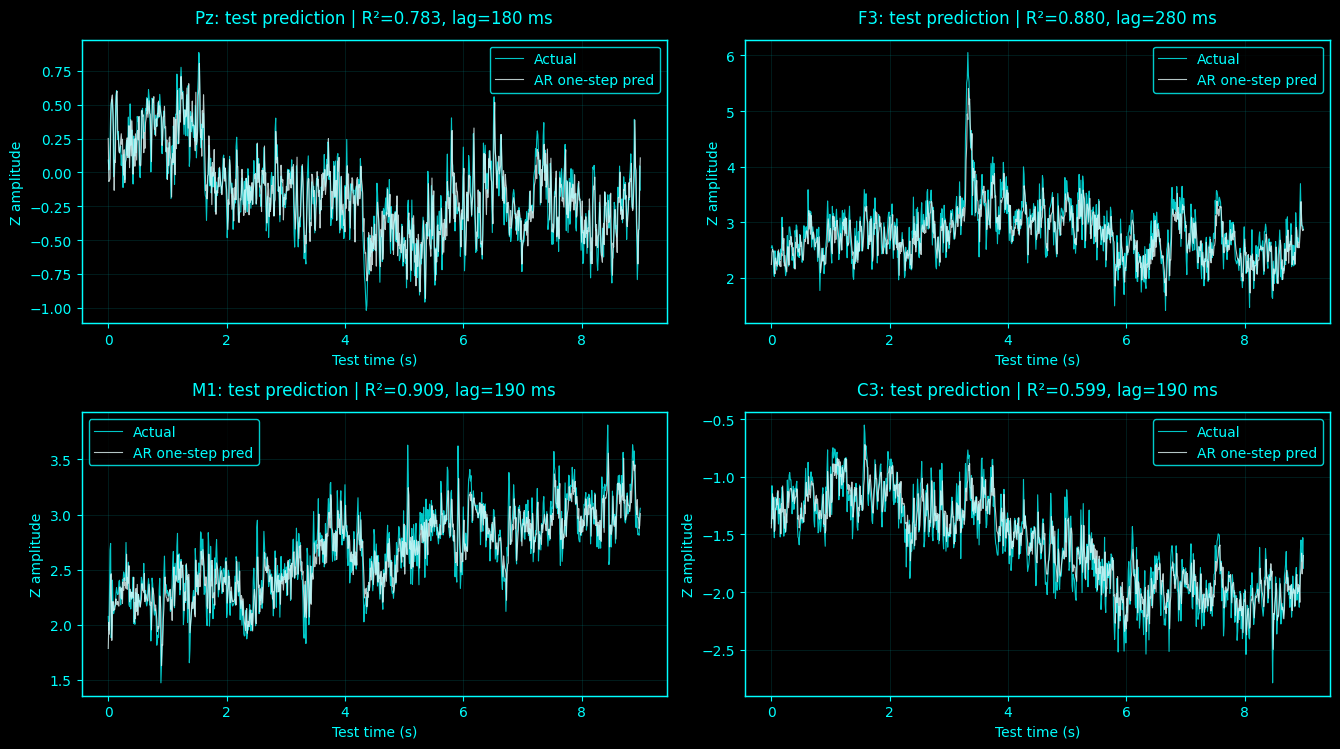

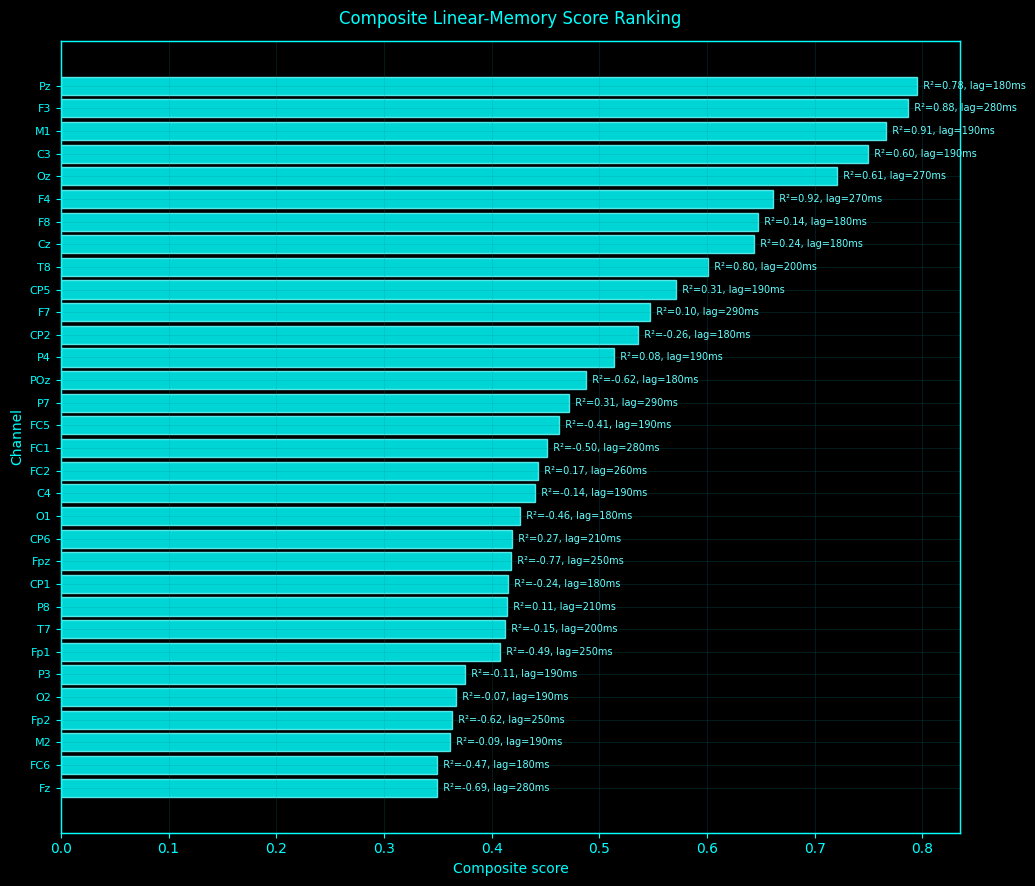

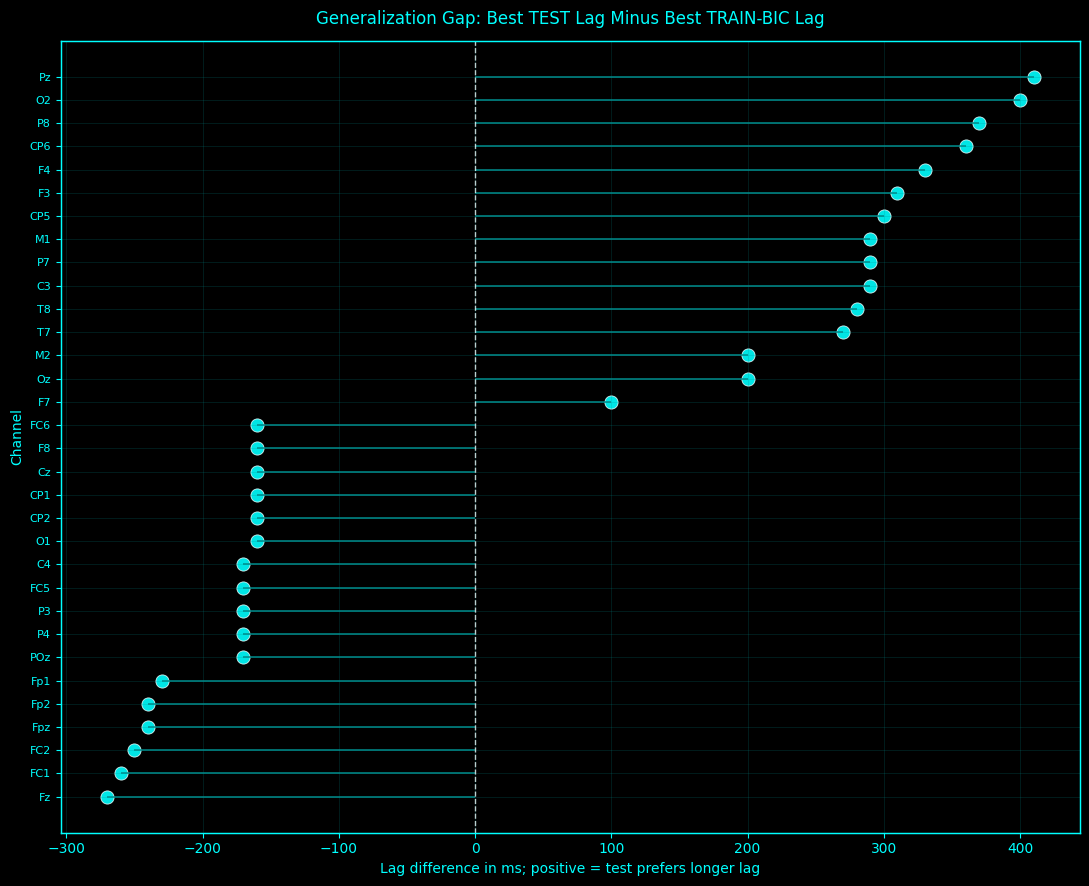

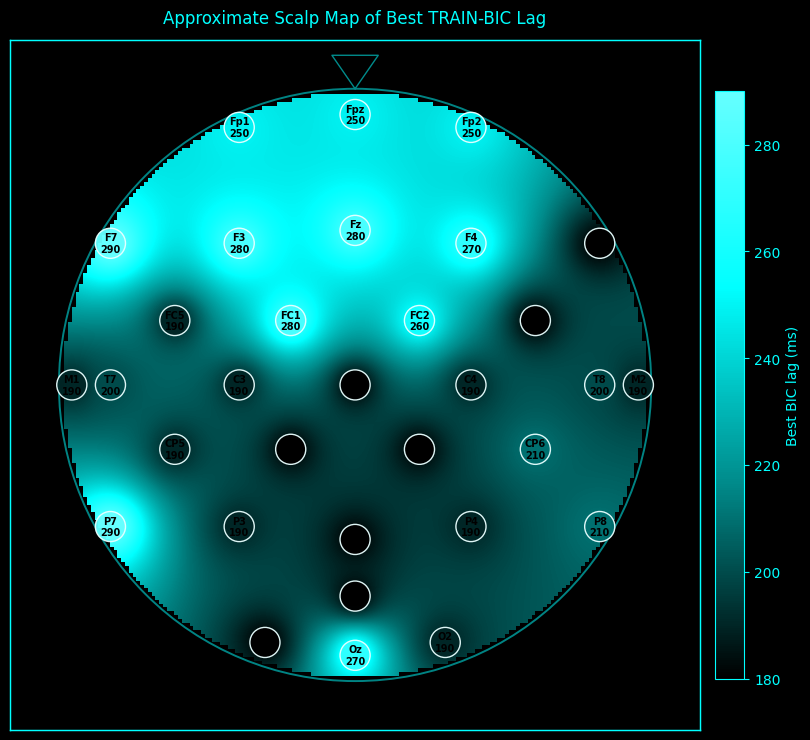

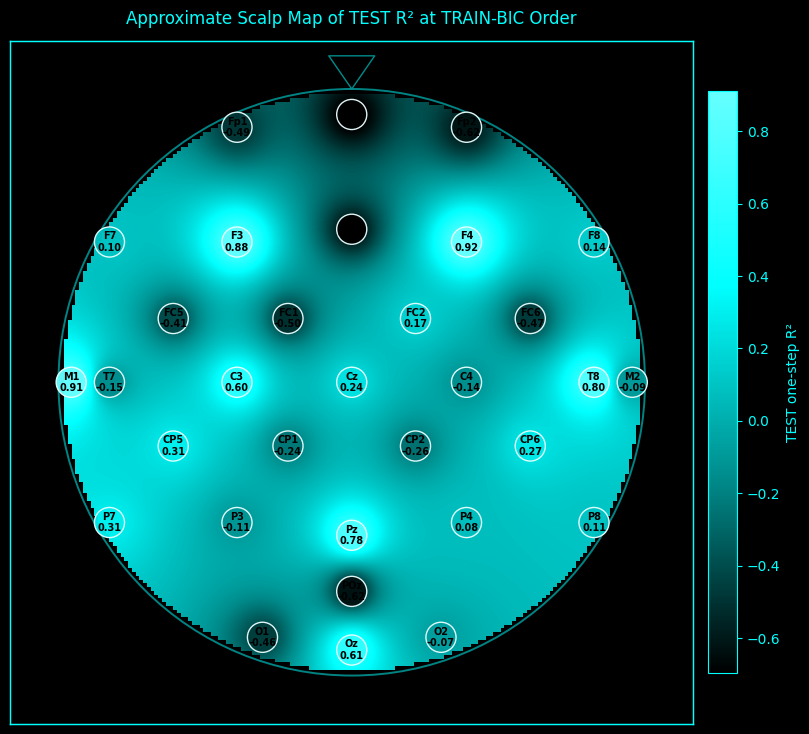

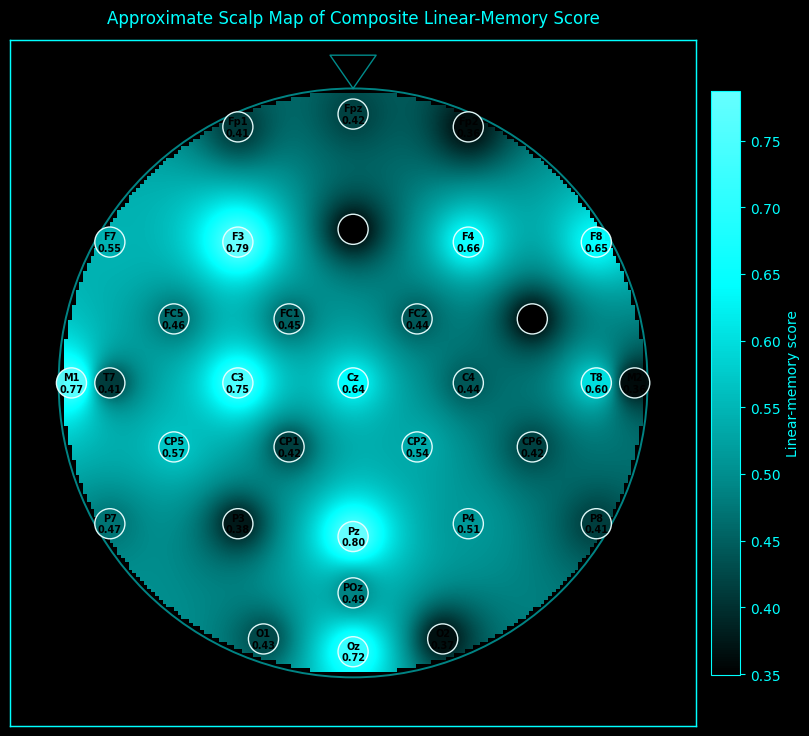


EXPERT EXPLORATORY AR TRAIN/TEST SCAN SUMMARY
FAST_OPTION: ultra
HAVE_SCIPY: True
Original segment shape: (106944, 32)
Downsampled AR segment shape: (10695, 32)
AR sampling rate: 100.0 Hz
Candidate orders: 1–60
Candidate lag horizon: 10.0–600.0 ms
Channels analyzed: 32
Channels with TRAIN BIC at upper boundary: 0 / 32
Channels with TEST MSE at upper boundary: 1 / 32
Mean TRAIN-BIC selected lag: 216.88 ms
Median TRAIN-BIC selected lag: 190.00 ms
Mean TEST-preferred lag: 251.25 ms
Median TEST-preferred lag: 20.00 ms
Mean TEST R² at TRAIN-BIC order: 0.0359
Median TEST R² at TRAIN-BIC order: 0.0043
Elapsed: 0.35 min

Top 15 channels by composite linear-memory score:
channel  linear_memory_score  best_bic_order_train  best_bic_lag_ms_train  best_test_mse_order  best_test_mse_lag_ms  best_bic_test_r2  bic_second_best_gap_train  bic_vs_test_order_abs_diff  best_bic_test_resid_ljungbox_p_h2 hemisphere           region
     Pz             0.795091                    18                  180.0  

In [1]:
import os
import time
import math
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

try:
    from scipy import signal as scipy_signal
    from scipy.stats import chi2 as scipy_chi2
    HAVE_SCIPY = True
except Exception:
    scipy_signal = None
    scipy_chi2 = None
    HAVE_SCIPY = False


base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

FAST_OPTION = "ultra"   # options: "ultra", "fast", "balanced", "full"

if FAST_OPTION == "ultra":
    ar_downsample_factor = 10
    max_order = 60
    train_fraction = 0.80
    apply_common_average_reference = False
    detrend_mode = "constant"
    zscore_each_channel = True
    include_intercept = False
    test_lb_h1_min = 16
    test_lb_h2_min = 32
    show_plots_in_notebook = True
    save_plots_to_disk = True
    dpi_save = 170
    prediction_example_top_n = 4
    prediction_plot_points = 900
    topographic_grid_n = 160
    zip_outputs = False

elif FAST_OPTION == "fast":
    ar_downsample_factor = 8
    max_order = 75
    train_fraction = 0.80
    apply_common_average_reference = False
    detrend_mode = "constant"
    zscore_each_channel = True
    include_intercept = False
    test_lb_h1_min = 20
    test_lb_h2_min = 40
    show_plots_in_notebook = True
    save_plots_to_disk = True
    dpi_save = 190
    prediction_example_top_n = 6
    prediction_plot_points = 1200
    topographic_grid_n = 190
    zip_outputs = True

elif FAST_OPTION == "balanced":
    ar_downsample_factor = 5
    max_order = 120
    train_fraction = 0.80
    apply_common_average_reference = False
    detrend_mode = "constant"
    zscore_each_channel = True
    include_intercept = False
    test_lb_h1_min = 20
    test_lb_h2_min = 40
    show_plots_in_notebook = True
    save_plots_to_disk = True
    dpi_save = 220
    prediction_example_top_n = 8
    prediction_plot_points = 1600
    topographic_grid_n = 220
    zip_outputs = True

elif FAST_OPTION == "full":
    ar_downsample_factor = 4
    max_order = 180
    train_fraction = 0.80
    apply_common_average_reference = False
    detrend_mode = "constant"
    zscore_each_channel = True
    include_intercept = False
    test_lb_h1_min = 30
    test_lb_h2_min = 60
    show_plots_in_notebook = True
    save_plots_to_disk = True
    dpi_save = 240
    prediction_example_top_n = 10
    prediction_plot_points = 2200
    topographic_grid_n = 260
    zip_outputs = True

else:
    raise ValueError("FAST_OPTION must be one of: 'ultra', 'fast', 'balanced', 'full'.")


out_dir = os.path.join(base_dir, "results", "exploratory_ar_train_test_scan_expert_fast")
plots_dir = os.path.join(out_dir, "plots")
expert_plots_dir = os.path.join(plots_dir, "expert")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)
os.makedirs(expert_plots_dir, exist_ok=True)


sampling_rate = 1000
start_time = 814.571
end_time = 921.515
start_index = int(start_time * sampling_rate)
end_index = int(end_time * sampling_rate)

fs_ar = sampling_rate / ar_downsample_factor
lag_orders = np.arange(1, max_order + 1)
lag_ms = 1000.0 * lag_orders / fs_ar
hold_back = int(np.max(lag_orders))

eeg_channel_names = [
    "Fp1", "Fpz", "Fp2", "F7", "F3", "Fz", "F4", "F8", "FC5", "FC1", "FC2", "FC6",
    "M1", "T7", "C3", "Cz", "C4", "T8", "M2", "CP5", "CP1", "CP2", "CP6",
    "P7", "P3", "Pz", "P4", "P8", "POz", "O1", "Oz", "O2"
]

left_channels = ["Fp1", "F7", "F3", "FC5", "FC1", "M1", "T7", "C3", "CP5", "CP1", "P7", "P3", "O1"]
right_channels = ["Fp2", "F8", "F4", "FC2", "FC6", "M2", "T8", "C4", "CP2", "CP6", "P8", "P4", "O2"]
midline_channels = ["Fpz", "Fz", "Cz", "Pz", "POz", "Oz"]

roi_definitions = {
    "frontal": ["Fp1", "Fpz", "Fp2", "F3", "Fz", "F4"],
    "central": ["C3", "Cz", "C4"],
    "posterior": ["P3", "Pz", "P4", "O1", "Oz", "O2"],
    "left": left_channels,
    "right": right_channels,
    "midline": midline_channels,
}

electrode_xy = {
    "Fp1": (-0.45, 1.00), "Fpz": (0.00, 1.05), "Fp2": (0.45, 1.00),
    "F7": (-0.95, 0.55), "F3": (-0.45, 0.55), "Fz": (0.00, 0.60), "F4": (0.45, 0.55), "F8": (0.95, 0.55),
    "FC5": (-0.70, 0.25), "FC1": (-0.25, 0.25), "FC2": (0.25, 0.25), "FC6": (0.70, 0.25),
    "M1": (-1.10, 0.00), "T7": (-0.95, 0.00), "C3": (-0.45, 0.00), "Cz": (0.00, 0.00), "C4": (0.45, 0.00), "T8": (0.95, 0.00), "M2": (1.10, 0.00),
    "CP5": (-0.70, -0.25), "CP1": (-0.25, -0.25), "CP2": (0.25, -0.25), "CP6": (0.70, -0.25),
    "P7": (-0.95, -0.55), "P3": (-0.45, -0.55), "Pz": (0.00, -0.60), "P4": (0.45, -0.55), "P8": (0.95, -0.55),
    "POz": (0.00, -0.82), "O1": (-0.35, -1.00), "Oz": (0.00, -1.05), "O2": (0.35, -1.00),
}

eps = 1e-12

ACCENT = "#00FFFF"
ACCENT_SOFT = "#66FFFF"
ACCENT_DIM = "#008B8B"
WHITE = "#E8FFFF"
BLACK = "#000000"

CYAN_SEQUENTIAL_CMAP = LinearSegmentedColormap.from_list(
    "cyan_sequential",
    [BLACK, ACCENT_DIM, ACCENT, ACCENT_SOFT],
    N=256,
)

CYAN_DIVERGING_CMAP = LinearSegmentedColormap.from_list(
    "cyan_diverging",
    [ACCENT_DIM, BLACK, ACCENT_SOFT],
    N=256,
)

plt.rcParams.update({
    "figure.facecolor": BLACK,
    "axes.facecolor": BLACK,
    "savefig.facecolor": BLACK,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT_DIM,
    "grid.alpha": 0.25,
    "legend.facecolor": BLACK,
    "legend.edgecolor": ACCENT,
    "legend.labelcolor": ACCENT,
    "font.size": 10,
})


def style_ax(ax, title=None, xlabel=None, ylabel=None, grid=True):
    ax.set_facecolor(BLACK)

    for spine in ax.spines.values():
        spine.set_color(ACCENT)
        spine.set_linewidth(1.05)

    ax.tick_params(axis="x", colors=ACCENT, labelcolor=ACCENT)
    ax.tick_params(axis="y", colors=ACCENT, labelcolor=ACCENT)

    if title is not None:
        ax.set_title(title, color=ACCENT, pad=12)

    if xlabel is not None:
        ax.set_xlabel(xlabel, color=ACCENT)

    if ylabel is not None:
        ax.set_ylabel(ylabel, color=ACCENT)

    if grid:
        ax.grid(True, alpha=0.22, color=ACCENT_DIM, linewidth=0.65)
    else:
        ax.grid(False)


def style_cbar(cbar, label):
    cbar.set_label(label, color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.ax.tick_params(color=ACCENT)

    for lab in cbar.ax.get_yticklabels():
        lab.set_color(ACCENT)


def save_fig(fig, path, show=True):
    fig.tight_layout()

    if save_plots_to_disk and path is not None:
        fig.savefig(path, dpi=dpi_save, bbox_inches="tight", facecolor=BLACK)

    if show_plots_in_notebook and show:
        plt.show()

    plt.close(fig)


def safe_numeric_array(x):
    x = np.asarray(x, dtype=float)
    return np.where(np.isfinite(x), x, np.nan)


def robust_minmax(x, lo=3, hi=97):
    x = safe_numeric_array(x)
    finite = x[np.isfinite(x)]

    if finite.size == 0:
        return np.zeros_like(x, dtype=float)

    a = np.nanpercentile(finite, lo)
    b = np.nanpercentile(finite, hi)

    if not np.isfinite(a) or not np.isfinite(b) or b <= a:
        return np.zeros_like(x, dtype=float)

    return np.clip((x - a) / (b - a + eps), 0, 1)


def robust_z(x):
    x = safe_numeric_array(x)
    finite = x[np.isfinite(x)]

    if finite.size == 0:
        return np.zeros_like(x, dtype=float)

    med = np.nanmedian(finite)
    q25 = np.nanpercentile(finite, 25)
    q75 = np.nanpercentile(finite, 75)
    iqr = q75 - q25

    if not np.isfinite(iqr) or iqr <= eps:
        return (x - med) / (np.nanstd(finite) + eps)

    return (x - med) / (iqr + eps)


def ensure_time_channel_layout(x, n_channels_expected):
    x = np.asarray(x, dtype=float)

    if x.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {x.shape}")

    if x.shape[1] == n_channels_expected:
        return x

    if x.shape[0] == n_channels_expected:
        return x.T

    if x.shape[1] > n_channels_expected:
        return x[:, :n_channels_expected]

    if x.shape[0] > n_channels_expected:
        return x.T[:, :n_channels_expected]

    raise ValueError(f"Unexpected EEG shape {x.shape}; cannot identify channel axis.")


def maybe_common_average_reference(x, enabled=False):
    if not enabled:
        return x

    return x - np.mean(x, axis=1, keepdims=True)


def downsample_segment_for_ar(segment, factor):
    if factor <= 1:
        return np.asarray(segment, dtype=float)

    if HAVE_SCIPY and scipy_signal is not None:
        return np.asarray(scipy_signal.resample_poly(segment, up=1, down=factor, axis=0), dtype=float)

    return np.asarray(segment[::factor, :], dtype=float)


def preprocess_train_referenced(y, train_end, detrend_mode="constant", zscore=True):
    y = np.asarray(y, dtype=float).copy()
    y = np.where(np.isfinite(y), y, np.nan)

    if np.any(~np.isfinite(y)):
        med = np.nanmedian(y[:train_end])
        if not np.isfinite(med):
            med = 0.0
        y = np.nan_to_num(y, nan=med, posinf=med, neginf=med)

    if detrend_mode == "constant":
        mu = np.mean(y[:train_end])
        y = y - mu

    elif detrend_mode == "linear":
        t_train = np.arange(train_end, dtype=float)
        coeff = np.polyfit(t_train, y[:train_end], deg=1)
        t_full = np.arange(len(y), dtype=float)
        y = y - (coeff[0] * t_full + coeff[1])

    elif detrend_mode is None:
        pass

    else:
        raise ValueError(f"Unsupported detrend_mode: {detrend_mode}")

    if zscore:
        sd = np.std(y[:train_end])
        y = y / (sd + eps)

    return y


def build_ar_design(y, p, start_idx, end_idx, include_intercept=False):
    y = np.asarray(y, dtype=float)

    if start_idx < p:
        raise ValueError("start_idx must be >= p")

    if end_idx <= start_idx:
        raise ValueError("end_idx must be > start_idx")

    t_idx = np.arange(start_idx, end_idx, dtype=int)
    cols = []

    if include_intercept:
        cols.append(np.ones(len(t_idx), dtype=float))

    for lag in range(1, p + 1):
        cols.append(y[t_idx - lag])

    X = np.column_stack(cols)
    target = y[t_idx]

    return X, target


def fit_ar_ols(y, p, train_end, hold_back, include_intercept=False):
    X_train, y_train = build_ar_design(
        y=y,
        p=p,
        start_idx=hold_back,
        end_idx=train_end,
        include_intercept=include_intercept,
    )

    beta, _, _, _ = np.linalg.lstsq(X_train, y_train, rcond=None)
    fitted_train = X_train @ beta
    resid_train = y_train - fitted_train

    n_eff = len(y_train)
    k = X_train.shape[1]
    sse = float(np.dot(resid_train, resid_train))
    sigma2_mle = sse / max(n_eff, 1)
    sigma2_unbiased = sse / max(n_eff - k, 1)

    aic = n_eff * np.log(sigma2_mle + eps) + 2.0 * k
    bic = n_eff * np.log(sigma2_mle + eps) + k * np.log(n_eff + eps)
    hqic = n_eff * np.log(sigma2_mle + eps) + 2.0 * k * np.log(np.log(n_eff + eps) + eps)

    if n_eff - k - 1 > 0:
        aicc = aic + (2.0 * k * (k + 1)) / (n_eff - k - 1)
    else:
        aicc = np.nan

    return {
        "beta": beta,
        "resid_train": resid_train,
        "fitted_train": fitted_train,
        "n_eff": n_eff,
        "k": k,
        "sse_train": sse,
        "sigma2_mle": sigma2_mle,
        "sigma2_unbiased": sigma2_unbiased,
        "aic": float(aic),
        "bic": float(bic),
        "hqic": float(hqic),
        "aicc": float(aicc),
    }


def predict_test_teacher_forced(y, beta, p, train_end, include_intercept=False):
    X_test, y_test = build_ar_design(
        y=y,
        p=p,
        start_idx=train_end,
        end_idx=len(y),
        include_intercept=include_intercept,
    )

    y_pred = X_test @ beta
    resid_test = y_test - y_pred

    mse = float(np.mean(resid_test ** 2))
    mae = float(np.mean(np.abs(resid_test)))
    rmse = float(np.sqrt(mse))

    var_ref = float(np.mean((y_test - np.mean(y_test)) ** 2))
    r2 = float(1.0 - mse / (var_ref + eps))

    if np.std(y_pred) > 0 and np.std(y_test) > 0:
        corr = float(np.corrcoef(y_test, y_pred)[0, 1])
    else:
        corr = np.nan

    return {
        "y_test": y_test,
        "y_pred": y_pred,
        "resid_test": resid_test,
        "mse": mse,
        "mae": mae,
        "rmse": rmse,
        "r2": r2,
        "corr": corr,
    }


def acf_fft(y, nlags):
    y = np.asarray(y, dtype=float)
    y = y[np.isfinite(y)]

    if len(y) <= 2:
        return np.full(nlags + 1, np.nan, dtype=float)

    y = y - np.mean(y)
    denom = np.dot(y, y)

    if not np.isfinite(denom) or denom <= 0:
        return np.full(nlags + 1, np.nan, dtype=float)

    n = len(y)
    nfft = 1 << ((2 * n - 1).bit_length())
    f = np.fft.rfft(y, n=nfft)
    corr = np.fft.irfft(f * np.conjugate(f), n=nfft)[:nlags + 1]

    return corr / (denom + eps)


def ljung_box_pvalue(resid, h, model_df=0):
    if scipy_chi2 is None:
        return np.nan

    resid = np.asarray(resid, dtype=float)
    resid = resid[np.isfinite(resid)]
    n = len(resid)
    h = int(h)

    if n <= h + 1 or h < 1:
        return np.nan

    rho = acf_fft(resid, h)[1:h + 1]

    if np.any(~np.isfinite(rho)):
        return np.nan

    k = np.arange(1, h + 1, dtype=float)
    q = n * (n + 2.0) * np.sum((rho ** 2) / (n - k))
    dof = h - int(model_df)

    if dof <= 0:
        return np.nan

    return float(scipy_chi2.sf(q, dof))


def safe_lb_h_train(best_order, resid_len, extra):
    h = max(int(best_order) + int(extra), int(best_order) + 5)
    h = min(h, max(1, resid_len // 3))

    if h <= int(best_order):
        return None

    return int(h)


def safe_lb_h_test(best_order, resid_len, base):
    h = max(int(base), int(best_order) // 2)
    h = min(h, max(1, resid_len // 3))

    if h < 1:
        return None

    return int(h)


def safe_nanargmin(x):
    x = np.asarray(x, dtype=float)

    if np.all(~np.isfinite(x)):
        return None

    return int(np.nanargmin(x))


def safe_nanmin_axis0(matrix):
    matrix = np.asarray(matrix, dtype=float)
    out = np.full((1, matrix.shape[1]), np.nan, dtype=float)

    for j in range(matrix.shape[1]):
        col = matrix[:, j]
        good = np.isfinite(col)

        if np.any(good):
            out[0, j] = np.nanmin(col)

    return out


def delta_from_min(matrix):
    matrix = np.asarray(matrix, dtype=float)
    mins = safe_nanmin_axis0(matrix)
    return matrix - mins


def second_best_gap(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]

    if len(x) < 2:
        return np.nan

    xs = np.sort(x)

    return float(xs[1] - xs[0])


def roi_average_matrix(matrix, channel_names, roi_channels):
    idx = [channel_names.index(ch) for ch in roi_channels if ch in channel_names]

    if len(idx) == 0:
        return np.full(matrix.shape[0], np.nan, dtype=float)

    return np.nanmean(matrix[:, idx], axis=1)


def percentile_limits(x, lo=2, hi=98, symmetric=False):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]

    if len(x) == 0:
        return None, None

    lo_v = float(np.percentile(x, lo))
    hi_v = float(np.percentile(x, hi))

    if symmetric:
        m = max(abs(lo_v), abs(hi_v), eps)
        return -m, m

    if hi_v <= lo_v:
        lo_v = float(np.min(x))
        hi_v = float(np.max(x))

        if hi_v <= lo_v:
            hi_v = lo_v + 1e-6

    return lo_v, hi_v


def log10p_display(x):
    x = np.asarray(x, dtype=float)
    out = np.full_like(x, np.nan, dtype=float)
    good = np.isfinite(x) & (x >= 0)
    out[good] = np.log10(x[good] + 1.0)

    return out


def normalize_sizes(x, smin=80.0, smax=260.0):
    x = np.asarray(x, dtype=float)
    out = np.full_like(x, (smin + smax) / 2.0, dtype=float)
    good = np.isfinite(x)

    if np.sum(good) < 2:
        return out

    lo = np.nanpercentile(x[good], 5)
    hi = np.nanpercentile(x[good], 95)
    span = max(hi - lo, eps)
    z = np.clip((x - lo) / span, 0, 1)
    out = smin + (smax - smin) * z
    out[~good] = (smin + smax) / 2.0

    return out


def add_channel_metadata(df):
    df = df.copy()
    hemispheres = []
    regions = []

    for ch in df["channel"]:
        if ch in left_channels:
            hemispheres.append("left")
        elif ch in right_channels:
            hemispheres.append("right")
        elif ch in midline_channels:
            hemispheres.append("midline")
        else:
            hemispheres.append("unknown")

        if ch.startswith("Fp"):
            regions.append("frontal_polar")
        elif ch.startswith("F") or ch.startswith("FC"):
            regions.append("frontal")
        elif ch.startswith("C") or ch.startswith("T") or ch.startswith("M"):
            regions.append("central_temporal")
        elif ch.startswith("CP") or ch.startswith("P"):
            regions.append("parietal")
        elif ch.startswith("PO") or ch.startswith("O"):
            regions.append("occipital")
        else:
            regions.append("unknown")

    df["hemisphere"] = hemispheres
    df["region"] = regions

    return df


def add_expert_scores(summary_df):
    df = summary_df.copy()

    r2_score = robust_minmax(df["best_bic_test_r2"].to_numpy(dtype=float))
    bic_gap_score = robust_minmax(np.log10(df["bic_second_best_gap_train"].to_numpy(dtype=float) + 1.0))
    ar_mass_score = robust_minmax(df["best_bic_ar_l2_mass"].to_numpy(dtype=float))
    agreement_score = robust_minmax(-df["bic_vs_test_order_abs_diff"].to_numpy(dtype=float))

    if "best_bic_test_resid_ljungbox_p_h2" in df.columns:
        pvals = df["best_bic_test_resid_ljungbox_p_h2"].to_numpy(dtype=float)
        whiteness_score = robust_minmax(np.log10(np.maximum(pvals, 1e-300)))
    else:
        whiteness_score = np.zeros(len(df), dtype=float)

    df["linear_memory_score"] = (
        0.35 * r2_score
        + 0.20 * bic_gap_score
        + 0.15 * ar_mass_score
        + 0.15 * agreement_score
        + 0.15 * whiteness_score
    )

    df["generalization_gap_order_ms"] = (
        df["best_test_mse_lag_ms"] - df["best_bic_lag_ms_train"]
    )

    df["neg_log10_test_ljungbox_p_h2"] = -np.log10(
        np.maximum(df.get("best_bic_test_resid_ljungbox_p_h2", pd.Series(np.nan, index=df.index)).to_numpy(dtype=float), 1e-300)
    )

    return df


def plot_ic_profiles(aic_display, bic_display, hqic_display, lag_ms, path):
    fig, ax = plt.subplots(figsize=(12.2, 6.0), facecolor=BLACK)

    med_aic = np.nanmedian(aic_display, axis=1)
    med_bic = np.nanmedian(bic_display, axis=1)
    med_hqic = np.nanmedian(hqic_display, axis=1)

    q25_bic = np.nanquantile(bic_display, 0.25, axis=1)
    q75_bic = np.nanquantile(bic_display, 0.75, axis=1)

    ax.fill_between(lag_ms, q25_bic, q75_bic, color=ACCENT, alpha=0.14, label="BIC IQR")
    ax.plot(lag_ms, med_aic, color=WHITE, linewidth=1.8, alpha=0.95, label="Median ΔAIC")
    ax.plot(lag_ms, med_bic, color=ACCENT, linewidth=2.4, alpha=0.98, label="Median ΔBIC")
    ax.plot(lag_ms, med_hqic, color=ACCENT_SOFT, linewidth=1.9, alpha=0.95, label="Median ΔHQIC")

    best_idx = int(np.nanargmin(med_bic)) if np.any(np.isfinite(med_bic)) else None

    if best_idx is not None:
        ax.axvline(lag_ms[best_idx], color=WHITE, linestyle="--", linewidth=1.1, alpha=0.8)
        ax.annotate(
            f"median BIC min\n{lag_ms[best_idx]:.0f} ms",
            xy=(lag_ms[best_idx], med_bic[best_idx]),
            xytext=(12, 24),
            textcoords="offset points",
            color=ACCENT_SOFT,
            fontsize=9,
            arrowprops=dict(arrowstyle="->", color=ACCENT_SOFT, lw=1.0),
        )

    style_ax(
        ax,
        title=(
            "All-Channel TRAIN Information-Criterion Profiles\n"
            "relative to each channel minimum; display = log10(Δ criterion + 1)"
        ),
        xlabel="Lag horizon represented by AR order (ms)",
        ylabel="log10(criterion rise from channel minimum + 1)",
    )

    leg = ax.legend(loc="best", frameon=True)

    for text in leg.get_texts():
        text.set_color(ACCENT)

    save_fig(fig, path)

    return path


def plot_test_mse_profile(test_mse_ratio, lag_ms, summary_df, path):
    fig, ax = plt.subplots(figsize=(12.2, 6.0), facecolor=BLACK)

    med_test = np.nanmedian(test_mse_ratio, axis=1)
    q25_test = np.nanquantile(test_mse_ratio, 0.25, axis=1)
    q75_test = np.nanquantile(test_mse_ratio, 0.75, axis=1)

    ax.plot(lag_ms, med_test, color=ACCENT, linewidth=2.4, alpha=0.98, label="Median test MSE ratio")
    ax.fill_between(lag_ms, q25_test, q75_test, color=ACCENT, alpha=0.14, label="IQR")
    ax.axhline(1.0, color=WHITE, linestyle=":", linewidth=1.0, alpha=0.6)

    if "best_test_mse_lag_ms" in summary_df.columns:
        med_best_test_ms = np.nanmedian(summary_df["best_test_mse_lag_ms"].to_numpy(dtype=float))
        ax.axvline(med_best_test_ms, color=WHITE, linestyle="--", linewidth=1.1, alpha=0.8, label=f"Median best-test lag={med_best_test_ms:.0f} ms")

    style_ax(
        ax,
        title=(
            "All-Channel TEST One-Step Error Profile\n"
            "relative to each channel's own best test MSE"
        ),
        xlabel="Lag horizon represented by AR order (ms)",
        ylabel="Test MSE / best test MSE",
    )

    leg = ax.legend(loc="best", frameon=True)

    for text in leg.get_texts():
        text.set_color(ACCENT)

    save_fig(fig, path)

    return path


def plot_train_bic_heatmap(bic_display, sorted_idx, sorted_channels, lag_ms, path):
    heat = bic_display[:, sorted_idx].T
    vmin, vmax = percentile_limits(heat, lo=2, hi=98)

    fig, ax = plt.subplots(figsize=(12.2, 10.0), facecolor=BLACK)

    im = ax.imshow(
        heat,
        aspect="auto",
        interpolation="nearest",
        cmap=CYAN_SEQUENTIAL_CMAP,
        vmin=vmin,
        vmax=vmax,
        extent=[lag_ms[0], lag_ms[-1], len(sorted_channels), 0],
    )

    ax.set_yticks(np.arange(len(sorted_channels)) + 0.5)
    ax.set_yticklabels(sorted_channels, fontsize=8, color=ACCENT)

    style_ax(
        ax,
        title=(
            "Channel × Lag TRAIN ΔBIC Heatmap\n"
            "display = log10(ΔBIC + 1), sorted by BIC-selected order"
        ),
        xlabel="Lag horizon represented by AR order (ms)",
        ylabel="Channel",
        grid=False,
    )

    cbar = plt.colorbar(im, ax=ax)
    style_cbar(cbar, "log10(TRAIN ΔBIC + 1)")

    save_fig(fig, path)

    return path


def plot_test_r2_heatmap(test_r2_matrix, sorted_idx, sorted_channels, lag_ms, path):
    heat = test_r2_matrix[:, sorted_idx].T
    vmin, vmax = percentile_limits(heat, lo=2, hi=98)

    fig, ax = plt.subplots(figsize=(12.2, 10.0), facecolor=BLACK)

    im = ax.imshow(
        heat,
        aspect="auto",
        interpolation="nearest",
        cmap=CYAN_DIVERGING_CMAP,
        vmin=vmin,
        vmax=vmax,
        extent=[lag_ms[0], lag_ms[-1], len(sorted_channels), 0],
    )

    ax.set_yticks(np.arange(len(sorted_channels)) + 0.5)
    ax.set_yticklabels(sorted_channels, fontsize=8, color=ACCENT)

    style_ax(
        ax,
        title="Channel × Lag TEST One-Step R² Heatmap\nsorted by BIC-selected order",
        xlabel="Lag horizon represented by AR order (ms)",
        ylabel="Channel",
        grid=False,
    )

    cbar = plt.colorbar(im, ax=ax)
    style_cbar(cbar, "TEST one-step R²")

    save_fig(fig, path)

    return path


def plot_train_vs_test_lag(summary_df, path):
    fig, ax = plt.subplots(figsize=(8.8, 8.0), facecolor=BLACK)

    x = summary_df["best_bic_lag_ms_train"].to_numpy(dtype=float)
    y = summary_df["best_test_mse_lag_ms"].to_numpy(dtype=float)
    c = summary_df["bic_second_best_gap_train"].to_numpy(dtype=float)
    boundary_mask = summary_df["best_bic_hits_upper_boundary_train"].fillna(False).to_numpy(dtype=bool)

    scatter = ax.scatter(
        x,
        y,
        c=c,
        s=115,
        alpha=0.92,
        cmap=CYAN_SEQUENTIAL_CMAP,
        edgecolors=np.where(boundary_mask, WHITE, ACCENT_DIM),
        linewidths=np.where(boundary_mask, 1.4, 0.5),
    )

    valid = np.isfinite(x) & np.isfinite(y)

    if np.any(valid):
        lo = min(np.nanmin(x[valid]), np.nanmin(y[valid])) - 5.0
        hi = max(np.nanmax(x[valid]), np.nanmax(y[valid])) + 5.0
    else:
        lo, hi = lag_ms[0], lag_ms[-1]

    ax.plot([lo, hi], [lo, hi], color=WHITE, linestyle="--", linewidth=1.2, alpha=0.85)

    annotate_df = summary_df.sort_values("bic_vs_test_order_abs_diff", ascending=False, na_position="last").head(10)

    for _, row in annotate_df.iterrows():
        if np.isfinite(row["best_bic_lag_ms_train"]) and np.isfinite(row["best_test_mse_lag_ms"]):
            ax.text(
                row["best_bic_lag_ms_train"] + 2.0,
                row["best_test_mse_lag_ms"] + 2.0,
                row["channel"],
                color=ACCENT_SOFT,
                fontsize=8,
            )

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)

    style_ax(
        ax,
        title=(
            "Train-Selected vs Test-Preferred Lag Across Channels\n"
            "white outline = train BIC at upper scan boundary"
        ),
        xlabel="Best TRAIN BIC lag (ms)",
        ylabel="Best TEST MSE lag (ms)",
    )

    cbar = plt.colorbar(scatter, ax=ax)
    style_cbar(cbar, "Train BIC second-best gap")

    save_fig(fig, path)

    return path


def plot_ar_descriptor_space(summary_df, path):
    fig, ax = plt.subplots(figsize=(10.0, 7.5), facecolor=BLACK)

    sizes = normalize_sizes(summary_df["bic_second_best_gap_train"].to_numpy(dtype=float), smin=90, smax=270)
    boundary_mask = summary_df["best_bic_hits_upper_boundary_train"].fillna(False).to_numpy(dtype=bool)

    scatter = ax.scatter(
        summary_df["best_bic_lag_ms_train"].to_numpy(dtype=float),
        summary_df["best_bic_test_r2"].to_numpy(dtype=float),
        c=summary_df["bic_vs_test_order_abs_diff"].to_numpy(dtype=float),
        s=sizes,
        alpha=0.92,
        cmap=CYAN_SEQUENTIAL_CMAP,
        edgecolors=np.where(boundary_mask, WHITE, ACCENT_DIM),
        linewidths=np.where(boundary_mask, 1.3, 0.5),
    )

    annotate_df = summary_df.sort_values("linear_memory_score", ascending=False, na_position="last").head(10)

    for _, row in annotate_df.iterrows():
        if np.isfinite(row["best_bic_lag_ms_train"]) and np.isfinite(row["best_bic_test_r2"]):
            ax.text(
                row["best_bic_lag_ms_train"] + 2.0,
                row["best_bic_test_r2"] + 0.01,
                row["channel"],
                color=ACCENT_SOFT,
                fontsize=8,
            )

    style_ax(
        ax,
        title=(
            "AR Linear-Memory Descriptor Space\n"
            "color = |train-test order diff|, size = BIC preference sharpness"
        ),
        xlabel="Best TRAIN BIC lag (ms)",
        ylabel="TEST one-step R² at train-BIC-selected order",
    )

    cbar = plt.colorbar(scatter, ax=ax)
    style_cbar(cbar, "|best TRAIN BIC order - best TEST MSE order|")

    save_fig(fig, path)

    return path


def plot_roi_profiles(bic_display, test_r2_matrix, lag_ms, path):
    fig, axes = plt.subplots(2, 1, figsize=(12.0, 9.0), facecolor=BLACK)

    ax = axes[0]

    for roi_name, roi_channels in roi_definitions.items():
        profile = roi_average_matrix(bic_display, eeg_channel_names, roi_channels)

        if np.any(np.isfinite(profile)):
            ax.plot(lag_ms, profile, linewidth=2.0, alpha=0.92, label=roi_name)

    style_ax(
        ax,
        title="ROI-Average TRAIN ΔBIC Profiles",
        xlabel="Lag horizon represented by AR order (ms)",
        ylabel="Mean log10(ΔBIC + 1)",
    )

    leg = ax.legend(loc="best", frameon=True)

    for text in leg.get_texts():
        text.set_color(ACCENT)

    ax = axes[1]

    for roi_name, roi_channels in roi_definitions.items():
        profile = roi_average_matrix(test_r2_matrix, eeg_channel_names, roi_channels)

        if np.any(np.isfinite(profile)):
            ax.plot(lag_ms, profile, linewidth=2.0, alpha=0.92, label=roi_name)

    style_ax(
        ax,
        title="ROI-Average TEST One-Step R² Profiles",
        xlabel="Lag horizon represented by AR order (ms)",
        ylabel="Mean test R²",
    )

    leg = ax.legend(loc="best", frameon=True)

    for text in leg.get_texts():
        text.set_color(ACCENT)

    save_fig(fig, path)

    return path


def plot_order_selection_barcode(summary_df, path):
    df = summary_df.copy()
    df = df.sort_values("linear_memory_score", ascending=False, na_position="last").reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(12.0, max(7.0, 0.28 * len(df))), facecolor=BLACK)

    y = np.arange(len(df))

    marker_specs = [
        ("best_aic_lag_ms_train", "AIC", "o", 64),
        ("best_bic_lag_ms_train", "BIC", "s", 66),
        ("best_hqic_lag_ms_train", "HQIC", "^", 70),
        ("best_test_mse_lag_ms", "TEST MSE", "D", 55),
    ]

    for col, label, marker, size in marker_specs:
        if col not in df.columns:
            continue

        ax.scatter(
            df[col],
            y,
            s=size,
            marker=marker,
            facecolors="none" if label != "BIC" else ACCENT,
            edgecolors=ACCENT_SOFT if label != "BIC" else WHITE,
            linewidths=1.0,
            alpha=0.90,
            label=label,
        )

    ax.set_yticks(y)
    ax.set_yticklabels(df["channel"], color=ACCENT, fontsize=8)
    ax.invert_yaxis()

    style_ax(
        ax,
        title=(
            "Order-Selection Barcode by Channel\n"
            "rows sorted by composite linear-memory score"
        ),
        xlabel="Selected lag horizon (ms)",
        ylabel="Channel",
    )

    leg = ax.legend(loc="best", frameon=True, ncol=4)

    for text in leg.get_texts():
        text.set_color(ACCENT)

    save_fig(fig, path)

    return path


def plot_residual_whiteness_quality(summary_df, path):
    df = summary_df.copy()
    df = df[
        np.isfinite(df["best_bic_test_r2"])
        & np.isfinite(df["neg_log10_test_ljungbox_p_h2"])
    ].copy()

    if df.empty:
        return None

    fig, ax = plt.subplots(figsize=(9.5, 7.2), facecolor=BLACK)

    sizes = normalize_sizes(df["linear_memory_score"].to_numpy(dtype=float), smin=80, smax=310)

    scatter = ax.scatter(
        df["best_bic_test_r2"],
        df["neg_log10_test_ljungbox_p_h2"],
        c=df["best_bic_lag_ms_train"],
        s=sizes,
        cmap=CYAN_SEQUENTIAL_CMAP,
        edgecolors=WHITE,
        linewidths=0.7,
        alpha=0.86,
    )

    ax.axhline(-np.log10(0.05), color=WHITE, linestyle="--", linewidth=1.0, alpha=0.75)
    ax.axvline(np.nanmedian(df["best_bic_test_r2"]), color=WHITE, linestyle=":", linewidth=1.0, alpha=0.55)

    top = df.sort_values("linear_memory_score", ascending=False).head(10)

    for _, row in top.iterrows():
        ax.annotate(
            row["channel"],
            (row["best_bic_test_r2"], row["neg_log10_test_ljungbox_p_h2"]),
            xytext=(5, 5),
            textcoords="offset points",
            color=ACCENT_SOFT,
            fontsize=8,
        )

    style_ax(
        ax,
        title=(
            "Prediction Strength vs Residual Autocorrelation\n"
            "lower y is more residual-white; larger marker = higher composite score"
        ),
        xlabel="TEST one-step R² at train-BIC order",
        ylabel="-log10(TEST Ljung-Box p-value, h2)",
    )

    cbar = plt.colorbar(scatter, ax=ax)
    style_cbar(cbar, "Best TRAIN BIC lag (ms)")

    save_fig(fig, path)

    return path


def plot_ar_coefficient_heatmap(beta_matrix, summary_df, path):
    df = summary_df.sort_values("linear_memory_score", ascending=False, na_position="last").reset_index(drop=True)
    ordered_channels = list(df["channel"].values)
    idx = [eeg_channel_names.index(ch) for ch in ordered_channels]

    heat = beta_matrix[:, idx].T

    vmin, vmax = percentile_limits(heat, lo=2, hi=98, symmetric=True)

    fig, ax = plt.subplots(figsize=(12.5, max(7.0, 0.30 * len(ordered_channels))), facecolor=BLACK)

    im = ax.imshow(
        heat,
        aspect="auto",
        interpolation="nearest",
        cmap=CYAN_DIVERGING_CMAP,
        vmin=vmin,
        vmax=vmax,
        extent=[lag_ms[0], lag_ms[-1], len(ordered_channels), 0],
    )

    ax.set_yticks(np.arange(len(ordered_channels)) + 0.5)
    ax.set_yticklabels(ordered_channels, color=ACCENT, fontsize=8)

    style_ax(
        ax,
        title=(
            "Best-BIC AR Coefficient Fingerprint\n"
            "rows sorted by composite linear-memory score; blank tail = lags beyond selected order"
        ),
        xlabel="AR lag horizon (ms)",
        ylabel="Channel",
        grid=False,
    )

    cbar = plt.colorbar(im, ax=ax)
    style_cbar(cbar, "Signed AR coefficient")

    save_fig(fig, path)

    return path


def plot_prediction_examples(prediction_store, summary_df, path):
    df = summary_df.sort_values("linear_memory_score", ascending=False, na_position="last")
    channels = [ch for ch in df["channel"].head(prediction_example_top_n).tolist() if ch in prediction_store]

    if len(channels) == 0:
        return None

    n = len(channels)
    ncols = 2
    nrows = int(math.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(13.5, 3.8 * nrows), facecolor=BLACK, squeeze=False)
    axes_flat = axes.ravel()

    for ax in axes_flat:
        ax.set_facecolor(BLACK)
        ax.axis("off")

    for ax, ch in zip(axes_flat, channels):
        ax.axis("on")
        item = prediction_store[ch]
        y_test = np.asarray(item["y_test"], dtype=float)
        y_pred = np.asarray(item["y_pred"], dtype=float)

        nplot = min(prediction_plot_points, len(y_test))
        t = np.arange(nplot) / fs_ar

        ax.plot(t, y_test[:nplot], color=ACCENT, linewidth=0.8, alpha=0.78, label="Actual")
        ax.plot(t, y_pred[:nplot], color=WHITE, linewidth=0.8, alpha=0.78, label="AR one-step pred")

        row = df[df["channel"] == ch].iloc[0]

        style_ax(
            ax,
            title=f"{ch}: test prediction | R²={row['best_bic_test_r2']:.3f}, lag={row['best_bic_lag_ms_train']:.0f} ms",
            xlabel="Test time (s)",
            ylabel="Z amplitude",
        )

        leg = ax.legend(loc="best", frameon=True)

        for text in leg.get_texts():
            text.set_color(ACCENT)

    save_fig(fig, path)

    return path


def plot_linear_memory_score_ranking(summary_df, path):
    df = summary_df.copy()
    df = df[np.isfinite(df["linear_memory_score"])].sort_values("linear_memory_score", ascending=True)

    if df.empty:
        return None

    fig, ax = plt.subplots(figsize=(10.5, max(7.0, 0.28 * len(df))), facecolor=BLACK)

    y = np.arange(len(df))

    ax.barh(
        y,
        df["linear_memory_score"],
        color=ACCENT,
        edgecolor=ACCENT_SOFT,
        alpha=0.84,
    )

    ax.set_yticks(y)
    ax.set_yticklabels(df["channel"], color=ACCENT, fontsize=8)

    for yi, (_, row) in zip(y, df.iterrows()):
        ax.text(
            row["linear_memory_score"],
            yi,
            f"  R²={row['best_bic_test_r2']:.2f}, lag={row['best_bic_lag_ms_train']:.0f}ms",
            va="center",
            ha="left",
            color=ACCENT_SOFT,
            fontsize=7,
        )

    style_ax(
        ax,
        title="Composite Linear-Memory Score Ranking",
        xlabel="Composite score",
        ylabel="Channel",
    )

    save_fig(fig, path)

    return path


def plot_generalization_gap_lollipop(summary_df, path):
    df = summary_df.copy()
    df = df[np.isfinite(df["generalization_gap_order_ms"])]
    df = df.sort_values("generalization_gap_order_ms", ascending=True)

    if df.empty:
        return None

    fig, ax = plt.subplots(figsize=(11.0, max(7.0, 0.28 * len(df))), facecolor=BLACK)

    y = np.arange(len(df))

    ax.hlines(
        y,
        0,
        df["generalization_gap_order_ms"],
        color=ACCENT_DIM,
        linewidth=1.3,
        alpha=0.85,
    )

    ax.scatter(
        df["generalization_gap_order_ms"],
        y,
        s=90,
        color=ACCENT,
        edgecolors=WHITE,
        linewidths=0.6,
        alpha=0.90,
    )

    ax.axvline(0, color=WHITE, linestyle="--", linewidth=1.0, alpha=0.80)

    ax.set_yticks(y)
    ax.set_yticklabels(df["channel"], color=ACCENT, fontsize=8)

    style_ax(
        ax,
        title="Generalization Gap: Best TEST Lag Minus Best TRAIN-BIC Lag",
        xlabel="Lag difference in ms; positive = test prefers longer lag",
        ylabel="Channel",
    )

    save_fig(fig, path)

    return path


def plot_metric_topography(summary_df, metric_col, title, color_label, path):
    df = summary_df.copy()
    df = df[np.isfinite(df[metric_col])]

    xs = []
    ys = []
    vals = []
    labels = []

    for _, row in df.iterrows():
        ch = row["channel"]

        if ch in electrode_xy:
            x, y = electrode_xy[ch]
            xs.append(x)
            ys.append(y)
            vals.append(float(row[metric_col]))
            labels.append(ch)

    if len(vals) == 0:
        return None

    xs = np.asarray(xs, dtype=float)
    ys = np.asarray(ys, dtype=float)
    vals = np.asarray(vals, dtype=float)

    gx = np.linspace(-1.18, 1.18, topographic_grid_n)
    gy = np.linspace(-1.18, 1.18, topographic_grid_n)
    GX, GY = np.meshgrid(gx, gy)
    mask = GX ** 2 + GY ** 2 <= 1.15 ** 2

    Z_num = np.zeros_like(GX, dtype=float)
    Z_den = np.zeros_like(GX, dtype=float)

    for x, y, v in zip(xs, ys, vals):
        d2 = (GX - x) ** 2 + (GY - y) ** 2
        w = 1.0 / (d2 + 0.025 ** 2)
        Z_num += w * v
        Z_den += w

    Z = Z_num / (Z_den + eps)
    Z[~mask] = np.nan

    fig, ax = plt.subplots(figsize=(8.2, 8.2), facecolor=BLACK)

    finite = vals[np.isfinite(vals)]
    vmin = np.nanpercentile(finite, 3) if finite.size else 0
    vmax = np.nanpercentile(finite, 97) if finite.size else 1

    im = ax.imshow(
        Z,
        extent=[gx.min(), gx.max(), gy.min(), gy.max()],
        origin="lower",
        cmap=CYAN_SEQUENTIAL_CMAP,
        vmin=vmin,
        vmax=vmax,
        interpolation="bilinear",
    )

    head = plt.Circle((0, 0), 1.15, color=ACCENT_DIM, fill=False, linewidth=1.4, alpha=0.95)
    ax.add_patch(head)

    ax.plot([0.0, -0.09, 0.09, 0.0], [1.15, 1.28, 1.28, 1.15], color=ACCENT_DIM, linewidth=1.0)

    ax.scatter(
        xs,
        ys,
        c=vals,
        s=470,
        cmap=CYAN_SEQUENTIAL_CMAP,
        vmin=vmin,
        vmax=vmax,
        edgecolors=WHITE,
        linewidths=1.0,
        alpha=0.96,
        zorder=4,
    )

    for x, y, ch, v in zip(xs, ys, labels, vals):
        if "lag" in metric_col or "ms" in metric_col:
            label = f"{ch}\n{v:.0f}"
        else:
            label = f"{ch}\n{v:.2f}"

        ax.text(
            x,
            y,
            label,
            ha="center",
            va="center",
            color=BLACK,
            fontsize=7,
            fontweight="bold",
            zorder=5,
        )

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(-1.34, 1.34)
    ax.set_ylim(-1.34, 1.34)
    ax.set_xticks([])
    ax.set_yticks([])

    style_ax(
        ax,
        title=title,
        xlabel="",
        ylabel="",
        grid=False,
    )

    cbar = fig.colorbar(im, ax=ax, fraction=0.040, pad=0.02)
    style_cbar(cbar, color_label)

    save_fig(fig, path)

    return path


start_all = time.perf_counter()

print("Running expert exploratory AR train/test order scan", flush=True)
print(f"FAST_OPTION: {FAST_OPTION}", flush=True)
print(f"HAVE_SCIPY: {HAVE_SCIPY}", flush=True)
print(f"EEG path: {eeg_path}", flush=True)

eeg_data = np.load(eeg_path, allow_pickle=True)
eeg_data = ensure_time_channel_layout(eeg_data, len(eeg_channel_names))

if end_index > eeg_data.shape[0]:
    raise ValueError(
        f"Requested end index {end_index} exceeds data length {eeg_data.shape[0]}. "
        "Check sampling rate or segment bounds."
    )

segment = eeg_data[start_index:end_index, :].copy()
segment = maybe_common_average_reference(segment, enabled=apply_common_average_reference)

segment_ds = downsample_segment_for_ar(segment, ar_downsample_factor)
segment_ds = np.asarray(segment_ds, dtype=float)

n_time = segment_ds.shape[0]
train_end = int(train_fraction * n_time)
train_end = max(train_end, hold_back + 1)
test_len = n_time - train_end

if test_len <= max_order:
    raise ValueError(
        f"Test segment too short after split: {test_len} samples. "
        "Reduce max_order or change train_fraction."
    )

print(f"Loaded EEG data: {eeg_data.shape[0]} samples x {eeg_data.shape[1]} channels")
print(f"Segment of interest: {start_time:.3f} to {end_time:.3f} sec")
print(f"Original segment shape: {segment.shape}")
print(f"Downsampled AR segment shape: {segment_ds.shape}")
print(f"AR comparison sampling rate: {fs_ar:.1f} Hz")
print(f"Train samples: {train_end}, Test samples: {test_len}")
print(f"Candidate lag orders: {lag_orders[0]}–{lag_orders[-1]} ({lag_ms[0]:.1f}–{lag_ms[-1]:.1f} ms)")
print(f"Shared training hold_back: {hold_back}")

n_orders = len(lag_orders)
n_channels = len(eeg_channel_names)

aic_matrix = np.full((n_orders, n_channels), np.nan, dtype=float)
bic_matrix = np.full((n_orders, n_channels), np.nan, dtype=float)
hqic_matrix = np.full((n_orders, n_channels), np.nan, dtype=float)
aicc_matrix = np.full((n_orders, n_channels), np.nan, dtype=float)
sigma2_matrix = np.full((n_orders, n_channels), np.nan, dtype=float)

test_mse_matrix = np.full((n_orders, n_channels), np.nan, dtype=float)
test_mae_matrix = np.full((n_orders, n_channels), np.nan, dtype=float)
test_rmse_matrix = np.full((n_orders, n_channels), np.nan, dtype=float)
test_r2_matrix = np.full((n_orders, n_channels), np.nan, dtype=float)
test_corr_matrix = np.full((n_orders, n_channels), np.nan, dtype=float)

best_bic_beta_matrix = np.full((max_order, n_channels), np.nan, dtype=float)
prediction_store = {}
summary_rows = []

for ch_i, ch_name in enumerate(eeg_channel_names):
    channel_start = time.perf_counter()

    y_raw = segment_ds[:, ch_i]
    y = preprocess_train_referenced(
        y_raw,
        train_end=train_end,
        detrend_mode=detrend_mode,
        zscore=zscore_each_channel,
    )

    fitted_models = {}

    for i, lag in enumerate(lag_orders):
        try:
            fit = fit_ar_ols(
                y=y,
                p=int(lag),
                train_end=train_end,
                hold_back=hold_back,
                include_intercept=include_intercept,
            )

            test_eval = predict_test_teacher_forced(
                y=y,
                beta=fit["beta"],
                p=int(lag),
                train_end=train_end,
                include_intercept=include_intercept,
            )

            aic_matrix[i, ch_i] = fit["aic"]
            bic_matrix[i, ch_i] = fit["bic"]
            hqic_matrix[i, ch_i] = fit["hqic"]
            aicc_matrix[i, ch_i] = fit["aicc"]
            sigma2_matrix[i, ch_i] = fit["sigma2_mle"]

            test_mse_matrix[i, ch_i] = test_eval["mse"]
            test_mae_matrix[i, ch_i] = test_eval["mae"]
            test_rmse_matrix[i, ch_i] = test_eval["rmse"]
            test_r2_matrix[i, ch_i] = test_eval["r2"]
            test_corr_matrix[i, ch_i] = test_eval["corr"]

            fitted_models[int(lag)] = {"fit": fit, "test": test_eval}

        except Exception:
            continue

    best_aic_idx = safe_nanargmin(aic_matrix[:, ch_i])
    best_bic_idx = safe_nanargmin(bic_matrix[:, ch_i])
    best_hqic_idx = safe_nanargmin(hqic_matrix[:, ch_i])
    best_test_idx = safe_nanargmin(test_mse_matrix[:, ch_i])

    best_aic_order = int(lag_orders[best_aic_idx]) if best_aic_idx is not None else np.nan
    best_bic_order = int(lag_orders[best_bic_idx]) if best_bic_idx is not None else np.nan
    best_hqic_order = int(lag_orders[best_hqic_idx]) if best_hqic_idx is not None else np.nan
    best_test_order = int(lag_orders[best_test_idx]) if best_test_idx is not None else np.nan

    aic_gap = second_best_gap(aic_matrix[:, ch_i])
    bic_gap = second_best_gap(bic_matrix[:, ch_i])
    hqic_gap = second_best_gap(hqic_matrix[:, ch_i])
    test_gap = second_best_gap(test_mse_matrix[:, ch_i])

    if np.isfinite(best_bic_order) and int(best_bic_order) in fitted_models:
        best_bic_fit = fitted_models[int(best_bic_order)]["fit"]
        best_bic_test = fitted_models[int(best_bic_order)]["test"]

        resid_train = np.asarray(best_bic_fit["resid_train"], dtype=float)
        resid_test = np.asarray(best_bic_test["resid_test"], dtype=float)

        train_h1 = safe_lb_h_train(best_bic_order, len(resid_train), extra=20)
        train_h2 = safe_lb_h_train(best_bic_order, len(resid_train), extra=80)
        test_h1 = safe_lb_h_test(best_bic_order, len(resid_test), base=test_lb_h1_min)
        test_h2 = safe_lb_h_test(best_bic_order, len(resid_test), base=test_lb_h2_min)

        lb_train_h1 = ljung_box_pvalue(resid_train, h=train_h1, model_df=int(best_bic_order)) if train_h1 else np.nan
        lb_train_h2 = ljung_box_pvalue(resid_train, h=train_h2, model_df=int(best_bic_order)) if train_h2 else np.nan
        lb_test_h1 = ljung_box_pvalue(resid_test, h=test_h1, model_df=0) if test_h1 else np.nan
        lb_test_h2 = ljung_box_pvalue(resid_test, h=test_h2, model_df=0) if test_h2 else np.nan

        beta = np.asarray(best_bic_fit["beta"], dtype=float)
        beta_lag = beta[1:] if include_intercept else beta
        beta_lag = beta_lag[:int(best_bic_order)]

        best_bic_beta_matrix[:len(beta_lag), ch_i] = beta_lag

        ar_l1_mass = float(np.nansum(np.abs(beta_lag)))
        ar_l2_mass = float(np.sqrt(np.nansum(beta_lag ** 2)))
        ar_signed_sum = float(np.nansum(beta_lag))
        best_bic_test_resid_std = float(np.nanstd(resid_test))

        prediction_store[ch_name] = {
            "y_test": best_bic_test["y_test"],
            "y_pred": best_bic_test["y_pred"],
            "resid_test": best_bic_test["resid_test"],
            "best_bic_order": int(best_bic_order),
        }

    else:
        train_h1 = np.nan
        train_h2 = np.nan
        test_h1 = np.nan
        test_h2 = np.nan
        lb_train_h1 = np.nan
        lb_train_h2 = np.nan
        lb_test_h1 = np.nan
        lb_test_h2 = np.nan
        ar_l1_mass = np.nan
        ar_l2_mass = np.nan
        ar_signed_sum = np.nan
        best_bic_test_resid_std = np.nan

    summary_rows.append({
        "channel": ch_name,
        "best_aic_order_train": best_aic_order,
        "best_aic_lag_ms_train": float(best_aic_order * 1000.0 / fs_ar) if np.isfinite(best_aic_order) else np.nan,
        "best_bic_order_train": best_bic_order,
        "best_bic_lag_ms_train": float(best_bic_order * 1000.0 / fs_ar) if np.isfinite(best_bic_order) else np.nan,
        "best_hqic_order_train": best_hqic_order,
        "best_hqic_lag_ms_train": float(best_hqic_order * 1000.0 / fs_ar) if np.isfinite(best_hqic_order) else np.nan,
        "best_test_mse_order": best_test_order,
        "best_test_mse_lag_ms": float(best_test_order * 1000.0 / fs_ar) if np.isfinite(best_test_order) else np.nan,
        "aic_second_best_gap_train": aic_gap,
        "bic_second_best_gap_train": bic_gap,
        "hqic_second_best_gap_train": hqic_gap,
        "test_mse_second_best_gap": test_gap,
        "best_bic_sigma2_mle_train": float(sigma2_matrix[best_bic_idx, ch_i]) if best_bic_idx is not None else np.nan,
        "best_bic_test_mse": float(test_mse_matrix[best_bic_idx, ch_i]) if best_bic_idx is not None else np.nan,
        "best_bic_test_mae": float(test_mae_matrix[best_bic_idx, ch_i]) if best_bic_idx is not None else np.nan,
        "best_bic_test_rmse": float(test_rmse_matrix[best_bic_idx, ch_i]) if best_bic_idx is not None else np.nan,
        "best_bic_test_r2": float(test_r2_matrix[best_bic_idx, ch_i]) if best_bic_idx is not None else np.nan,
        "best_bic_test_corr": float(test_corr_matrix[best_bic_idx, ch_i]) if best_bic_idx is not None else np.nan,
        "best_bic_test_resid_std": best_bic_test_resid_std,
        "best_bic_train_resid_ljungbox_h1": train_h1,
        "best_bic_train_resid_ljungbox_h2": train_h2,
        "best_bic_train_resid_ljungbox_p_h1": lb_train_h1,
        "best_bic_train_resid_ljungbox_p_h2": lb_train_h2,
        "best_bic_test_resid_ljungbox_h1": test_h1,
        "best_bic_test_resid_ljungbox_h2": test_h2,
        "best_bic_test_resid_ljungbox_p_h1": lb_test_h1,
        "best_bic_test_resid_ljungbox_p_h2": lb_test_h2,
        "best_bic_ar_l1_mass": ar_l1_mass,
        "best_bic_ar_l2_mass": ar_l2_mass,
        "best_bic_ar_signed_sum": ar_signed_sum,
        "bic_vs_test_order_abs_diff": (
            abs(best_bic_order - best_test_order)
            if np.isfinite(best_bic_order) and np.isfinite(best_test_order)
            else np.nan
        ),
        "best_bic_hits_upper_boundary_train": (
            bool(int(best_bic_order) == int(max_order))
            if np.isfinite(best_bic_order) else False
        ),
        "best_test_hits_upper_boundary": (
            bool(int(best_test_order) == int(max_order))
            if np.isfinite(best_test_order) else False
        ),
        "elapsed_sec_channel": time.perf_counter() - channel_start,
    })

    print(
        f"[{ch_i + 1:02d}/{n_channels}] {ch_name:>3s} | "
        f"BIC p={best_bic_order} ({best_bic_order * 1000 / fs_ar if np.isfinite(best_bic_order) else np.nan:.0f} ms) | "
        f"TEST p={best_test_order} | "
        f"R²={test_r2_matrix[best_bic_idx, ch_i] if best_bic_idx is not None else np.nan:.3f} | "
        f"{time.perf_counter() - channel_start:.2f}s",
        flush=True,
    )


summary_df = pd.DataFrame(summary_rows)

for col in summary_df.columns:
    if col != "channel":
        summary_df[col] = pd.to_numeric(summary_df[col], errors="coerce")

summary_df = add_channel_metadata(summary_df)
summary_df = add_expert_scores(summary_df)

delta_aic = delta_from_min(aic_matrix)
delta_bic = delta_from_min(bic_matrix)
delta_hqic = delta_from_min(hqic_matrix)

aic_display = log10p_display(delta_aic)
bic_display = log10p_display(delta_bic)
hqic_display = log10p_display(delta_hqic)

best_test_mse_by_channel = safe_nanmin_axis0(test_mse_matrix)
test_mse_ratio = test_mse_matrix / (best_test_mse_by_channel + eps)
test_mse_ratio_display = np.log10(test_mse_ratio + eps)

npz_path = os.path.join(out_dir, f"exploratory_ar_train_test_scan_outputs_{FAST_OPTION}.npz")
summary_csv_path = os.path.join(out_dir, f"ar_train_test_scan_channel_summary_{FAST_OPTION}.csv")
notes_txt_path = os.path.join(out_dir, f"exploratory_ar_train_test_scan_notes_{FAST_OPTION}.txt")

np.savez_compressed(
    npz_path,
    lag_orders=lag_orders,
    lag_ms=lag_ms,
    aic_matrix=aic_matrix,
    bic_matrix=bic_matrix,
    hqic_matrix=hqic_matrix,
    aicc_matrix=aicc_matrix,
    delta_aic=delta_aic,
    delta_bic=delta_bic,
    delta_hqic=delta_hqic,
    aic_display_log10=aic_display,
    bic_display_log10=bic_display,
    hqic_display_log10=hqic_display,
    sigma2_matrix=sigma2_matrix,
    test_mse_matrix=test_mse_matrix,
    test_mae_matrix=test_mae_matrix,
    test_rmse_matrix=test_rmse_matrix,
    test_r2_matrix=test_r2_matrix,
    test_corr_matrix=test_corr_matrix,
    test_mse_ratio=test_mse_ratio,
    test_mse_ratio_display_log10=test_mse_ratio_display,
    best_bic_beta_matrix=best_bic_beta_matrix,
    channel_names=np.array(eeg_channel_names, dtype=object),
    start_time=start_time,
    end_time=end_time,
    original_sampling_rate=sampling_rate,
    ar_sampling_rate=fs_ar,
    ar_downsample_factor=ar_downsample_factor,
    train_fraction=train_fraction,
    train_end=train_end,
    hold_back=hold_back,
    max_order=max_order,
    FAST_OPTION=FAST_OPTION,
)

summary_df.to_csv(summary_csv_path, index=False)

top_bic_pref = summary_df.sort_values("bic_second_best_gap_train", ascending=False, na_position="last").head(8)
top_test_pref = summary_df.sort_values("test_mse_second_best_gap", ascending=False, na_position="last").head(8)
largest_bic_test_disagreement = summary_df.sort_values("bic_vs_test_order_abs_diff", ascending=False, na_position="last").head(8)
top_memory_score = summary_df.sort_values("linear_memory_score", ascending=False, na_position="last").head(12)

n_bic_upper = int(np.nansum(summary_df["best_bic_hits_upper_boundary_train"].fillna(False).to_numpy(dtype=bool)))
n_test_upper = int(np.nansum(summary_df["best_test_hits_upper_boundary"].fillna(False).to_numpy(dtype=bool)))

with open(notes_txt_path, "w") as f:
    f.write("Expert exploratory AR train/test order scan notes\n")
    f.write("=================================================\n\n")
    f.write("Intent:\n")
    f.write("This is a hypothesis-generating summary of linear temporal dependence and short-horizon temporal generalization\n")
    f.write("in the selected EEG segment, not a claim that EEG is generated by an AR process.\n\n")
    f.write("Key methodological choices:\n")
    f.write("1. The scan is restricted to the selected recording interval.\n")
    f.write("2. The AR pass is downsampled so lag order maps to interpretable milliseconds.\n")
    f.write("3. Training/test split is performed along time, not across channels.\n")
    f.write("4. Preprocessing uses train-derived centering/scaling so the split stays temporally honest.\n")
    f.write("5. hold_back is fixed to the maximum lag so train AIC/BIC/HQIC are comparable across orders.\n")
    f.write("6. Test error is teacher-forced one-step-ahead error: a sanity check on local temporal generalization.\n")
    f.write("7. Added expert diagnostics include ROI profiles, coefficient fingerprints, residual whiteness, topographies,\n")
    f.write("   prediction examples, barcode plots, and a composite linear-memory score.\n\n")
    f.write(f"FAST_OPTION: {FAST_OPTION}\n")
    f.write(f"HAVE_SCIPY: {HAVE_SCIPY}\n")
    f.write(f"Segment: [{start_time:.3f}, {end_time:.3f}] sec\n")
    f.write(f"Original fs: {sampling_rate} Hz\n")
    f.write(f"AR scan fs: {fs_ar:.1f} Hz\n")
    f.write(f"Downsample factor for AR scan: {ar_downsample_factor}\n")
    f.write(f"Train fraction: {train_fraction:.2f}\n")
    f.write(f"Train samples: {train_end}\n")
    f.write(f"Test samples: {test_len}\n")
    f.write(f"Lag order range: {lag_orders[0]}–{lag_orders[-1]}\n")
    f.write(f"Lag-time range: {lag_ms[0]:.1f}–{lag_ms[-1]:.1f} ms\n")
    f.write(f"Shared train hold_back: {hold_back}\n")
    f.write(f"Include intercept: {include_intercept}\n")
    f.write(f"Channels with train BIC at upper scan boundary: {n_bic_upper} / {n_channels}\n")
    f.write(f"Channels with test MSE at upper scan boundary: {n_test_upper} / {n_channels}\n\n")

    f.write("Top channels by composite linear-memory score:\n")
    for _, row in top_memory_score.iterrows():
        f.write(
            f"  {row['channel']}: "
            f"score={row['linear_memory_score']:.6f}, "
            f"BIC_order={row['best_bic_order_train']}, "
            f"BIC_lag_ms={row['best_bic_lag_ms_train']:.1f}, "
            f"test_R2={row['best_bic_test_r2']:.6f}, "
            f"test_LB_p={row['best_bic_test_resid_ljungbox_p_h2']}\n"
        )

    f.write("\nChannels with the sharpest TRAIN BIC preference:\n")
    for _, row in top_bic_pref.iterrows():
        f.write(
            f"  {row['channel']}: "
            f"best_bic_order={row['best_bic_order_train']}, "
            f"best_bic_lag_ms={row['best_bic_lag_ms_train']:.1f}, "
            f"bic_gap={row['bic_second_best_gap_train']:.3f}, "
            f"best_bic_test_r2={row['best_bic_test_r2']}\n"
        )

    f.write("\nChannels with the sharpest TEST MSE preference:\n")
    for _, row in top_test_pref.iterrows():
        f.write(
            f"  {row['channel']}: "
            f"best_test_order={row['best_test_mse_order']}, "
            f"best_test_lag_ms={row['best_test_mse_lag_ms']:.1f}, "
            f"test_gap={row['test_mse_second_best_gap']:.3f}, "
            f"best_bic_order={row['best_bic_order_train']}\n"
        )

    f.write("\nLargest BIC-vs-test order disagreements:\n")
    for _, row in largest_bic_test_disagreement.iterrows():
        f.write(
            f"  {row['channel']}: "
            f"best_bic_order={row['best_bic_order_train']}, "
            f"best_test_order={row['best_test_mse_order']}, "
            f"|Δ|={row['bic_vs_test_order_abs_diff']}\n"
        )

sort_df = summary_df.sort_values(
    by=["best_bic_order_train", "bic_second_best_gap_train"],
    ascending=[True, False],
    na_position="last",
).reset_index(drop=True)

sorted_channels = list(sort_df["channel"].values)
sorted_idx = [eeg_channel_names.index(ch) for ch in sorted_channels]

print("\nGenerating plots...", flush=True)

plot_paths = []

plot_paths.append(plot_ic_profiles(
    aic_display,
    bic_display,
    hqic_display,
    lag_ms,
    os.path.join(plots_dir, f"01_all_channel_train_delta_ic_profiles_{FAST_OPTION}.png"),
))

plot_paths.append(plot_test_mse_profile(
    test_mse_ratio,
    lag_ms,
    summary_df,
    os.path.join(plots_dir, f"02_all_channel_test_mse_profile_{FAST_OPTION}.png"),
))

plot_paths.append(plot_train_bic_heatmap(
    bic_display,
    sorted_idx,
    sorted_channels,
    lag_ms,
    os.path.join(plots_dir, f"03_channel_lag_train_delta_bic_heatmap_{FAST_OPTION}.png"),
))

plot_paths.append(plot_test_r2_heatmap(
    test_r2_matrix,
    sorted_idx,
    sorted_channels,
    lag_ms,
    os.path.join(plots_dir, f"04_channel_lag_test_r2_heatmap_{FAST_OPTION}.png"),
))

plot_paths.append(plot_train_vs_test_lag(
    summary_df,
    os.path.join(plots_dir, f"05_best_train_bic_vs_test_mse_scatter_{FAST_OPTION}.png"),
))

plot_paths.append(plot_ar_descriptor_space(
    summary_df,
    os.path.join(plots_dir, f"06_ar_train_test_descriptor_space_{FAST_OPTION}.png"),
))

plot_paths.append(plot_roi_profiles(
    bic_display,
    test_r2_matrix,
    lag_ms,
    os.path.join(expert_plots_dir, f"07_roi_train_bic_and_test_r2_profiles_{FAST_OPTION}.png"),
))

plot_paths.append(plot_order_selection_barcode(
    summary_df,
    os.path.join(expert_plots_dir, f"08_order_selection_barcode_{FAST_OPTION}.png"),
))

plot_paths.append(plot_residual_whiteness_quality(
    summary_df,
    os.path.join(expert_plots_dir, f"09_residual_whiteness_vs_prediction_quality_{FAST_OPTION}.png"),
))

plot_paths.append(plot_ar_coefficient_heatmap(
    best_bic_beta_matrix,
    summary_df,
    os.path.join(expert_plots_dir, f"10_best_bic_ar_coefficient_fingerprint_{FAST_OPTION}.png"),
))

plot_paths.append(plot_prediction_examples(
    prediction_store,
    summary_df,
    os.path.join(expert_plots_dir, f"11_top_channel_prediction_examples_{FAST_OPTION}.png"),
))

plot_paths.append(plot_linear_memory_score_ranking(
    summary_df,
    os.path.join(expert_plots_dir, f"12_linear_memory_score_ranking_{FAST_OPTION}.png"),
))

plot_paths.append(plot_generalization_gap_lollipop(
    summary_df,
    os.path.join(expert_plots_dir, f"13_generalization_gap_lollipop_{FAST_OPTION}.png"),
))

plot_paths.append(plot_metric_topography(
    summary_df,
    metric_col="best_bic_lag_ms_train",
    title="Approximate Scalp Map of Best TRAIN-BIC Lag",
    color_label="Best BIC lag (ms)",
    path=os.path.join(expert_plots_dir, f"14_topographic_best_bic_lag_{FAST_OPTION}.png"),
))

plot_paths.append(plot_metric_topography(
    summary_df,
    metric_col="best_bic_test_r2",
    title="Approximate Scalp Map of TEST R² at TRAIN-BIC Order",
    color_label="TEST one-step R²",
    path=os.path.join(expert_plots_dir, f"15_topographic_test_r2_{FAST_OPTION}.png"),
))

plot_paths.append(plot_metric_topography(
    summary_df,
    metric_col="linear_memory_score",
    title="Approximate Scalp Map of Composite Linear-Memory Score",
    color_label="Linear-memory score",
    path=os.path.join(expert_plots_dir, f"16_topographic_linear_memory_score_{FAST_OPTION}.png"),
))

plot_paths = [p for p in plot_paths if p is not None]

zip_path = None

if zip_outputs:
    zip_path = os.path.join(out_dir, f"ar_train_test_scan_outputs_and_plots_{FAST_OPTION}.zip")

    with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zipf:
        for p in [npz_path, summary_csv_path, notes_txt_path]:
            if os.path.exists(p):
                zipf.write(p, arcname=os.path.basename(p))

        for folder in [plots_dir, expert_plots_dir]:
            for root, _, files in os.walk(folder):
                for file in files:
                    if file.lower().endswith(".png"):
                        full = os.path.join(root, file)
                        arc = os.path.relpath(full, out_dir)
                        zipf.write(full, arcname=arc)

elapsed_all = time.perf_counter() - start_all

print("\n" + "=" * 94)
print("EXPERT EXPLORATORY AR TRAIN/TEST SCAN SUMMARY")
print("=" * 94)
print(f"FAST_OPTION: {FAST_OPTION}")
print(f"HAVE_SCIPY: {HAVE_SCIPY}")
print(f"Original segment shape: {segment.shape}")
print(f"Downsampled AR segment shape: {segment_ds.shape}")
print(f"AR sampling rate: {fs_ar:.1f} Hz")
print(f"Candidate orders: {lag_orders[0]}–{lag_orders[-1]}")
print(f"Candidate lag horizon: {lag_ms[0]:.1f}–{lag_ms[-1]:.1f} ms")
print(f"Channels analyzed: {len(summary_df)}")
print(f"Channels with TRAIN BIC at upper boundary: {n_bic_upper} / {n_channels}")
print(f"Channels with TEST MSE at upper boundary: {n_test_upper} / {n_channels}")
print(f"Mean TRAIN-BIC selected lag: {summary_df['best_bic_lag_ms_train'].mean():.2f} ms")
print(f"Median TRAIN-BIC selected lag: {summary_df['best_bic_lag_ms_train'].median():.2f} ms")
print(f"Mean TEST-preferred lag: {summary_df['best_test_mse_lag_ms'].mean():.2f} ms")
print(f"Median TEST-preferred lag: {summary_df['best_test_mse_lag_ms'].median():.2f} ms")
print(f"Mean TEST R² at TRAIN-BIC order: {summary_df['best_bic_test_r2'].mean():.4f}")
print(f"Median TEST R² at TRAIN-BIC order: {summary_df['best_bic_test_r2'].median():.4f}")
print(f"Elapsed: {elapsed_all / 60:.2f} min")

print("\nTop 15 channels by composite linear-memory score:")
cols = [
    "channel",
    "linear_memory_score",
    "best_bic_order_train",
    "best_bic_lag_ms_train",
    "best_test_mse_order",
    "best_test_mse_lag_ms",
    "best_bic_test_r2",
    "bic_second_best_gap_train",
    "bic_vs_test_order_abs_diff",
    "best_bic_test_resid_ljungbox_p_h2",
    "hemisphere",
    "region",
]
cols = [c for c in cols if c in summary_df.columns]
print(summary_df.sort_values("linear_memory_score", ascending=False)[cols].head(15).to_string(index=False))

print("\nLargest TRAIN-vs-TEST lag disagreements:")
cols_gap = [
    "channel",
    "best_bic_lag_ms_train",
    "best_test_mse_lag_ms",
    "generalization_gap_order_ms",
    "bic_vs_test_order_abs_diff",
    "best_bic_test_r2",
    "hemisphere",
    "region",
]
cols_gap = [c for c in cols_gap if c in summary_df.columns]
print(summary_df.sort_values("bic_vs_test_order_abs_diff", ascending=False)[cols_gap].head(15).to_string(index=False))

print("\nRegional summary:")
regional_summary = (
    summary_df.groupby("region")
    .agg(
        mean_bic_lag_ms=("best_bic_lag_ms_train", "mean"),
        median_bic_lag_ms=("best_bic_lag_ms_train", "median"),
        mean_test_lag_ms=("best_test_mse_lag_ms", "mean"),
        mean_test_r2=("best_bic_test_r2", "mean"),
        mean_linear_memory_score=("linear_memory_score", "mean"),
        n=("channel", "count"),
    )
    .reset_index()
)
print(regional_summary.to_string(index=False))

print("\nSaved outputs:")
print(f"NPZ: {npz_path}")
print(f"Summary CSV: {summary_csv_path}")
print(f"Notes TXT: {notes_txt_path}")

if zip_path is not None:
    print(f"ZIP: {zip_path}")

print("\nSaved plots:")
for p in plot_paths:
    print(p)

print("\nDone.")

# Band Powers

<div style="font-size: 13px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; flex-wrap: nowrap; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="flex: 1; margin-right: 10px;">
        <h2>Introduction</h2>
        <p>The present analysis employs Continuous Wavelet Transform (CWT) using Morlet wavelets to dissect the frequency components of EEG signals across multiple channels. The study aims to calculate and represent the power spectral density (PSD) in different frequency bands: Delta, Theta, Alpha, Beta, and Gamma.</p>
        <h2>Objectives</h2>
        <ul>
            <li>Decompose EEG signals into different frequency bands.</li>
            <li>Calculate the band power in each frequency range.</li>
            <li>Visualize the distribution of band powers over time.</li>
        </ul>
        <h2>Mathematical Foundations</h2>
        <h3>Continuous Wavelet Transform (CWT)</h3>
        \[ W(a,b) = \frac{1}{\sqrt{a}}\int x(t)\psi\left(\frac{t-b}{a}\right) dt \]
        <p>Where \( W(a,b) \) is the wavelet coefficient, \( a \) is the scale, \( b \) is the position, \( x(t) \) is the EEG signal, and \( \psi(t) \) is the Morlet wavelet.</p>
        <h3>Power Spectral Density (PSD)</h3>
        \[ \text{PSD}(f) = |W(a,b)|^2 \]
        <p>Where \( f \) corresponds to frequency, and \( |W(a,b)|^2 \) represents the magnitude of the wavelet coefficients squared.</p>        
        <h3>Band Power Calculation</h3>
        \[ \text{Band Power} = \int \text{PSD}(f) df \]
        <p>The trapezoidal rule is used for numerical integration to find the band power in each frequency range.</p>
    </div>
    <!-- Column 2 -->
    <div style="flex: 1; margin-left: 10px;">
        <h2>Methodology</h2>
        <ul>
            <li>EEG data for each channel is separately analyzed.</li>
            <li>Wavelet transform coefficients are calculated using the Morlet wavelet.</li>
            <li>PSD is derived from the absolute square of the wavelet coefficients.</li>
            <li>Band powers are computed by integrating the PSD across each frequency band.</li>
        </ul>
        <h2>Data Serialization</h2>
        <p>All calculated band powers are stored in a dictionary and serialized into a single NumPy data file for subsequent analysis and visualization.</p>
        <h2>Scientific and Clinical Implications</h2>
        <p>Band powers serve as biomarkers in various clinical and experimental settings, enabling better understanding of brain function, neurological conditions, and cognitive states. Accurate assessment of band powers can be instrumental for diagnosis, therapy planning, and real-time monitoring of brain activities.</p>
        <h2>Conclusion</h2>
        <p>The analytical procedure provides a comprehensive method for the quantitative assessment of EEG frequency components, enriching our understanding of brain dynamics and contributing significantly to neuroscientific research.</p>
    </div>
</div>